### Роль RDKit в работе

**RDKit** используется как инструмент для работы с химической структурой молекул. В нашем проекте он выполняет три основные задачи:

1. **Проверка SMILES** — определяет, соответствует ли строка корректной химической структуре.
2. **Работа со структурой молекулы** — позволяет преобразовать SMILES в объект молекулы и анализировать его.
3. **Проверка результатов VAE** — после генерации новых SMILES с помощью VAE RDKit позволит определить, какие из них являются валидными молекулами.

Таким образом, **VAE отвечает за генерацию новых молекулярных структур, а RDKit — за их химическую обработку и проверку**.


In [ ]:
from datasets import load_dataset

ds = load_dataset("edmanft/zinc250k")

### Описание данных датасета ZINC250K

Датасет содержит около 250 тысяч молекул. Для каждой молекулы представлены структурные представления и несколько рассчитанных молекулярных свойств.

* **`index`** — порядковый индекс записи в датасете. Не является химическим свойством молекулы и не используется в качестве входного признака для VAE.

* **`smiles`** — структурное представление молекулы в формате **SMILES (Simplified Molecular Input Line Entry System)**. Молекула записывается в виде строки символов, например `CCO`. В рамках данной работы `SMILES` является основным представлением молекул, которое будет использоваться для обучения генеративной модели.

* **`selfies`** — представление молекулы в формате **SELFIES (Self-Referencing Embedded Strings)**. Это альтернативный способ кодирования молекулярной структуры, разработанный с учётом получения синтаксически корректных молекулярных строк при генерации. В данной работе этот столбец может использоваться для сравнения с представлением SMILES.

* **`logP`** — коэффициент распределения вещества между органической и водной фазами в логарифмической шкале. Используется как характеристика **липофильности (гидрофобности)** молекулы. Чем выше значение `logP`, тем в среднем более липофильной является молекула.

* **`qed`** — количественная оценка **drug-likeness**, то есть соответствия молекулы некоторым свойствам, характерным для лекарственных соединений. Значение рассчитывается по совокупности молекулярных характеристик. Обычно находится в диапазоне от 0 до 1, где большее значение соответствует более высокому показателю drug-likeness.

* **`SAS`** — **Synthetic Accessibility Score**, оценка сложности синтеза молекулы. Показатель характеризует, насколько молекулу сложно получить химическим синтезом с учётом особенностей её структуры. Меньшее значение обычно соответствует более простой синтетической доступности, а большее — более сложной.

В данной работе столбец **`smiles`** будет использоваться как основное входное представление молекул для обучения VAE. Столбцы `logP`, `qed` и `SAS` будут использоваться для анализа свойств исходных и сгенерированных молекул. Столбцы `index` и, на первом этапе, `selfies` непосредственно в качестве входа стандартного VAE использоваться не будут.


Липофильность (гидрофобность) — это способность вещества лучше растворяться в жирах и органических растворителях, чем в воде.

Проще:

высокая липофильность → молекула плохо взаимодействует с водой, лучше — с жирами;
низкая липофильность → молекула лучше взаимодействует с водой.

Для logP: чем выше logP, тем более липофильной обычно является молекула.

                         MOLECULE
                            │
              ┌─────────────┼─────────────┐
              │             │             │
           SELFIES      Fingerprint    Descriptors
              │             │             │
        Transformer         MLP           MLP
              │             │             │
              └─────────────┼─────────────┘
                            │
                         Fusion
                            │
                       μ, logvar
                            │
                         z ~ q(z|x)
                            │
                  z + target properties
                            │
                            ▼
                Conditional Transformer
                       Decoder
                            │
                         SELFIES

==============================================================================================================================
==============================================================================================================================


In [ ]:
import pandas as pd

df = ds["train"].to_pandas()

print("Размер:", df.shape)
display(df.head())

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
print("Количество строк:", len(df))
print("\nПропуски:")
print(df.isnull().sum())

print("\nДубликаты SMILES:", df["smiles"].duplicated().sum())
print("Уникальных SMILES:", df["smiles"].nunique())

In [ ]:
Посмотрим табличные QED и SAS и сравним с расчетными

In [ ]:
from rdkit import Chem
from rdkit.Chem import QED
import pandas as pd

df = pd.read_csv("zinc250k.csv")

def calculate_qed(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return QED.qed(mol)

df["qed_calculated"] = df["smiles"].apply(calculate_qed)

df["qed_difference"] = (
    df["qed"] - df["qed_calculated"]
).abs()

print(df[["qed", "qed_calculated", "qed_difference"]].head())

print("Средняя ошибка:",
      df["qed_difference"].mean())

print("Максимальная ошибка:",
      df["qed_difference"].max())

print("Корреляция:",
      df[["qed", "qed_calculated"]].corr().iloc[0, 1])


In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    df["qed"],
    df["qed_calculated"],
    s=3,
    alpha=0.3
)

plt.xlabel("QED в датасете")
plt.ylabel("QED, рассчитанный RDKit")
plt.plot([0, 1], [0, 1], "r--")

plt.show()


In [ ]:
from rdkit import Chem
import sys

sys.path.append("path/to/rdkit/Contrib/SA_Score")

import sascorer

smiles = "CCO"

mol = Chem.MolFromSmiles(smiles)

sa = sascorer.calculateScore(mol)

print(sa)


In [ ]:
def calculate_sa(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return sascorer.calculateScore(mol)

df["SAS_calculated"] = df["smiles"].apply(calculate_sa)

df["SAS_difference"] = (
    df["SAS"] - df["SAS_calculated"]
).abs()


In [ ]:
print("Средняя абсолютная ошибка:",
      df["SAS_difference"].mean())

print("Максимальная ошибка:",
      df["SAS_difference"].max())

print(
    "Корреляция:",
    df[["SAS", "SAS_calculated"]].corr().iloc[0, 1]
)


EDA

In [ ]:
import matplotlib.pyplot as plt

df["logP"].hist(bins=50)
plt.xlabel("logP")
plt.ylabel("Количество молекул")
plt.title("Распределение logP")
plt.show()

In [ ]:
df["qed"].hist(bins=50)
plt.xlabel("qed")
plt.ylabel("Количество молекул")
plt.title("Распределение qed")
plt.show()

In [ ]:
df["SAS"].hist(bins=50)
plt.xlabel("SAS")
plt.ylabel("Количество молекул")
plt.title("Распределение SAS")
plt.show()

In [ ]:
df["smiles_length"] = df["smiles"].str.len()

print(df["smiles_length"].describe())

In [ ]:
df["smiles_length"].hist(bins=50)

plt.xlabel("Длина SMILES, символов")
plt.ylabel("Количество молекул")
plt.title("Распределение длины SMILES")
plt.show()

### Анализ длины SMILES

Для определения размера последовательности, используемой при обучении VAE, была рассчитана длина строк SMILES для всех молекул датасета.

Анализ распределения длины позволяет определить характерный размер молекулярных последовательностей и выбрать подходящее максимальное значение длины последовательности при последующей токенизации данных.


### Результаты анализа длины SMILES

Средняя длина строк SMILES в датасете составляет **45,3 символа**, медианное значение — **45 символов**. Половина молекул имеет длину от **39 до 51 символа**.

Минимальная длина SMILES составляет **10 символов**, максимальная — **110 символов**. Таким образом, большинство молекул имеет относительно небольшую длину, однако в датасете присутствуют более длинные молекулярные структуры.

Полученное распределение необходимо учитывать при выборе максимальной длины последовательности для VAE. При токенизации SMILES длина последовательности может отличаться от длины исходной строки, поэтому окончательный размер последовательности будет выбран после токенизации.


### Проверка корректности SMILES

С помощью библиотеки RDKit была выполнена проверка корректности SMILES всех **249 455 молекул** датасета.

Все **249 455 SMILES** успешно преобразованы RDKit в химические структуры. Некорректных SMILES не обнаружено.

Таким образом, все молекулы исходного датасета прошли проверку корректности и могут быть использованы для дальнейшей подготовки данных и обучения VAE.


In [ ]:
from rdkit import Chem
from tqdm.auto import tqdm

valid_count = 0

for smiles in tqdm(df["smiles"]):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_count += 1

print("Всего SMILES:", len(df))
print("Корректных SMILES:", valid_count)
print("Некорректных SMILES:", len(df) - valid_count)

Проверяем нет ли не допустимых элементов:
Допустимые элементты "C", "N", "O", "S", "P", "F", "Cl", "Br", "I"
### Проверка допустимых элементов

Проверяется состав молекулы и наличие элементов, не входящих в заранее заданный список допустимых элементов.

- `atom.GetSymbol()` — получает символ химического элемента.
- `elements.issubset(allowed_elements)` — проверяет, входят ли все элементы молекулы в разрешённый набор.
- `True` — все элементы допустимы.
- `False` — присутствует хотя бы один элемент вне заданного набора.

Такой фильтр позволяет ограничить химическое пространство датасета и исключить молекулы с нежелательными для конкретной задачи элементами.


In [ ]:
allowed_elements = {
    "C", "N", "O", "S", "P",
    "F", "Cl", "Br", "I"
}
def check_elements(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return False

    elements = {
        atom.GetSymbol()
        for atom in mol.GetAtoms()
    }

    return elements.issubset(allowed_elements)


df["valid_elements"] = df["smiles"].apply(check_elements)


## Стандартизация молекулярных структур

Перед обучением VAE выполняется стандартизация SMILES. Цель этого этапа — уменьшить вариативность представления молекул и привести структуры к более однородному виду.

### 1. Удаление солей

В SMILES точка `.` разделяет отдельные компоненты структуры.

Например:

```text
CC[NH3+].[Cl-]
```

Здесь:

* `CC[NH3+]` — основной молекулярный фрагмент;
* `[Cl-]` — противоион.

Для генеративной модели наличие солей увеличивает количество вариантов представления и усложняет задачу генерации.

Поэтому из структуры удаляются небольшие сопутствующие компоненты, такие как противоионы, оставляя основной молекулярный фрагмент.

### 2. Нейтрализация зарядов

Одна и та же химическая структура может иметь разные формы представления с различными формальными зарядами.

Например:

```text
CC[NH3+]
```

может быть представлена в нейтральной форме:

```text
CCN
```

Для VAE это две разные последовательности токенов, поэтому наличие большого количества различных зарядовых форм увеличивает вариативность обучающей выборки.

Нейтрализация зарядов позволяет привести подходящие структуры к более единому представлению:

```text
различные формы представления
            ↓
   стандартизация структуры
            ↓
 единое представление SMILES
            ↓
 более однородные данные
            ↓
       обучение VAE
```

> **Важно:** нейтрализация не означает, что заряженная форма химически неправильна. Формальный заряд может быть важной частью реальной структуры и её свойств. В данном проекте нейтрализация используется как этап стандартизации представления данных для генеративной модели.

### 3. Каноникализация SMILES

После удаления солей и нейтрализации структура преобразуется в канонический SMILES.

Это позволяет уменьшить количество различных строковых представлений одной и той же молекулы.

Таким образом, общий этап стандартизации имеет вид:

**Исходный SMILES → удаление солей → нейтрализация зарядов → каноникализация → удаление дубликатов**

Основная цель этапа — получить более однородную обучающую выборку перед обучением VAE.


### Канонизация SMILES

Канонизация приводит различные записи одной и той же молекулы к единому стандартному представлению SMILES. Это позволяет корректно выявлять и удалять дубликаты молекул перед дальнейшей обработкой датасета.

### Стандартизация SMILES

Функция выполняет следующие операции:

1. **`Chem.MolFromSmiles(smiles)` — преобразование SMILES в молекулу RDKit**
   - Проверяет, можно ли интерпретировать строку как химическую структуру.
   - Не удаляет атомы или фрагменты.
   - При некорректном SMILES возвращает `None`.

2. **`remover.StripMol(mol, dontRemoveEverything=True)` — удаление солей**
   - Удаляет фрагменты, распознаваемые `SaltRemover` как соли/контр-ионы.
   - Например, из записи вида `CC[NH3+].[Cl-]` удаляет `Cl-`.
   - Может удалять другие неорганические ионы и небольшие солевые компоненты, входящие в стандартный набор RDKit.
   - `dontRemoveEverything=True` не позволяет удалить всю молекулу, если все её фрагменты распознаны как соли.
   - **Не удаляет произвольные органические фрагменты только потому, что они маленькие.**

3. **`uncharger.uncharge(mol)` — нейтрализация зарядов**
   - Пытается убрать формальные положительные и отрицательные заряды там, где это химически возможно.
   - Например, некоторые протонированные/депротонированные функциональные группы переводятся в нейтральную форму.
   - **Не удаляет атомы или молекулярные фрагменты.**
   - Заряды, которые необходимы для валентности структуры (например, у некоторых четвертичных аммониевых соединений), сохраняются.

4. **`Chem.SanitizeMol(mol)` — санитизация**
   - Ничего намеренно не удаляет.
   - Проверяет химическую корректность структуры: валентности, ароматичность, типы связей, заряды и другие свойства.
   - При обнаружении несовместимой структуры генерируется исключение.

5. **`Chem.MolToSmiles(mol, canonical=True)` — каноникализация**
   - Не изменяет химический состав молекулы и не удаляет атомы.
   - Переводит объект `Mol` обратно в канонический SMILES.
   - Разные записи одной и той же структуры получают одинаковое каноническое представление.

### Итог

`SMILES → Mol → удаление солей → нейтрализация зарядов → проверка структуры → canonical SMILES`

То есть фактически код **удаляет солевые/контр-ионные фрагменты, изменяет некоторые формальные заряды и приводит запись структуры к каноническому SMILES**. Остальные функции в основном выполняют проверку, преобразование и представление структуры.


=====================================================================================================================
=====================================================================================================================

In [ ]:
from rdkit import Chem
from rdkit.Chem import SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize


remover = SaltRemover.SaltRemover()
uncharger = rdMolStandardize.Uncharger()


def standardize_smiles(smiles):
    """
    Стандартизация SMILES:

    1. Проверка структуры
    2. Удаление солей
    3. Нейтрализация зарядов
    4. Санитизация
    5. Каноникализация
    """

    # SMILES → RDKit Mol
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    try:
        # Удаление солей
        mol = remover.StripMol(
            mol,
            dontRemoveEverything=True
        )

        # Нейтрализация зарядов
        mol = uncharger.uncharge(mol)

        # Проверка структуры
        Chem.SanitizeMol(mol)

        # Canonical SMILES
        return Chem.MolToSmiles(
            mol,
            canonical=True
        )

    except Exception:
        return None

In [ ]:
df["standardized_smiles"] = df["smiles"].apply(
    standardize_smiles
)
print("Всего:", len(df))
print("Не удалось стандартизировать:",
      df["standardized_smiles"].isna().sum())

удаляем структуры, которые после стандартизации не удалось получить:

In [ ]:
df = df[
    df["standardized_smiles"].notna()
].copy()

делаем standardized_smiles основным SMILES

In [ ]:
df["smiles"] = df["standardized_smiles"]

df = df.drop(
    columns=["standardized_smiles"]
)

удаляем дубликаты

In [ ]:
df = df.drop_duplicates(
    subset="smiles"
).copy()

### Фильтры drug-likeness

Для оценки соответствия молекул основным критериям drug-likeness применяются правила Lipinski и Veber, а также PAINS-фильтрация.

1. Lipinski

MW   ≤ 500
LogP ≤ 5
HBD  ≤ 5
HBA  ≤ 10

### Фильтрация по правилам Lipinski

Для каждой молекулы из SMILES рассчитываются:

- **MW** — молекулярная масса: `Descriptors.MolWt()`, условие ≤ 500 Da
- **LogP** — липофильность: `Crippen.MolLogP()`, условие ≤ 5
- **HBD** — число доноров H-связей: `Lipinski.NumHDonors()`, условие ≤ 5
- **HBA** — число акцепторов H-связей: `Lipinski.NumHAcceptors()`, условие ≤ 10

Затем создаётся столбец `lipinski_pass`, который принимает `True`, если **все четыре условия выполняются одновременно**, и `False`, если нарушено хотя бы одно.

В конце подсчитывается количество молекул, прошедших и не прошедших фильтр.


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski

def get_molecule(smiles):
    return Chem.MolFromSmiles(smiles)

df["MW"] = df["smiles"].apply(
    lambda x: Descriptors.MolWt(get_molecule(x))
)

df["LogP"] = df["smiles"].apply(
    lambda x: Crippen.MolLogP(get_molecule(x))
)

df["HBD"] = df["smiles"].apply(
    lambda x: Lipinski.NumHDonors(get_molecule(x))
)

df["HBA"] = df["smiles"].apply(
    lambda x: Lipinski.NumHAcceptors(get_molecule(x))
)

# Проверка соответствия правилам Lipinski
df["lipinski_pass"] = (
    (df["MW"] <= 500) &
    (df["LogP"] <= 5) &
    (df["HBD"] <= 5) &
    (df["HBA"] <= 10)
)

print("Lipinski PASS:", df["lipinski_pass"].sum())
print("Lipinski FAIL:", (~df["lipinski_pass"]).sum())

2. Veber

TPSA     ≤ 140 Å²
RotBonds ≤ 10
- **TPSA** — топологическая полярная поверхность, рассчитывается через `Descriptors.TPSA()`. Условие: **≤ 140 Å²**.
- **RotBonds** — количество вращаемых связей, рассчитывается через `Descriptors.NumRotatableBonds()`. Условие: **≤ 10**.

In [ ]:
from rdkit.Chem import Descriptors

df["TPSA"] = df["smiles"].apply(
    lambda x: Descriptors.TPSA(get_molecule(x))
)

df["RotBonds"] = df["smiles"].apply(
    lambda x: Descriptors.NumRotatableBonds(get_molecule(x))
)

# Проверка соответствия правилам Veber
df["veber_pass"] = (
    (df["TPSA"] <= 140) &
    (df["RotBonds"] <= 10)
)

print("Veber PASS:", df["veber_pass"].sum())
print("Veber FAIL:", (~df["veber_pass"]).sum())

3. PAINS

Для PAINS лучше использовать встроенный FilterCatalog RDKit:
Есть ли в структуре известный PAINS-фрагмент
Это молекулы, которые могут показывать активность в разных биологических тестах не потому, что они действительно взаимодействуют с нужной мишенью, а из-за особенностей своей химической структуры.

In [ ]:
from rdkit.Chem import FilterCatalog

params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(
    FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS
)

pains_catalog = FilterCatalog.FilterCatalog(params)

def check_pains(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return False

    return not pains_catalog.HasMatch(mol)

df["pains_pass"] = df["smiles"].apply(check_pains)

print("PAINS PASS:", df["pains_pass"].sum())
print("PAINS FAIL:", (~df["pains_pass"]).sum())

In [ ]:
# Финальное условие: молекула должна пройти все фильтры
df["final_pass"] = (
    df["lipinski_pass"] &
    df["veber_pass"] &
    df["pains_pass"] &
    df["valid_elements"]
)

print("Всего молекул:", len(df))

print("\nLipinski:")
print(df["lipinski_pass"].value_counts())

print("\nVeber:")
print(df["veber_pass"].value_counts())

print("\nPAINS:")
print(df["pains_pass"].value_counts())

print("\nДопустимые элементы:")
print(df["valid_elements"].value_counts())

print("\nФинальная фильтрация:")
print(df["final_pass"].value_counts())


Финальный фильтр

In [ ]:
# ============================================================
# 0. ФИНАЛЬНАЯ ФИЛЬТРАЦИЯ
# ============================================================

n_before = len(df)

required_filter_columns = [
    "lipinski_pass",
    "veber_pass",
    "pains_pass",
    "valid_elements"
]

missing_filter_columns = [
    col
    for col in required_filter_columns
    if col not in df.columns
]

if missing_filter_columns:
    raise ValueError(
        f"Отсутствуют колонки для фильтрации: "
        f"{missing_filter_columns}"
    )


df = df[
    df["lipinski_pass"] &
    df["veber_pass"] &
    df["pains_pass"] &
    df["valid_elements"]
].copy()

df = df.reset_index(drop=True)


print("=" * 70)
print("ФИНАЛЬНАЯ ФИЛЬТРАЦИЯ")
print("=" * 70)

print("До фильтрации:", n_before)
print("После фильтрации:", len(df))
print("Удалено:", n_before - len(df))


# ------------------------------------------------------------
# Сохранение
# ------------------------------------------------------------

FILTERED_DATASET_PATH = "zinc250k_filtered.parquet"

df.to_parquet(
    FILTERED_DATASET_PATH,
    index=False
)

print()
print("✓ Обработанный датасет сохранён:")
print(FILTERED_DATASET_PATH)

===========================================================================================================================
===========================================================================================================================

Расчитаем и введем дополнительные признаки

In [1]:
# ============================================================
# 2. ИМПОРТЫ И НАСТРОЙКИ
# ============================================================

import os
import random
import time
import math

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.preprocessing import StandardScaler

import selfies as sf


# ------------------------------------------------------------
# RDKit
# ------------------------------------------------------------

RDLogger.DisableLog("rdApp.*")


# ------------------------------------------------------------
# SEED
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


# ------------------------------------------------------------
# MODEL CONFIG
# ------------------------------------------------------------

LATENT_DIM = 128

EMBED_DIM = 128

NUM_HEADS = 8

NUM_LAYERS = 4

FF_DIM = 512

DROPOUT = 0.1

BATCH_SIZE = 32

LEARNING_RATE = 1e-3

NUM_EPOCHS = 60

WARMUP_EPOCHS = 10

BETA_START = 0.005

BETA_END = 0.01

MAX_GRAD_NORM = 1.5

CHECKPOINT_EVERY = 5

LATENT_STATS_BATCHES = 20


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

CHECKPOINT_DIR = "checkpoints_vae"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)


print()
print("=" * 70)
print("MODEL CONFIG")
print("=" * 70)

print("LATENT_DIM:", LATENT_DIM)
print("EMBED_DIM:", EMBED_DIM)
print("NUM_HEADS:", NUM_HEADS)
print("NUM_LAYERS:", NUM_LAYERS)
print("FF_DIM:", FF_DIM)
print("DROPOUT:", DROPOUT)
print("BATCH_SIZE:", BATCH_SIZE)
print("LEARNING_RATE:", LEARNING_RATE)
print("NUM_EPOCHS:", NUM_EPOCHS)

C:\Users\apex_\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce GTX 1650
CUDA: 12.8

MODEL CONFIG
LATENT_DIM: 128
EMBED_DIM: 128
NUM_HEADS: 8
NUM_LAYERS: 4
FF_DIM: 512
DROPOUT: 0.1
BATCH_SIZE: 32
LEARNING_RATE: 0.001
NUM_EPOCHS: 60


In [2]:
# ============================================================
# 1. ЗАГРУЗКА DATASET
# ============================================================

import pandas as pd

df = pd.read_parquet(
    "zinc250k_filtered.parquet"
)

df = df.reset_index(drop=True)


print("=" * 70)
print("DATASET")
print("=" * 70)

print("Количество молекул:", len(df))
print("Количество столбцов:", len(df.columns))

print()
print("Колонки:")

for col in df.columns:
    print(" ", col)

DATASET
Количество молекул: 236659
Количество столбцов: 18

Колонки:
  index
  smiles
  selfies
  logP
  qed
  SAS
  smiles_length
  valid_elements
  MW
  LogP
  HBD
  HBA
  lipinski_pass
  TPSA
  RotBonds
  veber_pass
  pains_pass
  final_pass


Можно добавить рассчитанные из SMILES:

MW — молекулярная масса;

TPSA — топологическая полярная площадь;

NumHDonors — число доноров H-связей;

NumHAcceptors — число акцепторов;

NumRotatableBonds — число вращаемых связей;

NumRings — количество колец;

NumAromaticRings — количество ароматических колец;

NumAliphaticRings — количество алифатических колец;

FractionCSP3 — доля sp³-углеродов;

HeavyAtomCount — количество тяжёлых атомов;

NumHeteroatoms — количество гетероатомов;

FormalCharge;

NumAmideBonds.

Большинство этих признаков можно получить непосредственно из RDKit

Предполагается, что включение дополнительной физико-химической информации в Encoder позволит сформировать более информативное латентное представление молекул и, как следствие, повысить качество их восстановления и генерации. Данное предположение проверяется экспериментально

ВMLP не обучается предсказывать сами дескрипторы. вместо этого MLP учится преобразовывать дескрипторы в такое представление, которое помогает всей VAE минимизировать общую функцию потерь:

Ячейка 1 — импорты и настройки

Ячейка 2 — проверка исходного DataFrame

In [3]:
# ============================================================
# 3. ПРОВЕРКА DATAFRAME
# ============================================================

required_columns = [
    "smiles",
    "selfies",
    "logP",
    "qed",
    "SAS"
]


missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Отсутствуют необходимые колонки: "
        f"{missing_columns}"
    )


print("=" * 70)
print("ПРОВЕРКА DATAFRAME")
print("=" * 70)

print("Размер:", df.shape)

print()
print("Первые строки:")

display(
    df[
        required_columns
    ].head()
)

ПРОВЕРКА DATAFRAME
Размер: (236659, 18)

Первые строки:


,smiles,selfies,logP,qed,SAS
0,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1,[C][C@@H1][C][C][Branch2][Ring1][Ring2][N][C][...,3.11370,0.928975,3.432004
1,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,[N][#C][C][=C][C][=C][Branch2][Ring2][Ring2][C...,4.96778,0.599682,2.470633
2,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,[C][C][O][C][=Branch1][C][=O][C@@H1][C][C][C][...,4.00022,0.690944,2.822753
3,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C(O)[C@H](C#N)C...,[N][#C][C][=C][Branch2][Ring1][Ring1][S][C][C]...,3.60956,0.789027,4.035182
4,CCN(CC)[C@](C)(CC)[C@H](O)c1cscc1Br,[C][C][NH1+1][Branch1][Ring1][C][C][C@][Branch...,2.63740,0.824369,5.091438


Ячейка 3 — SELFIES-токенизация

In [4]:
# ============================================================
# 4. SELFIES ТОКЕНИЗАЦИЯ
# ============================================================

def tokenize_selfies(selfies_string):
    """
    SELFIES -> список SELFIES-токенов
    """

    return list(
        sf.split_selfies(
            selfies_string
        )
    )


df["tokens"] = df["selfies"].apply(
    tokenize_selfies
)


df["token_length"] = (
    df["tokens"].apply(len)
)


print("=" * 70)
print("SELFIES TOKENIZATION")
print("=" * 70)

print(
    "Средняя длина:",
    df["token_length"].mean()
)

print(
    "Медиана:",
    df["token_length"].median()
)

print(
    "Минимум:",
    df["token_length"].min()
)

print(
    "Максимум:",
    df["token_length"].max()
)

print(
    "99-й процентиль:",
    df["token_length"].quantile(0.99)
)

SELFIES TOKENIZATION
Средняя длина: 37.12580125835062
Медиана: 37.0
Минимум: 8
Максимум: 72
99-й процентиль: 58.0


Ячейка 4 — выбор MAX_LEN

In [5]:
# ============================================================
# 5. MAX LENGTH
# ============================================================

RAW_MAX_LEN = 64

# + <START> + <END>
MAX_LEN = RAW_MAX_LEN + 2


n_before_length_filter = len(df)


df_vae = df[
    df["token_length"] <= RAW_MAX_LEN
].copy()


df_vae = df_vae.reset_index(
    drop=True
)


print("=" * 70)
print("ОГРАНИЧЕНИЕ ДЛИНЫ")
print("=" * 70)

print(
    "До:",
    n_before_length_filter
)

print(
    "После:",
    len(df_vae)
)

print(
    "Удалено:",
    n_before_length_filter - len(df_vae)
)

print(
    "RAW_MAX_LEN:",
    RAW_MAX_LEN
)

print(
    "MAX_LEN:",
    MAX_LEN
)

ОГРАНИЧЕНИЕ ДЛИНЫ
До: 236659
После: 236548
Удалено: 111
RAW_MAX_LEN: 64
MAX_LEN: 66


Ячейка 5 — vocabulary

In [6]:
# ============================================================
# 6. VOCABULARY
# ============================================================

special_tokens = [
    "<PAD>",
    "<START>",
    "<END>",
    "<UNK>"
]


all_tokens = set()


for tokens in df_vae["tokens"]:

    all_tokens.update(
        tokens
    )


vocab = (
    special_tokens
    + sorted(all_tokens)
)


token_to_idx = {
    token: idx
    for idx, token in enumerate(vocab)
}


idx_to_token = {
    idx: token
    for token, idx in token_to_idx.items()
}


PAD_IDX = token_to_idx["<PAD>"]

START_IDX = token_to_idx["<START>"]

END_IDX = token_to_idx["<END>"]

UNK_IDX = token_to_idx["<UNK>"]

VOCAB_SIZE = len(vocab)


print("=" * 70)
print("VOCABULARY")
print("=" * 70)

print("VOCAB_SIZE:", VOCAB_SIZE)

print("PAD:", PAD_IDX)
print("START:", START_IDX)
print("END:", END_IDX)
print("UNK:", UNK_IDX)

VOCABULARY
VOCAB_SIZE: 109
PAD: 0
START: 1
END: 2
UNK: 3


Ячейка 6 — кодирование SELFIES

In [7]:
# ============================================================
# 7. ENCODING SELFIES
# ============================================================

def encode_tokens(tokens):
    """
    SELFIES tokens
    ->
    <START> + tokens + <END> + <PAD>
    """

    indices = [
        START_IDX
    ]


    for token in tokens:

        indices.append(
            token_to_idx.get(
                token,
                UNK_IDX
            )
        )


    indices.append(
        END_IDX
    )


    if len(indices) > MAX_LEN:

        raise ValueError(
            f"Последовательность имеет "
            f"{len(indices)} токенов, "
            f"MAX_LEN={MAX_LEN}"
        )


    padding_length = (
        MAX_LEN - len(indices)
    )


    indices.extend(
        [PAD_IDX] * padding_length
    )


    return indices


encoded_sequences = (
    df_vae["tokens"]
    .apply(encode_tokens)
)


X = np.asarray(
    encoded_sequences.tolist(),
    dtype=np.int64
)


print("=" * 70)
print("ENCODING")
print("=" * 70)

print("X shape:", X.shape)

print("dtype:", X.dtype)

print("Expected sequence length:", MAX_LEN)

ENCODING
X shape: (236548, 66)
dtype: int64
Expected sequence length: 66


Ячейка 7 — проверка encode/decode

In [8]:
# ============================================================
# 8. CHECK ENCODE / DECODE
# ============================================================

def decode_indices(indices):
    """
    Индексы -> SELFIES tokens
    """

    tokens = []


    for idx in indices:

        idx = int(idx)


        if idx == PAD_IDX:
            break


        if idx == START_IDX:
            continue


        if idx == END_IDX:
            break


        tokens.append(
            idx_to_token.get(
                idx,
                "<UNK>"
            )
        )


    return tokens


errors = 0

N_CHECK = min(
    1000,
    len(df_vae)
)


for i in range(N_CHECK):

    original = (
        df_vae.iloc[i]["tokens"]
    )

    decoded = decode_indices(
        X[i]
    )


    if original != decoded:

        errors += 1


        if errors <= 5:

            print("Ошибка:", i)
            print(
                "Original:",
                original
            )
            print(
                "Decoded:",
                decoded
            )


print()
print("Проверено:", N_CHECK)
print("Ошибок:", errors)


assert errors == 0


print(
    "✓ Encode/decode работает правильно"
)


Проверено: 1000
Ошибок: 0
✓ Encode/decode работает правильно


Ячейка 8 — 11 молекулярных свойств

In [9]:
# ============================================================
# 9. MOLECULAR PROPERTIES
# ============================================================

FEATURE_NAMES = [

    "logP",

    "QED",

    "SAS",

    "MW",

    "TPSA",

    "HBD",

    "HBA",

    "RotatableBonds",

    "Rings",

    "AromaticRings",

    "FractionCSP3"
]


PROPERTY_DIM = len(
    FEATURE_NAMES
)


print("=" * 70)
print("MOLECULAR PROPERTIES")
print("=" * 70)

print(
    "PROPERTY_DIM:",
    PROPERTY_DIM
)

for i, name in enumerate(
    FEATURE_NAMES
):

    print(
        f"{i:2d}: {name}"
    )


assert PROPERTY_DIM == 11

MOLECULAR PROPERTIES
PROPERTY_DIM: 11
 0: logP
 1: QED
 2: SAS
 3: MW
 4: TPSA
 5: HBD
 6: HBA
 7: RotatableBonds
 8: Rings
 9: AromaticRings
10: FractionCSP3


Ячейка 9 — расчёт дополнительных 8 свойств

In [10]:
# ============================================================
# 10. ADDITIONAL MOLECULAR DESCRIPTORS
# ============================================================

def calculate_additional_features(
    smiles_list
):

    features = []


    for smiles in tqdm(
        smiles_list,
        desc="Calculating descriptors"
    ):

        mol = Chem.MolFromSmiles(
            smiles
        )


        if mol is None:

            raise ValueError(
                f"Некорректный SMILES:\n{smiles}"
            )


        MW = Descriptors.MolWt(
            mol
        )


        TPSA = (
            rdMolDescriptors.CalcTPSA(
                mol
            )
        )


        HBD = (
            Lipinski.NumHDonors(
                mol
            )
        )


        HBA = (
            Lipinski.NumHAcceptors(
                mol
            )
        )


        RotatableBonds = (
            Lipinski.NumRotatableBonds(
                mol
            )
        )


        Rings = (
            rdMolDescriptors.CalcNumRings(
                mol
            )
        )


        AromaticRings = (
            rdMolDescriptors.CalcNumAromaticRings(
                mol
            )
        )


        FractionCSP3 = (
            rdMolDescriptors.CalcFractionCSP3(
                mol
            )
        )


        features.append([

            MW,

            TPSA,

            HBD,

            HBA,

            RotatableBonds,

            Rings,

            AromaticRings,

            FractionCSP3

        ])


    return np.asarray(
        features,
        dtype=np.float32
    )


additional_features = (
    calculate_additional_features(
        df_vae["smiles"].tolist()
    )
)


print()
print(
    "Additional features shape:",
    additional_features.shape
)


assert additional_features.shape == (
    len(df_vae),
    8
)


print(
    "✓ 8 дополнительных признаков рассчитаны"
)

Calculating descriptors: 100%|██████████| 236548/236548 [01:35<00:00, 2467.45it/s]



Additional features shape: (236548, 8)
✓ 8 дополнительных признаков рассчитаны


Добавляем Fingerprint

In [11]:
from rdkit import Chem
from rdkit.Chem import AllChem

FP_BITS = 2048
FP_RADIUS = 2


def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=FP_RADIUS,
        nBits=FP_BITS
    )

    return np.asarray(fp, dtype=np.float32)

In [12]:
df["fingerprint"] = df["smiles"].apply(
    smiles_to_fingerprint
)

In [13]:
# ============================================================
# CHECK FINGERPRINT
# ============================================================

print(
    "Fingerprint examples:"
)

print(
    df["fingerprint"].head()
)

print(
    "\nFingerprint length:",
    len(df["fingerprint"].iloc[0])
)

print(
    "Fingerprint dtype:",
    df["fingerprint"].iloc[0].dtype
)

print(
    "Missing fingerprints:",
    df["fingerprint"].isna().sum()
)

Fingerprint examples:
0    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1    [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2    [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
3    [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4    [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: fingerprint, dtype: object

Fingerprint length: 2048
Fingerprint dtype: float32
Missing fingerprints: 0


Ячейка 10 — объединяем все 11 свойств

In [14]:
# ============================================================
# 11. COMBINE 11 PROPERTIES
# ============================================================

base_features = (
    df_vae[
        [
            "logP",
            "qed",
            "SAS"
        ]
    ]
    .to_numpy(
        dtype=np.float32
    )
)


print(
    "Base features:",
    base_features.shape
)


features = np.concatenate(
    [
        base_features,
        additional_features
    ],
    axis=1
)


print(
    "All features:",
    features.shape
)


assert features.shape == (
    len(df_vae),
    PROPERTY_DIM
)


assert np.isfinite(
    features
).all()


print(
    "✓ Все 11 свойств готовы"
)

print(
    "✓ NaN / Inf отсутствуют"
)

Base features: (236548, 3)
All features: (236548, 11)
✓ Все 11 свойств готовы
✓ NaN / Inf отсутствуют


Ячейка 11 — таблица статистик свойств

In [15]:
# ============================================================
# 12. PROPERTY STATISTICS
# ============================================================

features_df = pd.DataFrame(
    features,
    columns=FEATURE_NAMES
)


display(
    features_df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
logP,236548.0,2.394091,1.398369,-6.876200,1.537780,2.559400,3.422700,5.670980
QED,236548.0,0.735184,0.134281,0.116660,0.656875,0.765038,0.837843,0.947882
SAS,236548.0,3.063494,0.840874,1.132738,2.422866,2.901909,3.564343,7.223421
MW,236548.0,329.438324,60.855633,149.123993,289.265991,331.459991,365.860992,499.998993
TPSA,236548.0,63.974285,23.011419,0.000000,48.000000,63.680000,79.190002,139.949997
HBD,236548.0,1.156962,0.835533,0.000000,1.000000,1.000000,2.000000,5.000000
HBA,236548.0,3.906780,1.382399,0.000000,3.000000,4.000000,5.000000,10.000000
RotatableBonds,236548.0,4.561527,1.550250,0.000000,3.000000,5.000000,6.000000,10.000000
Rings,236548.0,2.720623,0.997562,0.000000,2.000000,3.000000,3.000000,9.000000
AromaticRings,236548.0,1.818540,0.958901,0.000000,1.000000,2.000000,2.000000,6.000000


Ячейка 12 — Scaffold Split

In [16]:
# ============================================================
# 13. SCAFFOLD SPLIT
# ============================================================

def get_scaffold(smiles):

    mol = Chem.MolFromSmiles(
        smiles
    )


    if mol is None:

        return None


    return (
        MurckoScaffold
        .MurckoScaffoldSmiles(
            mol=mol,
            includeChirality=False
        )
    )


scaffold_to_indices = {}


for idx, smiles in enumerate(
    tqdm(
        df_vae["smiles"],
        desc="Building scaffolds"
    )
):

    scaffold = get_scaffold(
        smiles
    )


    if scaffold not in scaffold_to_indices:

        scaffold_to_indices[
            scaffold
        ] = []


    scaffold_to_indices[
        scaffold
    ].append(idx)


scaffold_groups = list(
    scaffold_to_indices.values()
)


print()
print(
    "Количество scaffold-групп:",
    len(scaffold_groups)
)

Building scaffolds: 100%|██████████| 236548/236548 [01:33<00:00, 2518.74it/s]


Количество scaffold-групп: 121169


Ячейка 13 — разделение 80/10/10

In [17]:
# ============================================================
# 14. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

random.seed(SEED)

random.shuffle(
    scaffold_groups
)


n_total = len(df_vae)


train_target = int(
    0.80 * n_total
)


val_target = int(
    0.10 * n_total
)


train_indices = []

val_indices = []

test_indices = []


for group in scaffold_groups:

    group_size = len(group)


    if (
        len(train_indices)
        + group_size
        <= train_target
    ):

        train_indices.extend(
            group
        )


    elif (
        len(val_indices)
        + group_size
        <= val_target
    ):

        val_indices.extend(
            group
        )


    else:

        test_indices.extend(
            group
        )


train_indices = np.asarray(
    train_indices,
    dtype=np.int64
)


val_indices = np.asarray(
    val_indices,
    dtype=np.int64
)


test_indices = np.asarray(
    test_indices,
    dtype=np.int64
)


print("=" * 70)
print("SCAFFOLD SPLIT")
print("=" * 70)

print(
    f"Train: {len(train_indices):,}"
)

print(
    f"Val:   {len(val_indices):,}"
)

print(
    f"Test:  {len(test_indices):,}"
)

print(
    f"Total: "
    f"{len(train_indices) + len(val_indices) + len(test_indices):,}"
)


assert (
    len(train_indices)
    + len(val_indices)
    + len(test_indices)
    == len(df_vae)
)

SCAFFOLD SPLIT
Train: 189,238
Val:   23,654
Test:  23,656
Total: 236,548


Ячейка 14 — проверка scaffold split

In [18]:
# ============================================================
# 15. CHECK SPLIT
# ============================================================

train_set = set(
    train_indices
)

val_set = set(
    val_indices
)

test_set = set(
    test_indices
)


assert len(
    train_set & val_set
) == 0


assert len(
    train_set & test_set
) == 0


assert len(
    val_set & test_set
) == 0


assert len(
    train_set
    | val_set
    | test_set
) == len(df_vae)


print(
    "✓ Train / Val / Test индексы не пересекаются"
)

✓ Train / Val / Test индексы не пересекаются


Ячейка 15 — разделение X и properties

In [19]:
# ============================================================
# 16. SPLIT SEQUENCES + PROPERTIES
# ============================================================

X_train = X[
    train_indices
]

X_val = X[
    val_indices
]

X_test = X[
    test_indices
]


features_train = features[
    train_indices
]

features_val = features[
    val_indices
]

features_test = features[
    test_indices
]


# ============================================================
# CHECK
# ============================================================

print("=" * 70)
print("SPLIT DATA")
print("=" * 70)


print("\nSELFIES:")

print(
    "Train:",
    X_train.shape
)

print(
    "Val:  ",
    X_val.shape
)

print(
    "Test: ",
    X_test.shape
)


print("\nProperties:")

print(
    "Train:",
    features_train.shape
)

print(
    "Val:  ",
    features_val.shape
)

print(
    "Test: ",
    features_test.shape
)


# ============================================================
# CHECK SIZES
# ============================================================

assert len(X_train) == len(features_train)
assert len(X_val) == len(features_val)
assert len(X_test) == len(features_test)


print(
    "\n✓ SELFIES и properties синхронизированы"
)

SPLIT DATA

SELFIES:
Train: (189238, 66)
Val:   (23654, 66)
Test:  (23656, 66)

Properties:
Train: (189238, 11)
Val:   (23654, 11)
Test:  (23656, 11)

✓ SELFIES и properties синхронизированы


Ячейка 16 — нормализация свойств

Очень важный момент: fit только на train.

In [20]:
# ============================================================
# 17. STANDARD SCALER
# ============================================================

property_scaler = StandardScaler()


# ВАЖНО:
# fit только на TRAIN

features_train_scaled = (
    property_scaler
    .fit_transform(
        features_train
    )
    .astype(np.float32)
)


features_val_scaled = (
    property_scaler
    .transform(
        features_val
    )
    .astype(np.float32)
)


features_test_scaled = (
    property_scaler
    .transform(
        features_test
    )
    .astype(np.float32)
)


print("=" * 70)
print("PROPERTY NORMALIZATION")
print("=" * 70)

print(
    "Train mean:"
)

print(
    features_train_scaled.mean(
        axis=0
    )
)


print()
print(
    "Train std:"
)

print(
    features_train_scaled.std(
        axis=0
    )


)


assert np.isfinite(
    features_train_scaled
).all()


assert np.isfinite(
    features_val_scaled
).all()


assert np.isfinite(
    features_test_scaled
).all()


print(
    "\n✓ Properties нормализованы"
)

PROPERTY NORMALIZATION
Train mean:
[ 2.4720528e-08  2.0473172e-08  4.1399311e-08 -1.6153552e-07
 -1.3401210e-07 -1.1730585e-05  7.8015164e-06 -3.2665266e-06
 -1.0948150e-05 -1.1531695e-05 -9.0850386e-07]

Train std:
[0.9999779  0.9999732  0.99997556 0.9999926  0.9999878  0.99945676
 0.99955684 0.9997771  0.99975425 1.0001967  0.99996734]

✓ Properties нормализованы


Ячейка 17 — Dataset

In [21]:
# ============================================================
# 18. MOLECULE DATASET
# ============================================================

class MoleculeDataset(
    Dataset
):

    def __init__(
        self,
        sequences,
        properties,
        fingerprint_source,
        indices
    ):

        if len(sequences) != len(properties):

            raise ValueError(
                "Количество sequences "
                "и properties не совпадает"
            )

        if len(sequences) != len(indices):

            raise ValueError(
                "Количество sequences "
                "и indices не совпадает"
            )


        self.sequences = torch.tensor(
            sequences,
            dtype=torch.long
        )


        self.properties = torch.tensor(
            properties,
            dtype=torch.float32
        )


        # Не копируем все fingerprints в RAM
        self.fingerprint_source = fingerprint_source
        self.indices = np.asarray(
            indices
        )


    def __len__(self):

        return len(
            self.sequences
        )


    def __getitem__(
        self,
        idx
    ):

        # Берём только один fingerprint
        source_idx = self.indices[idx]

        fingerprint = np.asarray(
            self.fingerprint_source.iloc[source_idx],
            dtype=np.float32
        )

        fingerprint = torch.from_numpy(
            fingerprint
        )

        return (
            self.sequences[idx],
            self.properties[idx],
            fingerprint
        )

Ячейка 18 — Dataset objects

In [22]:
# ============================================================
# 19. DATASET OBJECTS
# ============================================================

train_dataset = MoleculeDataset(
    X_train,
    features_train_scaled,
    df["fingerprint"],
    train_indices
)


val_dataset = MoleculeDataset(
    X_val,
    features_val_scaled,
    df["fingerprint"],
    val_indices
)


test_dataset = MoleculeDataset(
    X_test,
    features_test_scaled,
    df["fingerprint"],
    test_indices
)


print(
    "Train:",
    len(train_dataset)
)

print(
    "Val:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 189238
Val: 23654
Test: 23656


In [23]:
# ============================================================
# 19.1 CHECK DATASET
# ============================================================

print("=" * 70)
print("DATASET CHECK")
print("=" * 70)

print("len(df):", len(df))
print("len(X):", len(X))
print("len(features):", len(features))

print("\nIndices:")
print("Train:", len(train_indices))
print("Val:  ", len(val_indices))
print("Test: ", len(test_indices))

print("\nDataset:")
print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))


# Проверяем один элемент
seq, prop, fp = train_dataset[0]

print("\nFirst train sample:")
print("Sequence shape:", seq.shape)
print("Properties shape:", prop.shape)
print("Fingerprint shape:", fp.shape)
print("Fingerprint dtype:", fp.dtype)

assert fp.shape[0] == 2048
assert prop.shape[0] == 11

print("\n✓ Dataset работает")

DATASET CHECK
len(df): 236659
len(X): 236548
len(features): 236548

Indices:
Train: 189238
Val:   23654
Test:  23656

Dataset:
Train: 189238
Val:   23654
Test:  23656

First train sample:
Sequence shape: torch.Size([66])
Properties shape: torch.Size([11])
Fingerprint shape: torch.Size([2048])
Fingerprint dtype: torch.float32

✓ Dataset работает


Ячейка 19 — DataLoader

In [24]:
# ============================================================
# 20. DATALOADERS
# ============================================================

PIN_MEMORY = torch.cuda.is_available()


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 5914
Val batches: 740
Test batches: 740


Ячейка 20 — проверка DataLoader

In [25]:
# ============================================================
# 21. CHECK DATALOADER
# ============================================================

batch, properties, fingerprints = next(
    iter(train_loader)
)


print(
    "Batch:",
    batch.shape,
    batch.dtype
)


print(
    "Properties:",
    properties.shape,
    properties.dtype
)


print(
    "Fingerprints:",
    fingerprints.shape,
    fingerprints.dtype
)


# ============================================================
# ASSERTIONS
# ============================================================

assert batch.ndim == 2

assert properties.ndim == 2

assert fingerprints.ndim == 2


assert batch.shape[1] == MAX_LEN

assert properties.shape[1] == PROPERTY_DIM

assert fingerprints.shape[1] == 2048


assert batch.dtype == torch.long

assert properties.dtype == torch.float32

assert fingerprints.dtype == torch.float32


print(
    "\n✓ DataLoader работает правильно"
)

print(
    "✓ SELFIES + properties + fingerprints"
)

Batch: torch.Size([32, 66]) torch.int64
Properties: torch.Size([32, 11]) torch.float32
Fingerprints: torch.Size([32, 2048]) torch.float32

✓ DataLoader работает правильно
✓ SELFIES + properties + fingerprints


Ячейка 21 — Positional Encoding

In [26]:
# ============================================================
# 22. POSITIONAL ENCODING
# ============================================================

class PositionalEncoding(
    nn.Module
):

    def __init__(
        self,
        d_model,
        max_len
    ):

        super().__init__()


        pe = torch.zeros(
            max_len,
            d_model
        )


        position = torch.arange(
            0,
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)


        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32
            )
            * (
                -math.log(10000.0)
                / d_model
            )
        )


        pe[:, 0::2] = torch.sin(
            position * div_term
        )


        pe[:, 1::2] = torch.cos(
            position * div_term
        )


        pe = pe.unsqueeze(0)


        self.register_buffer(
            "pe",
            pe
        )


    def forward(self, x):

        seq_len = x.size(1)


        return (
            x
            + self.pe[
                :, :seq_len
            ]
        )

Ячейка 22 — Encoder

In [27]:
# ============================================================
# 23. MULTIMODAL TRANSFORMER ENCODER
# ============================================================

class FingerprintEncoder(
    nn.Module
):

    def __init__(
        self,
        fingerprint_dim=2048,
        hidden_dim=512,
        output_dim=128,
        dropout=0.1
    ):

        super().__init__()


        self.network = nn.Sequential(

            nn.Linear(
                fingerprint_dim,
                hidden_dim
            ),

            nn.LayerNorm(
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_dim,
                output_dim
            ),

            nn.LayerNorm(
                output_dim
            )
        )


    def forward(
        self,
        fingerprint
    ):

        return self.network(
            fingerprint
        )


# ============================================================
# TRANSFORMER ENCODER
# ============================================================

class Encoder(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        latent_dim,
        max_len,
        property_dim,
        fingerprint_dim=2048,
        dropout=0.1
    ):

        super().__init__()


        # ====================================================
        # SELFIES EMBEDDING
        # ====================================================

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )


        self.pos_embedding = nn.Embedding(
            max_len,
            embed_dim
        )


        # ====================================================
        # TRANSFORMER ENCODER
        # ====================================================

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                batch_first=True,
                norm_first=True
            )
        )


        self.transformer = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )
        )


        self.norm = nn.LayerNorm(
            embed_dim
        )


        # ====================================================
        # PROPERTY ENCODER
        # ====================================================

        self.property_encoder = (
            nn.Sequential(

                nn.Linear(
                    property_dim,
                    64
                ),

                nn.GELU(),

                nn.Dropout(
                    dropout
                ),

                nn.Linear(
                    64,
                    embed_dim
                ),

                nn.LayerNorm(
                    embed_dim
                )
            )
        )


        # ====================================================
        # FINGERPRINT ENCODER
        # ====================================================

        self.fingerprint_encoder = (
            FingerprintEncoder(
                fingerprint_dim=fingerprint_dim,
                hidden_dim=512,
                output_dim=embed_dim,
                dropout=dropout
            )
        )


        # ====================================================
        # MULTIMODAL FUSION
        #
        # SELFIES       -> embed_dim
        # Properties    -> embed_dim
        # Fingerprint   -> embed_dim
        #
        # concat -> 3 * embed_dim
        # ====================================================

        fusion_dim = (
            embed_dim * 3
        )


        self.fusion = nn.Sequential(

            nn.Linear(
                fusion_dim,
                512
            ),

            nn.LayerNorm(
                512
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                512,
                embed_dim
            ),

            nn.LayerNorm(
                embed_dim
            )
        )


        # ====================================================
        # LATENT PARAMETERS
        # ====================================================

        self.fc_mu = nn.Linear(
            embed_dim,
            latent_dim
        )


        self.fc_logvar = nn.Linear(
            embed_dim,
            latent_dim
        )


    def forward(
        self,
        x,
        properties,
        fingerprint
    ):

        batch_size, seq_len = (
            x.shape
        )


        # ====================================================
        # PADDING MASK
        # ====================================================

        padding_mask = (
            x == PAD_IDX
        )


        # ====================================================
        # TOKEN EMBEDDING
        # ====================================================

        positions = torch.arange(
            seq_len,
            device=x.device
        ).unsqueeze(0)


        h = self.embedding(
            x
        )


        h = (
            h
            + self.pos_embedding(
                positions
            )
        )


        # ====================================================
        # TRANSFORMER
        # ====================================================

        h = self.transformer(
            h,
            src_key_padding_mask=padding_mask
        )


        h = self.norm(
            h
        )


        # ====================================================
        # MASKED MEAN POOLING
        # ====================================================

        mask = (
            ~padding_mask
        ).unsqueeze(-1)


        h_masked = (
            h * mask
        )


        lengths = (
            mask.sum(
                dim=1
            ).clamp(
                min=1
            )
        )


        h_mean = (
            h_masked.sum(
                dim=1
            )
            / lengths
        )


        # ====================================================
        # PROPERTY EMBEDDING
        # ====================================================

        property_embedding = (
            self.property_encoder(
                properties
            )
        )


        # ====================================================
        # FINGERPRINT EMBEDDING
        # ====================================================

        fingerprint_embedding = (
            self.fingerprint_encoder(
                fingerprint
            )
        )


        # ====================================================
        # MULTIMODAL FUSION
        # ====================================================

        combined = torch.cat(
            [
                h_mean,
                property_embedding,
                fingerprint_embedding
            ],
            dim=1
        )


        fused = self.fusion(
            combined
        )


        # ====================================================
        # LATENT DISTRIBUTION
        # ====================================================

        mu = self.fc_mu(
            fused
        )


        logvar = self.fc_logvar(
            fused
        )


        return (
            mu,
            logvar
        )

Ячейка 23 — Decoder

In [28]:

# ============================================================
# 24. CONDITIONAL TRANSFORMER DECODER
# ============================================================

class Decoder(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        latent_dim,
        max_len,
        property_dim=11,
        dropout=0.1
    ):

        super().__init__()


        # ====================================================
        # TOKEN EMBEDDING
        # ====================================================

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )


        # ====================================================
        # POSITIONAL ENCODING
        # ====================================================

        self.positional_encoding = (
            PositionalEncoding(
                d_model=embed_dim,
                max_len=max_len
            )
        )


        # ====================================================
        # LATENT -> EMBEDDING
        # ====================================================

        self.latent_projection = (
            nn.Linear(
                latent_dim,
                embed_dim
            )
        )


        # ====================================================
        # TARGET PROPERTIES -> EMBEDDING
        #
        # 11 descriptors:
        # logP, QED, SAS, MW, TPSA,
        # HBD, HBA, RotatableBonds,
        # Rings, AromaticRings, FractionCSP3
        # ====================================================

        self.property_projection = nn.Sequential(

            nn.Linear(
                property_dim,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                embed_dim
            )
        )


        # ====================================================
        # COMBINE LATENT + TARGET PROPERTIES
        #
        # z                  -> embed_dim
        # target_properties  -> embed_dim
        #
        # concat             -> 2 * embed_dim
        # projection         -> embed_dim
        # ====================================================

        self.condition_projection = (
            nn.Linear(
                embed_dim * 2,
                embed_dim
            )
        )


        # ====================================================
        # TRANSFORMER DECODER
        # ====================================================

        decoder_layer = (
            nn.TransformerDecoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                batch_first=True,
                norm_first=True
            )
        )


        self.transformer_decoder = (
            nn.TransformerDecoder(
                decoder_layer,
                num_layers=num_layers
            )
        )


        # ====================================================
        # OUTPUT
        # ====================================================

        self.output_layer = nn.Linear(
            embed_dim,
            vocab_size
        )


    # ========================================================
    # CAUSAL MASK
    # ========================================================

    @staticmethod
    def generate_causal_mask(
        size,
        device
    ):

        return torch.triu(
            torch.ones(
                size,
                size,
                device=device,
                dtype=torch.bool
            ),
            diagonal=1
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        decoder_input,
        z,
        target_properties
    ):

        batch_size, seq_len = (
            decoder_input.shape
        )


        # ====================================================
        # TOKEN EMBEDDING
        # ====================================================

        x = self.embedding(
            decoder_input
        )


        x = self.positional_encoding(
            x
        )


        # ====================================================
        # LATENT REPRESENTATION
        # ====================================================

        latent_embedding = (
            self.latent_projection(
                z
            )
        )


        # ====================================================
        # TARGET PROPERTIES
        #
        # target_properties:
        # [batch, 11]
        #
        # property_embedding:
        # [batch, embed_dim]
        # ====================================================

        property_embedding = (
            self.property_projection(
                target_properties
            )
        )


        # ====================================================
        # COMBINE z + TARGET PROPERTIES
        # ====================================================

        condition = torch.cat(
            [
                latent_embedding,
                property_embedding
            ],
            dim=1
        )


        condition = (
            self.condition_projection(
                condition
            )
        )


        # ====================================================
        # CONDITION -> TRANSFORMER MEMORY
        # ====================================================

        memory = condition.unsqueeze(1)


        # ====================================================
        # CAUSAL MASK
        # ====================================================

        causal_mask = (
            self.generate_causal_mask(
                seq_len,
                decoder_input.device
            )
        )


        # ====================================================
        # PADDING MASK
        # ====================================================

        tgt_padding_mask = (
            decoder_input == PAD_IDX
        )


        # ====================================================
        # TRANSFORMER DECODER
        # ====================================================

        output = self.transformer_decoder(

            tgt=x,

            memory=memory,

            tgt_mask=causal_mask,

            tgt_key_padding_mask=(
                tgt_padding_mask
            )
        )


        # ====================================================
        # VOCABULARY LOGITS
        # ====================================================

        logits = self.output_layer(
            output
        )


        return logits


Ячейка 24 — VAE

In [29]:
# ============================================================
# 25. CONDITIONAL VAE
# ============================================================

class VAE(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        latent_dim,
        max_len,
        property_dim,
        fingerprint_dim=2048,
        dropout=0.1
    ):

        super().__init__()


        # ====================================================
        # ENCODER
        # ====================================================

        self.encoder = Encoder(

            vocab_size=vocab_size,

            embed_dim=embed_dim,

            num_heads=num_heads,

            num_layers=num_layers,

            ff_dim=ff_dim,

            latent_dim=latent_dim,

            max_len=max_len,

            property_dim=property_dim,

            fingerprint_dim=fingerprint_dim,

            dropout=dropout
        )


        # ====================================================
        # DECODER
        # ====================================================

        self.decoder = Decoder(

            vocab_size=vocab_size,

            embed_dim=embed_dim,

            num_heads=num_heads,

            num_layers=num_layers,

            ff_dim=ff_dim,

            latent_dim=latent_dim,

            max_len=max_len,

            property_dim=property_dim,

            dropout=dropout
        )


    # ========================================================
    # REPARAMETERIZATION
    # ========================================================

    @staticmethod
    def reparameterize(
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(
            std
        )

        return (
            mu + eps * std
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x,
        properties,
        fingerprint
    ):

        # ----------------------------------------------------
        # Encoder
        #
        # SELFIES + REAL DESCRIPTORS + FINGERPRINT
        #                  ↓
        #              mu, logvar
        # ----------------------------------------------------

        mu, logvar = (
            self.encoder(
                x,
                properties,
                fingerprint
            )
        )


        # ----------------------------------------------------
        # Reparameterization
        # ----------------------------------------------------

        z = self.reparameterize(
            mu,
            logvar
        )


        # ----------------------------------------------------
        # Teacher forcing
        # ----------------------------------------------------

        decoder_input = (
            x[:, :-1]
        )


        # ----------------------------------------------------
        # Decoder
        #
        # z + TARGET DESCRIPTORS
        #         ↓
        #      Decoder
        # ----------------------------------------------------

        logits = self.decoder(

            decoder_input,

            z,

            target_properties=properties
        )


        # ----------------------------------------------------
        # Return
        # ----------------------------------------------------

        return (
            logits,
            mu,
            logvar,
            z
        )

Ячейка 25 — создание модели

In [30]:
# ============================================================
# 26. CREATE MODEL
# ============================================================

model = VAE(

    vocab_size=VOCAB_SIZE,

    embed_dim=EMBED_DIM,

    num_heads=NUM_HEADS,

    num_layers=NUM_LAYERS,

    ff_dim=FF_DIM,

    latent_dim=LATENT_DIM,

    max_len=MAX_LEN,

    property_dim=PROPERTY_DIM,

    fingerprint_dim=FP_BITS,

    dropout=DROPOUT

).to(device)


print(model)

VAE(
  (encoder): Encoder(
    (embedding): Embedding(109, 128, padding_idx=0)
    (pos_embedding): Embedding(66, 128)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (property_encoder): Sequential(
      (0): Linear(in_features=11, out_

C:\Users\apex_\AppData\Local\Temp\ipykernel_17056\332146778.py:117: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Ячейка 26 — количество параметров

In [31]:
# ============================================================
# 27. MODEL SIZE
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    f"Всего параметров: "
    f"{total_params:,}"
)


print(
    f"Обучаемых параметров: "
    f"{trainable_params:,}"
)

Всего параметров: 3,383,021
Обучаемых параметров: 3,383,021


Ячейка 27 — проверка одного forward pass

In [32]:
# ============================================================
# 28. FORWARD TEST
# ============================================================

model.eval()


batch, properties, fingerprint = next(
    iter(train_loader)
)


batch = batch.to(
    device,
    non_blocking=True
)


properties = properties.to(
    device,
    non_blocking=True
)


fingerprint = fingerprint.to(
    device,
    non_blocking=True
)


with torch.no_grad():

    logits, mu, logvar, z = (
        model(
            batch,
            properties,
            fingerprint
        )
    )


print(
    "Input:",
    batch.shape
)

print(
    "Properties:",
    properties.shape
)

print(
    "Fingerprint:",
    fingerprint.shape
)

print(
    "Mu:",
    mu.shape
)

print(
    "Logvar:",
    logvar.shape
)

print(
    "Z:",
    z.shape
)

print(
    "Logits:",
    logits.shape
)


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert batch.shape == (
    BATCH_SIZE,
    MAX_LEN
)

assert properties.shape == (
    BATCH_SIZE,
    PROPERTY_DIM
)

assert fingerprint.shape == (
    BATCH_SIZE,
    FP_BITS
)

assert mu.shape == (
    BATCH_SIZE,
    LATENT_DIM
)

assert logvar.shape == (
    BATCH_SIZE,
    LATENT_DIM
)

assert z.shape == (
    BATCH_SIZE,
    LATENT_DIM
)

assert logits.shape == (
    BATCH_SIZE,
    MAX_LEN - 1,
    VOCAB_SIZE
)


print()
print(
    "✓ Forward pass работает правильно"
)

Input: torch.Size([32, 66])
Properties: torch.Size([32, 11])
Fingerprint: torch.Size([32, 2048])
Mu: torch.Size([32, 128])
Logvar: torch.Size([32, 128])
Z: torch.Size([32, 128])
Logits: torch.Size([32, 65, 109])

✓ Forward pass работает правильно


Ячейка 28 — Loss

In [33]:
# ============================================================
# 29. VAE LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)


def vae_loss(
    logits,
    target,
    mu,
    logvar,
    beta=1.0
):

    # ========================================================
    # RECONSTRUCTION LOSS
    # ========================================================

    reconstruction_loss = (
        criterion(
            logits.reshape(
                -1,
                logits.size(-1)
            ),
            target.reshape(-1)
        )
    )


    # ========================================================
    # KL DIVERGENCE
    # ========================================================

    kl = -0.5 * (
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )


    kl_loss = (
        kl.sum(dim=1)
        .mean()
    )


    # ========================================================
    # TOTAL LOSS
    # ========================================================

    total_loss = (
        reconstruction_loss
        + beta * kl_loss
    )


    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )

Ячейка 29 — проверка loss

In [34]:
# ============================================================
# 30. LOSS TEST
# ============================================================

target = batch[:, 1:]


loss, recon_loss, kl_loss = (
    vae_loss(
        logits,
        target,
        mu,
        logvar,
        beta=BETA_START
    )
)


print(
    "Total loss:",
    loss.item()
)

print(
    "Reconstruction:",
    recon_loss.item()
)

print(
    "KL:",
    kl_loss.item()
)


assert torch.isfinite(
    loss
)


assert torch.isfinite(
    recon_loss
)


assert torch.isfinite(
    kl_loss
)


print(
    "\n✓ Loss работает правильно"
)

Total loss: 5.308627605438232
Reconstruction: 5.152113914489746
KL: 31.302711486816406

✓ Loss работает правильно


Ячейка 30 — beta warmup

In [35]:
# ============================================================
# 31. KL BETA WARMUP
# ============================================================

def get_beta(
    epoch,
    warmup_epochs=WARMUP_EPOCHS
):

    if warmup_epochs <= 1:

        return BETA_END


    progress = min(
        (epoch - 1)
        / (warmup_epochs - 1),
        1.0
    )


    beta = (
        BETA_START
        + progress
        * (
            BETA_END
            - BETA_START
        )
    )


    return beta


print(
    "Beta schedule:"
)


for epoch in range(
    1,
    WARMUP_EPOCHS + 3
):

    print(
        f"Epoch {epoch:02d}: "
        f"beta = {get_beta(epoch):.5f}"
    )

Beta schedule:
Epoch 01: beta = 0.00500
Epoch 02: beta = 0.00556
Epoch 03: beta = 0.00611
Epoch 04: beta = 0.00667
Epoch 05: beta = 0.00722
Epoch 06: beta = 0.00778
Epoch 07: beta = 0.00833
Epoch 08: beta = 0.00889
Epoch 09: beta = 0.00944
Epoch 10: beta = 0.01000
Epoch 11: beta = 0.01000
Epoch 12: beta = 0.01000


Ячейка 31 — optimizer

In [36]:
# ============================================================
# 32. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-5
)


print(
    "Optimizer: AdamW"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

Optimizer: AdamW
Learning rate: 0.001


Ячейка 32 — train_epoch

In [37]:
# ============================================================
# 33. TRAIN EPOCH
# ============================================================

def train_epoch(
    model,
    dataloader,
    optimizer,
    device,
    beta
):

    model.train()


    total_loss = 0.0

    total_recon = 0.0

    total_kl = 0.0

    last_grad_norm = 0.0


    progress_bar = tqdm(
        dataloader,
        desc="Train",
        leave=False
    )


    for batch, properties, fingerprint in progress_bar:

        # ----------------------------------------------------
        # Device
        # ----------------------------------------------------

        batch = batch.to(
            device,
            non_blocking=True
        )


        properties = properties.to(
            device,
            non_blocking=True
        )


        fingerprint = fingerprint.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Gradients
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        logits, mu, logvar, z = (
            model(
                batch,
                properties,
                fingerprint
            )
        )


        # ----------------------------------------------------
        # Target
        # ----------------------------------------------------

        target = batch[:, 1:]


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss, recon_loss, kl_loss = (
            vae_loss(
                logits,
                target,
                mu,
                logvar,
                beta=beta
            )
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        grad_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )
        )


        last_grad_norm = float(
            grad_norm
        )


        optimizer.step()


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        total_loss += loss.item()

        total_recon += (
            recon_loss.item()
        )

        total_kl += (
            kl_loss.item()
        )


        progress_bar.set_postfix(

            loss=f"{loss.item():.4f}",

            recon=f"{recon_loss.item():.4f}",

            KL=f"{kl_loss.item():.4f}",

            beta=f"{beta:.4f}"

        )


    n_batches = len(
        dataloader
    )


    return (

        total_loss / n_batches,

        total_recon / n_batches,

        total_kl / n_batches,

        last_grad_norm

    )

Ячейка 33 — validation

In [38]:
# ============================================================
# 34. VALIDATION
# ============================================================

@torch.no_grad()
def validate_epoch(
    model,
    dataloader,
    device,
    beta
):

    model.eval()


    total_loss = 0.0

    total_recon = 0.0

    total_kl = 0.0


    progress_bar = tqdm(
        dataloader,
        desc="Validation",
        leave=False
    )


    for batch, properties, fingerprint in progress_bar:

        batch = batch.to(
            device,
            non_blocking=True
        )


        properties = properties.to(
            device,
            non_blocking=True
        )


        fingerprint = fingerprint.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        logits, mu, logvar, z = (
            model(
                batch,
                properties,
                fingerprint
            )
        )


        # ----------------------------------------------------
        # Target
        # ----------------------------------------------------

        target = batch[:, 1:]


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss, recon_loss, kl_loss = (
            vae_loss(
                logits,
                target,
                mu,
                logvar,
                beta=beta
            )
        )


        total_loss += (
            loss.item()
        )


        total_recon += (
            recon_loss.item()
        )


        total_kl += (
            kl_loss.item()
        )


    n_batches = len(
        dataloader
    )


    return (

        total_loss / n_batches,

        total_recon / n_batches,

        total_kl / n_batches

    )

Ячейка 34 — latent statistics

In [39]:
# ============================================================
# 35. LATENT SPACE STATISTICS
# ============================================================

@torch.no_grad()
def get_latent_statistics(
    model,
    dataloader,
    device,
    max_batches=20
):

    model.eval()


    all_mu = []

    all_logvar = []

    all_z = []


    for batch_idx, (
        batch,
        properties,
        fingerprint
    ) in enumerate(
        dataloader
    ):

        if batch_idx >= max_batches:
            break


        batch = batch.to(
            device,
            non_blocking=True
        )


        properties = properties.to(
            device,
            non_blocking=True
        )


        fingerprint = fingerprint.to(
            device,
            non_blocking=True
        )


        _, mu, logvar, z = (
            model(
                batch,
                properties,
                fingerprint
            )
        )


        all_mu.append(
            mu.cpu()
        )


        all_logvar.append(
            logvar.cpu()
        )


        all_z.append(
            z.cpu()
        )


    if not all_mu:

        raise RuntimeError(
            "Не удалось получить "
            "latent statistics"
        )


    all_mu = torch.cat(
        all_mu,
        dim=0
    )


    all_logvar = torch.cat(
        all_logvar,
        dim=0
    )


    all_z = torch.cat(
        all_z,
        dim=0
    )


    return {

        "mu_mean":
            all_mu.mean().item(),

        "mu_std":
            all_mu.std().item(),

        "logvar_mean":
            all_logvar.mean().item(),

        "logvar_std":
            all_logvar.std().item(),

        "z_mean":
            all_z.mean().item(),

        "z_std":
            all_z.std().item()
    }

Ячейка 35 — checkpoint

In [40]:
# ============================================================
# 36. CHECKPOINT
# ============================================================

def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    best_val_loss,
    history,
    scaler
):

    checkpoint = {

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        "epoch":
            epoch,

        "best_val_loss":
            best_val_loss,

        "history":
            history,


        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),


        # ----------------------------------------------------
        # Architecture
        # ----------------------------------------------------

        "latent_dim":
            LATENT_DIM,

        "embed_dim":
            EMBED_DIM,

        "num_heads":
            NUM_HEADS,

        "num_layers":
            NUM_LAYERS,

        "ff_dim":
            FF_DIM,

        "dropout":
            DROPOUT,

        "max_len":
            MAX_LEN,

        "vocab_size":
            VOCAB_SIZE,

        "fingerprint_dim":
            FP_BITS,


        # ----------------------------------------------------
        # Vocabulary
        # ----------------------------------------------------

        "vocab":
            vocab,

        "token_to_idx":
            token_to_idx,

        "idx_to_token":
            idx_to_token,


        # ----------------------------------------------------
        # Properties
        # ----------------------------------------------------

        "feature_names":
            FEATURE_NAMES,

        "property_dim":
            PROPERTY_DIM,

        "property_scaler":
            scaler,


        # ----------------------------------------------------
        # Fingerprint
        # ----------------------------------------------------

        "fingerprint_bits":
            FP_BITS,

        "fingerprint_radius":
            FP_RADIUS
    }


    torch.save(
        checkpoint,
        path
    )


    print(
        f"Checkpoint saved: {path}"
    )

Ячейка 36 — история обучения

In [41]:
# ============================================================
# 37. TRAINING HISTORY
# ============================================================

history = {

    "epoch": [],

    "beta": [],

    "train_loss": [],

    "train_recon": [],

    "train_kl": [],

    "val_loss": [],

    "val_recon": [],

    "val_kl": [],

    "grad_norm": [],

    "mu_mean": [],

    "mu_std": [],

    "logvar_mean": [],

    "logvar_std": [],

    "z_mean": [],

    "z_std": [],

    "epoch_time": []
}


best_val_loss = float(
    "inf"
)


print(
    "✓ History initialized"
)

✓ History initialized


============================================================================================================================
============================================================================================================================

Ячейка 37 — обучение

In [42]:
# ============================================================
# 38. TRAINING
# ============================================================

print("=" * 70)
print("START TRAINING")
print("=" * 70)

print(
    "Device:",
    device
)

print(
    "Train samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Parameters:",
    f"{trainable_params:,}"
)

print()


# ============================================================
# RESUME SETTINGS
# ============================================================

RESUME_TRAINING = True

RESUME_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "vae_epoch_030_transformer_conditional_fingerprint.pt"
)


# ============================================================
# INITIALIZATION
# ============================================================

start_epoch = 1

best_val_loss = float("inf")


# ============================================================
# RESUME FROM CHECKPOINT
# ============================================================

if RESUME_TRAINING:

    if not os.path.exists(
        RESUME_CHECKPOINT
    ):
        raise FileNotFoundError(
            f"Checkpoint not found:\n"
            f"{RESUME_CHECKPOINT}"
        )

    print("=" * 70)
    print("RESUMING TRAINING")
    print("=" * 70)

    print(
        "Checkpoint:",
        RESUME_CHECKPOINT
    )

    checkpoint = torch.load(
        RESUME_CHECKPOINT,
        map_location=device,
        weights_only=False
    )


    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )


    # --------------------------------------------------------
    # EPOCH
    # --------------------------------------------------------

    saved_epoch = checkpoint["epoch"]

    start_epoch = (
        saved_epoch + 1
    )


    # --------------------------------------------------------
    # BEST LOSS
    # --------------------------------------------------------

    best_val_loss = (
        checkpoint["best_val_loss"]
    )


    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    history = checkpoint["history"]


    print()

    print(
        f"Saved epoch:       {saved_epoch}"
    )

    print(
        f"Starting epoch:    {start_epoch}"
    )

    print(
        f"Best Val Loss:     {best_val_loss:.5f}"
    )

    print(
        f"History epochs:    "
        f"{len(history['epoch'])}"
    )

    print("=" * 70)

    print()


else:

    print(
        "Starting training from epoch 1"
    )

    print()


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(
    start_epoch,
    NUM_EPOCHS + 1
):

    epoch_start = time.time()


    # ========================================================
    # BETA
    # ========================================================

    beta = get_beta(
        epoch
    )


    # ========================================================
    # TRAIN
    # ========================================================

    (
        train_loss,
        train_recon,
        train_kl,
        grad_norm
    ) = train_epoch(

        model=model,

        dataloader=train_loader,

        optimizer=optimizer,

        device=device,

        beta=beta
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_loss,
        val_recon,
        val_kl
    ) = validate_epoch(

        model=model,

        dataloader=val_loader,

        device=device,

        beta=beta
    )


    # ========================================================
    # LATENT STATISTICS
    # ========================================================

    latent_stats = (
        get_latent_statistics(

            model=model,

            dataloader=val_loader,

            device=device,

            max_batches=LATENT_STATS_BATCHES
        )
    )


    # ========================================================
    # TIME
    # ========================================================

    epoch_time = (
        time.time()
        - epoch_start
    )


    # ========================================================
    # HISTORY
    # ========================================================

    history["epoch"].append(
        epoch
    )

    history["beta"].append(
        beta
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_recon"].append(
        train_recon
    )

    history["train_kl"].append(
        train_kl
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_recon"].append(
        val_recon
    )

    history["val_kl"].append(
        val_kl
    )

    history["grad_norm"].append(
        grad_norm
    )

    history["mu_mean"].append(
        latent_stats["mu_mean"]
    )

    history["mu_std"].append(
        latent_stats["mu_std"]
    )

    history["logvar_mean"].append(
        latent_stats["logvar_mean"]
    )

    history["logvar_std"].append(
        latent_stats["logvar_std"]
    )

    history["z_mean"].append(
        latent_stats["z_mean"]
    )

    history["z_std"].append(
        latent_stats["z_std"]
    )

    history["epoch_time"].append(
        epoch_time
    )


    # ========================================================
    # CONSOLE
    # ========================================================

    print()

    print("=" * 70)

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS}"
    )

    print(
        f"Beta:        {beta:.5f}"
    )

    print(
        f"Train Loss:  {train_loss:.5f}"
    )

    print(
        f"Train Recon: {train_recon:.5f}"
    )

    print(
        f"Train KL:    {train_kl:.5f}"
    )

    print(
        f"Val Loss:    {val_loss:.5f}"
    )

    print(
        f"Val Recon:   {val_recon:.5f}"
    )

    print(
        f"Val KL:      {val_kl:.5f}"
    )

    print(
        f"Grad Norm:   {grad_norm:.5f}"
    )

    print(
        f"mu mean:     "
        f"{latent_stats['mu_mean']:.5f}"
    )

    print(
        f"mu std:      "
        f"{latent_stats['mu_std']:.5f}"
    )

    print(
        f"z mean:      "
        f"{latent_stats['z_mean']:.5f}"
    )

    print(
        f"z std:       "
        f"{latent_stats['z_std']:.5f}"
    )

    print(
        f"Time:        "
        f"{epoch_time / 60:.2f} min"
    )


    # ========================================================
    # BEST CHECKPOINT
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss


        best_path = os.path.join(
            CHECKPOINT_DIR,
            "vae_best_transformer_conditional_fingerprint.pt"
        )


        save_checkpoint(

            path=best_path,

            model=model,

            optimizer=optimizer,

            epoch=epoch,

            best_val_loss=best_val_loss,

            history=history,

            scaler=property_scaler
        )


        print(
            f"✓ NEW BEST: "
            f"{best_val_loss:.5f}"
        )


    # ========================================================
    # PERIODIC CHECKPOINT
    # ========================================================

    if (
        epoch % CHECKPOINT_EVERY
        == 0
    ):

        checkpoint_path = os.path.join(

            CHECKPOINT_DIR,

            f"vae_epoch_{epoch:03d}_"
            f"transformer_conditional_fingerprint.pt"
        )


        save_checkpoint(

            path=checkpoint_path,

            model=model,

            optimizer=optimizer,

            epoch=epoch,

            best_val_loss=best_val_loss,

            history=history,

            scaler=property_scaler
        )


        print(
            f"✓ CHECKPOINT SAVED: "
            f"{checkpoint_path}"
        )


    print("=" * 70)

START TRAINING
Device: cuda
Train samples: 189238
Validation samples: 23654
Test samples: 23656
Train batches: 5914
Validation batches: 740
Parameters: 3,383,021

RESUMING TRAINING
Checkpoint: checkpoints_vae\vae_epoch_030_transformer_conditional_fingerprint.pt

Saved epoch:       30
Starting epoch:    31
Best Val Loss:     0.42335
History epochs:    30




Epoch 031/60
Beta:        0.01000
Train Loss:  0.48301
Train Recon: 0.46296
Train KL:    2.00412
Val Loss:    0.42349
Val Recon:   0.40330
Val KL:      2.01916
Grad Norm:   1.09204
mu mean:     -0.00012
mu std:      0.08807
z mean:      -0.00406
z std:       0.99884
Time:        7.68 min



Epoch 032/60
Beta:        0.01000
Train Loss:  0.48189
Train Recon: 0.46182
Train KL:    2.00677
Val Loss:    0.42111
Val Recon:   0.40133
Val KL:      1.97768
Grad Norm:   1.13209
mu mean:     -0.00025
mu std:      0.08993
z mean:      0.00249
z std:       1.00016
Time:        7.49 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_conditional_fingerprint.pt
✓ NEW BEST: 0.42111



Epoch 033/60
Beta:        0.01000
Train Loss:  0.48063
Train Recon: 0.46056
Train KL:    2.00691
Val Loss:    0.42280
Val Recon:   0.40290
Val KL:      1.99055
Grad Norm:   1.34322
mu mean:     0.00020
mu std:      0.08828
z mean:      0.00051
z std:       1.00021
Time:        7.51 min



Epoch 034/60
Beta:        0.01000
Train Loss:  0.48009
Train Recon: 0.45997
Train KL:    2.01168
Val Loss:    0.42269
Val Recon:   0.40237
Val KL:      2.03208
Grad Norm:   1.24889
mu mean:     -0.00025
mu std:      0.08767
z mean:      -0.00138
z std:       1.00002
Time:        7.43 min


...


Epoch 056/60
Beta:        0.01000
Train Loss:  0.46624
Train Recon: 0.44591
Train KL:    2.03312
Val Loss:    0.41073
Val Recon:   0.39004
Val KL:      2.06885
Grad Norm:   1.96977
mu mean:     -0.00032
mu std:      0.08849
z mean:      -0.00383
z std:       0.99746
Time:        7.39 min



Epoch 057/60
Beta:        0.01000
Train Loss:  0.46643
Train Recon: 0.44602
Train KL:    2.04104
Val Loss:    0.40962
Val Recon:   0.38915
Val KL:      2.04738
Grad Norm:   1.31732
mu mean:     -0.00026
mu std:      0.08793
z mean:      0.00150
z std:       1.00139
Time:        7.41 min



Epoch 058/60
Beta:        0.01000
Train Loss:  0.46581
Train Recon: 0.44546
Train KL:    2.03523
Val Loss:    0.40754
Val Recon:   0.38743
Val KL:      2.01128
Grad Norm:   1.52351
mu mean:     -0.00022
mu std:      0.08765
z mean:      0.00241
z std:       1.00075
Time:        7.36 min



Epoch 059/60
Beta:        0.01000
Train Loss:  0.46543
Train Recon: 0.44500
Train KL:    2.04271
Val Loss:    0.40714
Val Recon:   0.38716
Val KL:      1.99868
Grad Norm:   1.34335
mu mean:     -0.00058
mu std:      0.08784
z mean:      0.00114
z std:       0.99645
Time:        7.37 min



Epoch 060/60
Beta:        0.01000
Train Loss:  0.46507
Train Recon: 0.44463
Train KL:    2.04412
Val Loss:    0.40668
Val Recon:   0.38626
Val KL:      2.04204
Grad Norm:   1.38952
mu mean:     -0.00012
mu std:      0.08856
z mean:      -0.00335
z std:       0.99259
Time:        7.39 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_conditional_fingerprint.pt
✓ NEW BEST: 0.40668
Checkpoint saved: checkpoints_vae\vae_epoch_060_transformer_conditional_fingerprint.pt
✓ CHECKPOINT SAVED: checkpoints_vae\vae_epoch_060_transformer_conditional_fingerprint.pt


=======================================================================================================================
=======================================================================================================================

Ячейка 38 — сохранить историю

In [55]:
# ============================================================
# 39. SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


history_path = os.path.join(
    CHECKPOINT_DIR,
    "training_history.csv"
)


history_df.to_csv(
    history_path,
    index=False
)


print(
    "История сохранена:"
)

print(
    history_path
)


display(
    history_df.tail()
)

История сохранена:
checkpoints_vae\training_history.csv


,epoch,beta,train_loss,train_recon,train_kl,val_loss,val_recon,val_kl,grad_norm,mu_mean,mu_std,logvar_mean,logvar_std,z_mean,z_std,epoch_time
55,56,0.01,0.466237,0.445905,2.033121,0.410729,0.390041,2.068848,1.969766,-0.000324,0.088493,-0.036253,0.374655,-0.003827,0.997457,443.446333
56,57,0.01,0.466430,0.446020,2.041044,0.409623,0.389149,2.047384,1.317315,-0.000262,0.087928,-0.035253,0.373012,0.001502,1.001386,444.580375
57,58,0.01,0.465808,0.445456,2.035232,0.407543,0.387430,2.011278,1.523510,-0.000220,0.087646,-0.034431,0.365993,0.002406,1.000746,441.432867
58,59,0.01,0.465429,0.445002,2.042709,0.407145,0.387158,1.998681,1.343352,-0.000579,0.087838,-0.034271,0.363828,0.001139,0.996450,442.140956
59,60,0.01,0.465070,0.444629,2.044117,0.406675,0.386255,2.042036,1.389519,-0.000118,0.088558,-0.034854,0.369898,-0.003355,0.992588,443.247546


Ячейка 39 — график обучения

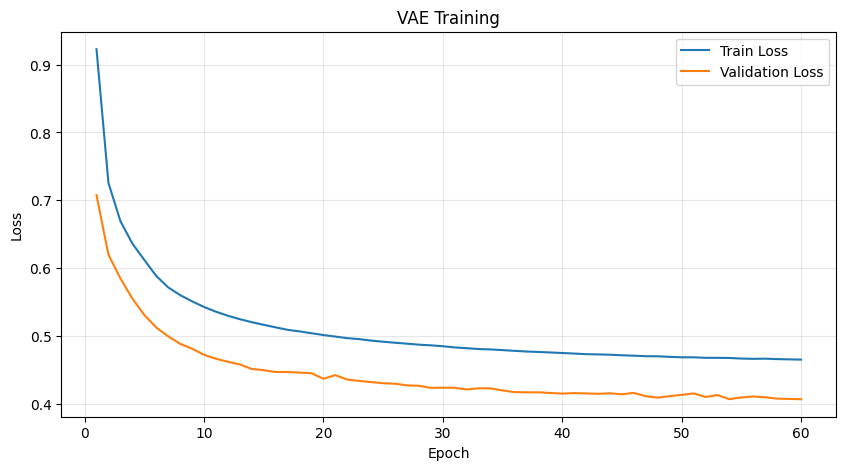

In [56]:
# ============================================================
# 40. TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt


plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)


plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "VAE Training"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

Ячейка 40 — Recon и KL

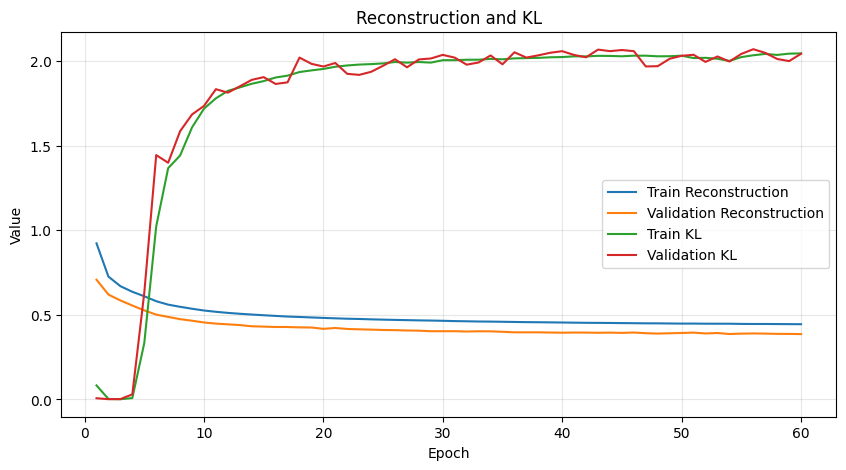

In [57]:
# ============================================================
# 41. RECONSTRUCTION + KL
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_recon"],
    label="Train Reconstruction"
)


plt.plot(
    history_df["epoch"],
    history_df["val_recon"],
    label="Validation Reconstruction"
)


plt.plot(
    history_df["epoch"],
    history_df["train_kl"],
    label="Train KL"
)


plt.plot(
    history_df["epoch"],
    history_df["val_kl"],
    label="Validation KL"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Value"
)

plt.title(
    "Reconstruction and KL"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

Ячейка 41 — статистика latent space

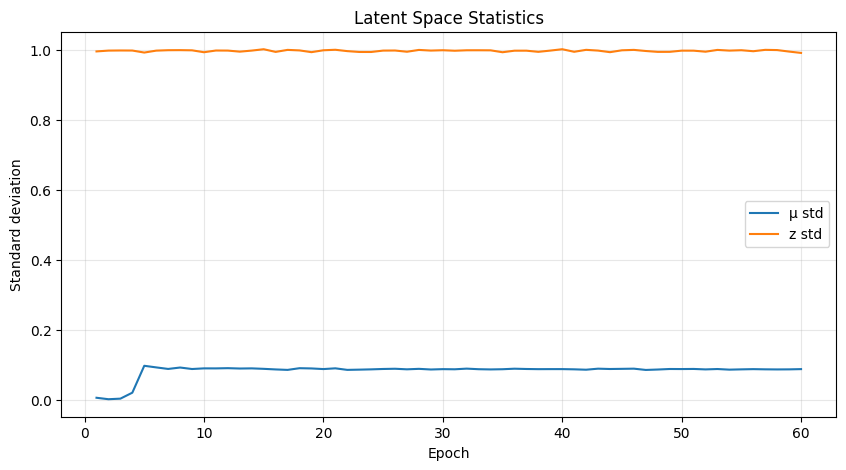

In [58]:
# ============================================================
# 42. LATENT SPACE STATISTICS
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["mu_std"],
    label="μ std"
)


plt.plot(
    history_df["epoch"],
    history_df["z_std"],
    label="z std"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Standard deviation"
)

plt.title(
    "Latent Space Statistics"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

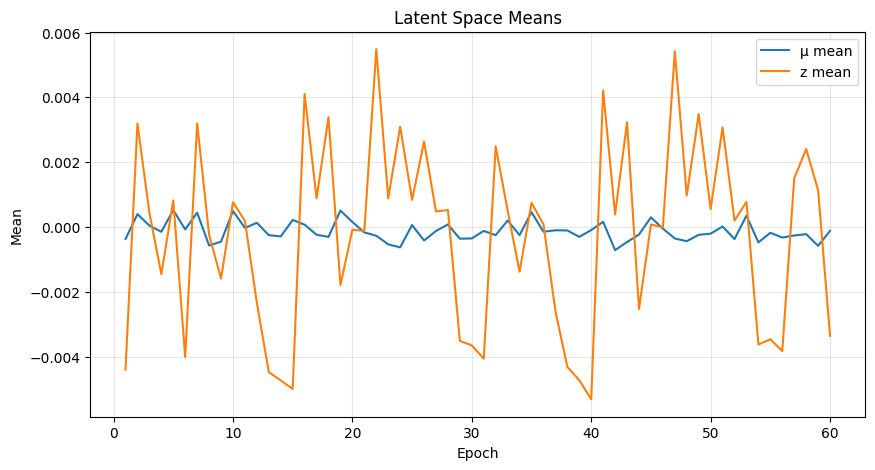

In [59]:
# ============================================================
# 43. LATENT SPACE MEANS
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["mu_mean"],
    label="μ mean"
)

plt.plot(
    history_df["epoch"],
    history_df["z_mean"],
    label="z mean"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Mean"
)

plt.title(
    "Latent Space Means"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

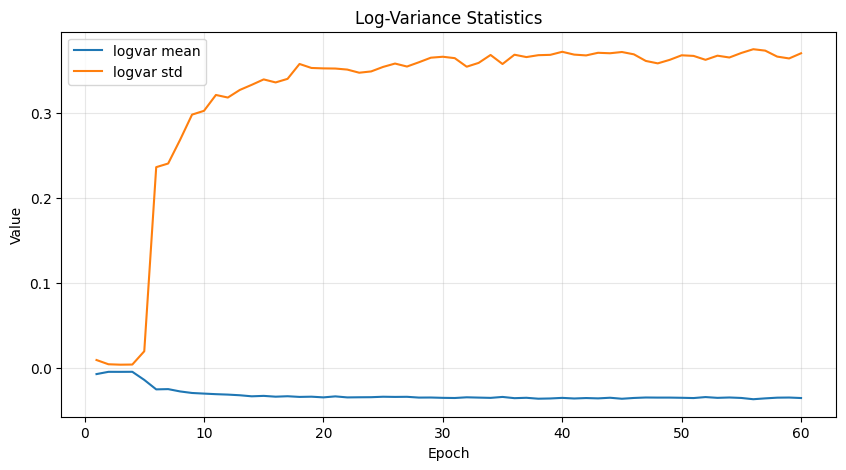

In [60]:
# ============================================================
# 44. LOGVAR STATISTICS
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["logvar_mean"],
    label="logvar mean"
)

plt.plot(
    history_df["epoch"],
    history_df["logvar_std"],
    label="logvar std"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Value"
)

plt.title(
    "Log-Variance Statistics"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

Latent μ shape: (3200, 128)


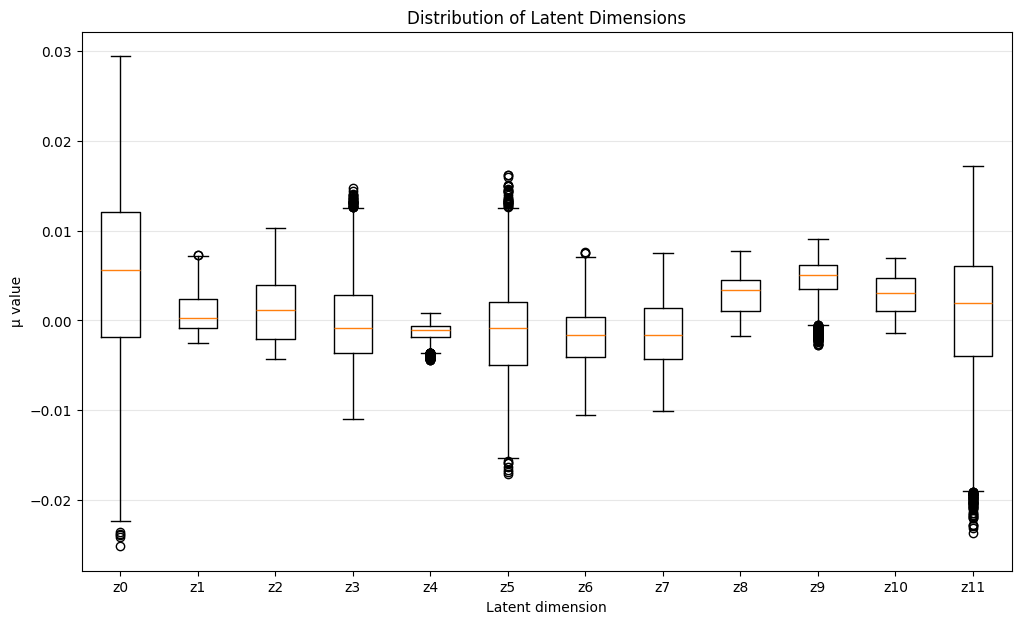

In [61]:
# ============================================================
# 45. LATENT DIMENSIONS DISTRIBUTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


@torch.no_grad()
def collect_latent_mu(
    model,
    dataloader,
    device,
    max_batches=100
):

    model.eval()

    all_mu = []

    for batch_idx, (
        batch,
        properties,
        fingerprint
    ) in enumerate(dataloader):

        if batch_idx >= max_batches:
            break

        batch = batch.to(
            device,
            non_blocking=True
        )

        properties = properties.to(
            device,
            non_blocking=True
        )

        fingerprint = fingerprint.to(
            device,
            non_blocking=True
        )

        _, mu, _, _ = model(
            batch,
            properties,
            fingerprint
        )

        all_mu.append(
            mu.cpu()
        )

    return torch.cat(
        all_mu,
        dim=0
    )


latent_mu = collect_latent_mu(
    model,
    val_loader,
    device,
    max_batches=100
)


latent_mu_np = (
    latent_mu.numpy()
)


print(
    "Latent μ shape:",
    latent_mu_np.shape
)


# ------------------------------------------------------------
# Показываем первые 12 latent dimensions
# ------------------------------------------------------------

n_dims = min(
    12,
    latent_mu_np.shape[1]
)


plt.figure(
    figsize=(12, 7)
)


plt.boxplot(
    [
        latent_mu_np[:, i]
        for i in range(n_dims)
    ],
    labels=[
        f"z{i}"
        for i in range(n_dims)
    ]
)


plt.xlabel(
    "Latent dimension"
)

plt.ylabel(
    "μ value"
)

plt.title(
    "Distribution of Latent Dimensions"
)

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.show()

Explained variance:
PC1: 99.98%
PC2: 0.01%
Total: 100.00%


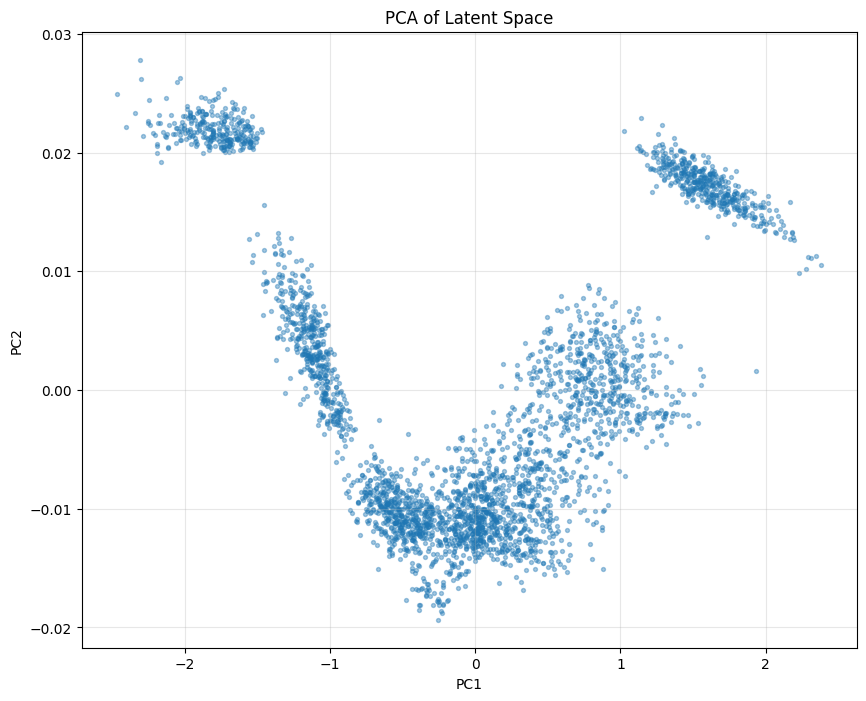

In [62]:
# ============================================================
# 46. PCA LATENT SPACE
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

pca = PCA(
    n_components=2
)


latent_pca = pca.fit_transform(
    latent_mu_np
)


print(
    "Explained variance:"
)

print(
    f"PC1: {pca.explained_variance_ratio_[0] * 100:.2f}%"
)

print(
    f"PC2: {pca.explained_variance_ratio_[1] * 100:.2f}%"
)

print(
    f"Total: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)

plt.scatter(
    latent_pca[:, 0],
    latent_pca[:, 1],
    s=8,
    alpha=0.4
)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.title(
    "PCA of Latent Space"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

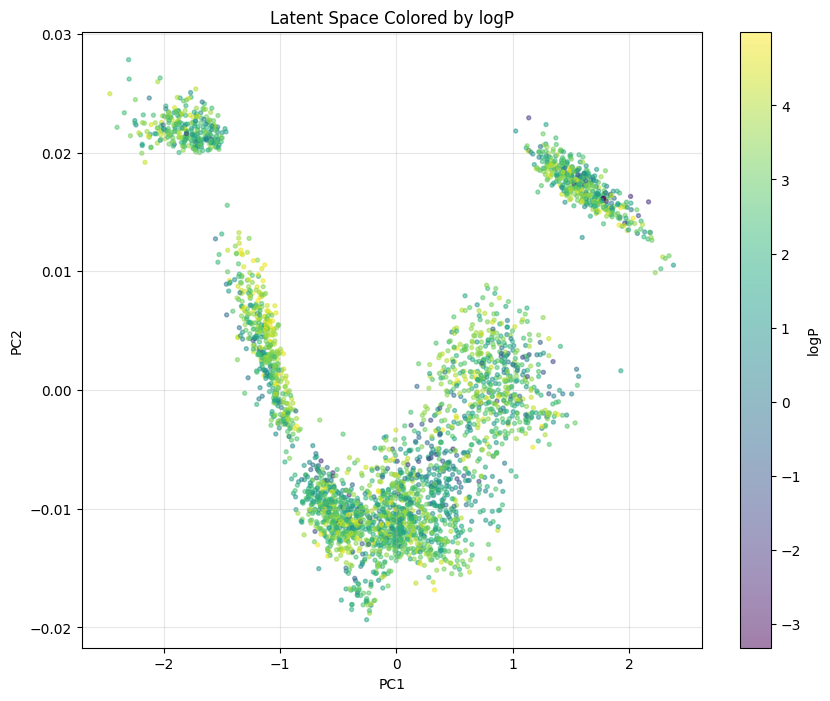

In [63]:
# ============================================================
# 47. PCA LATENT SPACE COLORED BY logP
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Number of molecules
# ------------------------------------------------------------

n_samples = len(
    latent_pca
)


# ------------------------------------------------------------
# logP из исходных properties
#
# features_val_scaled содержит стандартизированные значения.
# Возвращаем исходный масштаб через scaler.
# ------------------------------------------------------------

properties_original = (
    property_scaler.inverse_transform(
        features_val_scaled[:n_samples]
    )
)


logp_values = (
    properties_original[:, 0]
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)

scatter = plt.scatter(
    latent_pca[:, 0],
    latent_pca[:, 1],
    c=logp_values,
    s=8,
    alpha=0.5
)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.title(
    "Latent Space Colored by logP"
)

plt.colorbar(
    scatter,
    label="logP"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

PCA LATENT SPACE
Samples: 3200
Latent dimensions: 128

Explained variance:
PC1:   99.98%
PC2:   0.01%
Total: 100.00%

Property statistics:

logP: min=-3.326, max=4.997, mean=2.473, std=1.333
QED:  min=0.156, max=0.944, mean=0.741, std=0.133
SAS:  min=1.378, max=7.189, mean=3.051, std=0.816


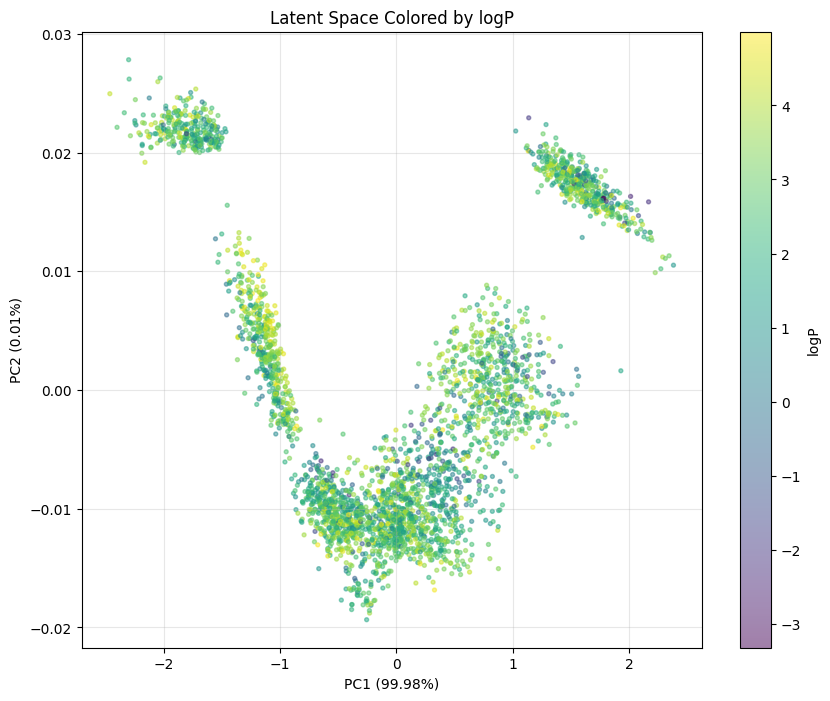

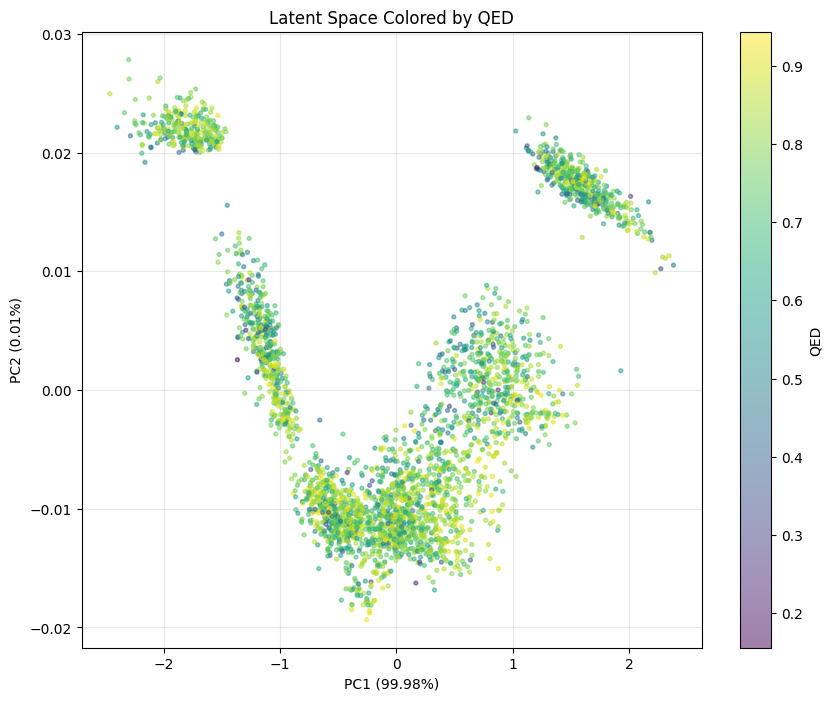

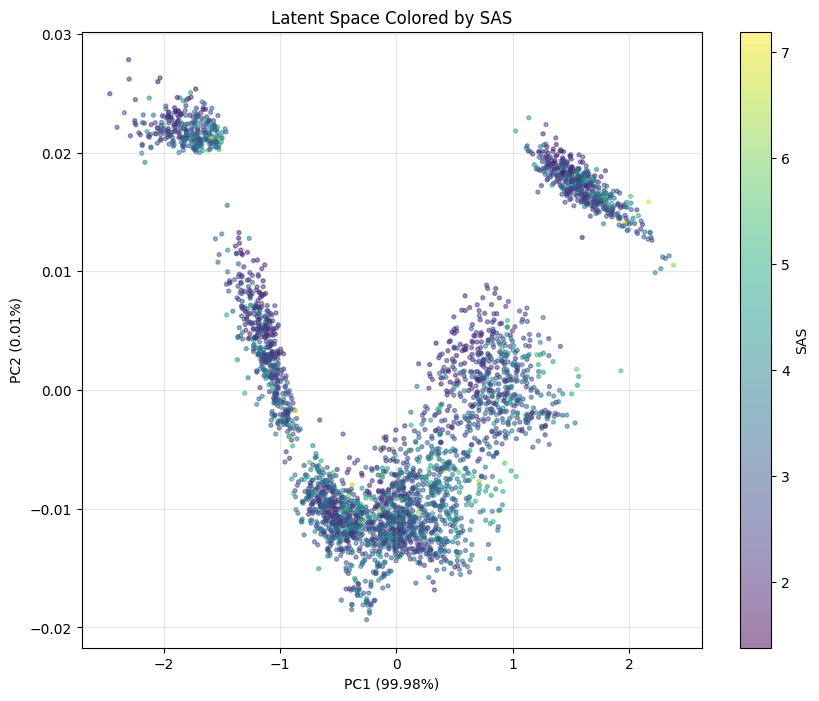


✓ PCA-графики для logP, QED и SAS построены


In [64]:
# ============================================================
# 48. PCA LATENT SPACE COLORED BY PROPERTIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# НАСТРОЙКИ
# ============================================================

# Названия свойств
PROPERTY_NAMES_PCA = [
    "logP",
    "QED",
    "SAS"
]

# Индексы свойств в FEATURE_NAMES
LOGP_IDX = 0
QED_IDX = 1
SAS_IDX = 2


# ============================================================
# ПРОВЕРКА LATENT SPACE
# ============================================================

if "latent_mu_np" not in globals():

    raise RuntimeError(
        "Переменная latent_mu_np не найдена.\n"
        "Сначала запустите ячейку №45."
    )


if "latent_pca" not in globals():

    raise RuntimeError(
        "Переменная latent_pca не найдена.\n"
        "Сначала запустите ячейку №46."
    )


# ============================================================
# КОЛИЧЕСТВО ОБРАЗЦОВ
# ============================================================

n_samples = len(
    latent_mu_np
)


print(
    "=" * 70
)

print(
    "PCA LATENT SPACE"
)

print(
    "=" * 70
)

print(
    "Samples:",
    n_samples
)

print(
    "Latent dimensions:",
    latent_mu_np.shape[1]
)

print()


# ============================================================
# PCA INFORMATION
# ============================================================

explained_pc1 = (
    pca.explained_variance_ratio_[0]
    * 100
)

explained_pc2 = (
    pca.explained_variance_ratio_[1]
    * 100
)

explained_total = (
    explained_pc1
    + explained_pc2
)


print(
    "Explained variance:"
)

print(
    f"PC1:   {explained_pc1:.2f}%"
)

print(
    f"PC2:   {explained_pc2:.2f}%"
)

print(
    f"Total: {explained_total:.2f}%"
)

print()


# ============================================================
# ВОЗВРАТ PROPERTIES В ИСХОДНЫЙ МАСШТАБ
# ============================================================

properties_original = (
    property_scaler.inverse_transform(
        features_val_scaled[:n_samples]
    )
)


# ============================================================
# ПРОВЕРКА РАЗМЕРОВ
# ============================================================

if len(latent_pca) != len(
    properties_original
):

    raise RuntimeError(
        "Количество latent vectors "
        "не совпадает с количеством properties."
    )


# ============================================================
# ИЗВЛЕКАЕМ СВОЙСТВА
# ============================================================

logp_values = (
    properties_original[:, LOGP_IDX]
)

qed_values = (
    properties_original[:, QED_IDX]
)

sas_values = (
    properties_original[:, SAS_IDX]
)


# ============================================================
# ПЕЧАТЬ СТАТИСТИК
# ============================================================

print(
    "Property statistics:"
)

print()

print(
    f"logP: "
    f"min={logp_values.min():.3f}, "
    f"max={logp_values.max():.3f}, "
    f"mean={logp_values.mean():.3f}, "
    f"std={logp_values.std():.3f}"
)

print(
    f"QED:  "
    f"min={qed_values.min():.3f}, "
    f"max={qed_values.max():.3f}, "
    f"mean={qed_values.mean():.3f}, "
    f"std={qed_values.std():.3f}"
)

print(
    f"SAS:  "
    f"min={sas_values.min():.3f}, "
    f"max={sas_values.max():.3f}, "
    f"mean={sas_values.mean():.3f}, "
    f"std={sas_values.std():.3f}"
)


# ============================================================
# 1. PCA + logP
# ============================================================

plt.figure(
    figsize=(10, 8)
)

scatter = plt.scatter(
    latent_pca[:, 0],
    latent_pca[:, 1],
    c=logp_values,
    s=8,
    alpha=0.5
)

plt.xlabel(
    f"PC1 ({explained_pc1:.2f}%)"
)

plt.ylabel(
    f"PC2 ({explained_pc2:.2f}%)"
)

plt.title(
    "Latent Space Colored by logP"
)

plt.colorbar(
    scatter,
    label="logP"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 2. PCA + QED
# ============================================================

plt.figure(
    figsize=(10, 8)
)

scatter = plt.scatter(
    latent_pca[:, 0],
    latent_pca[:, 1],
    c=qed_values,
    s=8,
    alpha=0.5
)

plt.xlabel(
    f"PC1 ({explained_pc1:.2f}%)"
)

plt.ylabel(
    f"PC2 ({explained_pc2:.2f}%)"
)

plt.title(
    "Latent Space Colored by QED"
)

plt.colorbar(
    scatter,
    label="QED"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 3. PCA + SAS
# ============================================================

plt.figure(
    figsize=(10, 8)
)

scatter = plt.scatter(
    latent_pca[:, 0],
    latent_pca[:, 1],
    c=sas_values,
    s=8,
    alpha=0.5
)

plt.xlabel(
    f"PC1 ({explained_pc1:.2f}%)"
)

plt.ylabel(
    f"PC2 ({explained_pc2:.2f}%)"
)

plt.title(
    "Latent Space Colored by SAS"
)

plt.colorbar(
    scatter,
    label="SAS"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# ГОТОВО
# ============================================================

print()

print(
    "✓ PCA-графики для logP, QED и SAS построены"
)

=============================================================================================================================
=============================================================================================================================
=============================================================================================================================

In [65]:
# ============================================================
# ГЕНЕРАЦИЯ 5000 МОЛЕКУЛ ПО ЦЕЛЕВЫМ ДЕСКРИПТОРАМ
# TARGET-DESCRIPTOR-CONDITIONED MOLECULE GENERATION
# ============================================================


import os
import random
import numpy as np
import torch

from rdkit import Chem
from rdkit import RDLogger

import selfies as sf


# ============================================================
# RDKit
# ============================================================

RDLogger.DisableLog("rdApp.*")


# ============================================================
# НАСТРОЙКИ
# ============================================================

CHECKPOINT_DIR = "checkpoints_vae"

CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "vae_best_transformer_conditional_fingerprint.pt"
)


N_SAMPLES = 5000

SEED = 42

MAX_LEN = 66

LATENT_DIM = 128

BATCH_SIZE_GEN = 256

TEMPERATURE = 1.0


# ============================================================
# СПЕЦИАЛЬНЫЕ ТОКЕНЫ
# ============================================================

PAD_IDX = 0
START_IDX = 1
END_IDX = 2
UNK_IDX = 3


# ============================================================
# ДЕСКРИПТОРЫ
# ============================================================

PROPERTY_NAMES = [

    "logP",
    "QED",
    "SAS",
    "MW",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "Rings",
    "AromaticRings",
    "FractionCSP3"

]


PROPERTY_DIM = len(
    PROPERTY_NAMES
)


# ============================================================
# ЦЕЛЕВЫЕ ДЕСКРИПТОРЫ
# ============================================================
#
# Можно задавать только те свойства,
# которыми необходимо управлять.
#
# Остальные свойства автоматически получают
# средние значения TRAIN.
#
# ============================================================
#
# Пример:
#
# TARGET_PROPERTIES = {
#     "logP": 2.5
# }
#
#
# Несколько свойств:
#
# TARGET_PROPERTIES = {
#     "logP": 2.5,
#     "MW": 350.0,
#     "TPSA": 80.0
# }
#
#
# Все свойства:
#
# TARGET_PROPERTIES = {
#     "logP": 2.5,
#     "QED": 0.75,
#     "SAS": 3.0,
#     "MW": 330.0,
#     "TPSA": 64.0,
#     "HBD": 1.0,
#     "HBA": 4.0,
#     "RotatableBonds": 4.0,
#     "Rings": 3.0,
#     "AromaticRings": 2.0,
#     "FractionCSP3": 0.42
# }
#
# ============================================================

TARGET_PROPERTIES = {

    "logP": 2.5

}


# ============================================================
# ПРОВЕРКА TARGET DESCRIPTORS
# ============================================================

unknown_properties = [

    name
    for name in TARGET_PROPERTIES
    if name not in PROPERTY_NAMES

]


if len(unknown_properties) > 0:

    raise ValueError(

        "Обнаружены неизвестные дескрипторы:\n"
        + "\n".join(unknown_properties)
        + "\n\n"
        "Допустимые дескрипторы:\n"
        + "\n".join(PROPERTY_NAMES)

    )


# ============================================================
# ПРОВЕРКА ОСНОВНЫХ ОБЪЕКТОВ
# ============================================================

required_variables = [

    "df_vae",
    "train_indices",
    "features",
    "idx_to_token",
    "model"

]


missing_variables = [

    name
    for name in required_variables
    if name not in globals()

]


if len(missing_variables) > 0:

    raise RuntimeError(

        "В ноутбуке отсутствуют необходимые переменные:\n\n"
        + "\n".join(missing_variables)
        + "\n\n"
        "Сначала выполните соответствующие ячейки "
        "подготовки данных и модели."

    )


# ============================================================
# ПРОВЕРКА FEATURES
# ============================================================
#
# ВАЖНО:
#
# При обучении использовался массив:
#
#     features
#
# размерности:
#
#     [N, 11]
#
# Поэтому TRAIN statistics необходимо получать
# именно из features, а НЕ из df_vae.
#
# ============================================================

if not isinstance(
    features,
    np.ndarray
):

    features = np.asarray(
        features,
        dtype=np.float32
    )


if features.ndim != 2:

    raise ValueError(

        f"features должен быть двумерным массивом. "
        f"Получена размерность: {features.shape}"

    )


if features.shape[1] != PROPERTY_DIM:

    raise ValueError(

        f"Несоответствие числа дескрипторов:\n\n"
        f"PROPERTY_DIM = {PROPERTY_DIM}\n"
        f"features.shape[1] = {features.shape[1]}"

    )


if len(features) != len(df_vae):

    raise ValueError(

        f"Несоответствие количества молекул:\n\n"
        f"len(df_vae) = {len(df_vae)}\n"
        f"len(features) = {len(features)}"

    )


if not np.isfinite(features).all():

    raise ValueError(
        "В features обнаружены NaN или Inf."
    )


# ============================================================
# ПРОВЕРКА TRAIN INDICES
# ============================================================

train_indices = np.asarray(
    train_indices
)


if len(train_indices) == 0:

    raise ValueError(
        "train_indices пуст."
    )


if train_indices.min() < 0:

    raise ValueError(
        "train_indices содержит отрицательные индексы."
    )


if train_indices.max() >= len(features):

    raise ValueError(

        "train_indices содержит индекс "
        "за пределами features."

    )


# ============================================================
# TRAIN FEATURES
# ============================================================

train_features = features[
    train_indices
]


# ============================================================
# TRAIN PROPERTY MEANS
# ============================================================
#
# Используем ТОЧНО тот же набор из 11 дескрипторов,
# который использовался при обучении.
#
# ============================================================

TRAIN_PROPERTY_MEANS = {

    name: float(
        np.mean(
            train_features[:, i]
        )
    )

    for i, name in enumerate(
        PROPERTY_NAMES
    )

}


# ============================================================
# ПРОВЕРКА TRAIN PROPERTY MEANS
# ============================================================

if not all(

    np.isfinite(value)
    for value in TRAIN_PROPERTY_MEANS.values()

):

    raise ValueError(
        "В TRAIN_PROPERTY_MEANS обнаружены NaN или Inf."
    )


# ============================================================
# TRAIN PROPERTY STATISTICS
# ============================================================

print()
print("=" * 70)
print("TRAIN PROPERTY MEANS")
print("=" * 70)

print()

for name in PROPERTY_NAMES:

    print(

        f"{name:20s}: "
        f"{TRAIN_PROPERTY_MEANS[name]:10.4f}"

    )


# ============================================================
# ФОРМИРОВАНИЕ ПОЛНОГО TARGET ВЕКТОРА
# ============================================================
#
# Пользователь задаёт только необходимые свойства.
#
# Все остальные:
#
#     → среднее значение TRAIN
#
# ============================================================

target_properties_full = {}


for name in PROPERTY_NAMES:

    if name in TARGET_PROPERTIES:

        target_properties_full[name] = float(
            TARGET_PROPERTIES[name]
        )

    else:

        target_properties_full[name] = (
            TRAIN_PROPERTY_MEANS[name]
        )


# ============================================================
# TARGET DESCRIPTORS
# ============================================================

print()
print("=" * 70)
print("TARGET DESCRIPTORS")
print("=" * 70)

print()

print(
    "USER       = задано пользователем"
)

print(
    "TRAIN MEAN = среднее значение TRAIN"
)

print()


for name in PROPERTY_NAMES:

    if name in TARGET_PROPERTIES:

        source = "USER"

    else:

        source = "TRAIN MEAN"


    print(

        f"{name:20s}: "
        f"{target_properties_full[name]:10.4f} "
        f"[{source}]"

    )


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"

)


# ============================================================
# SEED
# ============================================================

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


# ============================================================
# GENERATION SETTINGS
# ============================================================

print()
print("=" * 70)
print("GENERATION SETTINGS")
print("=" * 70)

print(
    f"Device:       {DEVICE}"
)

print(
    f"N samples:    {N_SAMPLES}"
)

print(
    f"Latent dim:   {LATENT_DIM}"
)

print(
    f"Max length:   {MAX_LEN}"
)

print(
    f"Temperature:  {TEMPERATURE}"
)

print(
    f"Batch size:   {BATCH_SIZE_GEN}"
)


# ============================================================
# ПРОВЕРКА CHECKPOINT
# ============================================================

if not os.path.exists(
    CHECKPOINT_PATH
):

    raise FileNotFoundError(

        f"\nConditional checkpoint не найден:\n"
        f"{CHECKPOINT_PATH}\n\n"

        "Сначала необходимо обучить "
        "conditional VAE модель."

    )


print()
print(
    f"Checkpoint найден:\n{CHECKPOINT_PATH}"
)


# ============================================================
# ЗАГРУЗКА CHECKPOINT
# ============================================================

checkpoint = torch.load(

    CHECKPOINT_PATH,

    map_location=DEVICE,

    weights_only=False

)


print()
print(
    "Checkpoint загружен."
)


# ============================================================
# CHECKPOINT INFORMATION
# ============================================================

if isinstance(
    checkpoint,
    dict
):

    print()
    print(
        "Ключи checkpoint:"
    )

    print(
        list(
            checkpoint.keys()
        )
    )


# ============================================================
# PROPERTY SCALER
# ============================================================

if (

    isinstance(
        checkpoint,
        dict
    )

    and

    "property_scaler"
    in checkpoint

):

    property_scaler = (

        checkpoint[
            "property_scaler"
        ]

    )


    print()
    print(
        "Property scaler загружен "
        "из checkpoint."
    )


else:

    raise KeyError(

        "\nВ checkpoint отсутствует "
        "'property_scaler'.\n\n"

        "Для conditional generation необходимо "
        "использовать scaler, применявшийся "
        "при обучении."

    )


# ============================================================
# ПРОВЕРКА SCALER
# ============================================================

if not hasattr(
    property_scaler,
    "n_features_in_"
):

    raise ValueError(
        "Некорректный property_scaler."
    )


if property_scaler.n_features_in_ != PROPERTY_DIM:

    raise ValueError(

        f"\nScaler ожидает "
        f"{property_scaler.n_features_in_} "
        f"признаков,\n"
        f"но PROPERTY_DIM = {PROPERTY_DIM}."

    )


# ============================================================
# ЗАГРУЗКА ВЕСОВ МОДЕЛИ
# ============================================================

if (

    isinstance(
        checkpoint,
        dict
    )

    and

    "model_state_dict"
    in checkpoint

):

    model.load_state_dict(

        checkpoint[
            "model_state_dict"
        ]

    )


    print()
    print(
        "Загружен model_state_dict."
    )


elif (

    isinstance(
        checkpoint,
        dict
    )

    and

    "state_dict"
    in checkpoint

):

    model.load_state_dict(

        checkpoint[
            "state_dict"
        ]

    )


    print()
    print(
        "Загружен state_dict."
    )


else:

    model.load_state_dict(
        checkpoint
    )


    print()
    print(
        "Checkpoint загружен "
        "непосредственно как state_dict."
    )


# ============================================================
# MODEL
# ============================================================

model = model.to(
    DEVICE
)

model.eval()


print()
print(
    "Модель переведена "
    "в evaluation mode."
)


# ============================================================
# ПРОВЕРКА MODEL DIMENSIONS
# ============================================================

model_property_dim = (

    model
    .decoder
    .property_projection[0]
    .in_features

)


model_latent_dim = (

    model
    .decoder
    .latent_projection
    .in_features

)


if model_property_dim != PROPERTY_DIM:

    raise ValueError(

        f"\nНесоответствие property dimension:\n"
        f"PROPERTY_DIM = {PROPERTY_DIM}\n"
        f"Model expects = {model_property_dim}"

    )


if model_latent_dim != LATENT_DIM:

    raise ValueError(

        f"\nНесоответствие latent dimension:\n"
        f"LATENT_DIM = {LATENT_DIM}\n"
        f"Model expects = {model_latent_dim}"

    )


# ============================================================
# VOCABULARY
# ============================================================

VOCAB_SIZE = (

    model
    .decoder
    .embedding
    .num_embeddings

)


print()
print(
    f"Vocabulary size: {VOCAB_SIZE}"
)


if VOCAB_SIZE <= END_IDX:

    raise ValueError(
        "Размер vocabulary слишком мал."
    )


# ============================================================
# TARGET → NUMPY
# ============================================================

target_property_array = np.array(

    [
        target_properties_full[name]
        for name in PROPERTY_NAMES
    ],

    dtype=np.float32

)


if target_property_array.shape != (
    PROPERTY_DIM,
):

    raise ValueError(

        f"Неверная размерность target vector: "
        f"{target_property_array.shape}"

    )


# ============================================================
# TARGET → SCALED
# ============================================================
#
# Используем ТОТ ЖЕ scaler,
# который был сохранён при обучении.
#
# ============================================================

target_properties_scaled = (

    property_scaler.transform(

        target_property_array.reshape(
            1,
            -1
        )

    )

)


target_properties_scaled = (

    target_properties_scaled
    .astype(np.float32)

)


# ============================================================
# SCALED TARGET
# ============================================================

print()
print("=" * 70)
print("SCALED TARGET DESCRIPTORS")
print("=" * 70)

print()


for name, value in zip(

    PROPERTY_NAMES,

    target_properties_scaled[0]

):

    print(

        f"{name:20s}: "
        f"{value:10.6f}"

    )


# ============================================================
# TARGET → TORCH
# ============================================================

target_properties_tensor = torch.tensor(

    target_properties_scaled,

    dtype=torch.float32,

    device=DEVICE

)


# ============================================================
# TOKEN IDS → SELFIES
# ============================================================

def tokens_to_selfies(

    token_ids,
    idx_to_token

):

    """
    Преобразование последовательности
    token IDs в SELFIES.
    """

    tokens = []


    for idx in token_ids:

        idx = int(idx)


        # ----------------------------------------------------
        # END
        # ----------------------------------------------------

        if idx == END_IDX:

            break


        # ----------------------------------------------------
        # PAD / START
        # ----------------------------------------------------

        if idx in (

            PAD_IDX,
            START_IDX

        ):

            continue


        # ----------------------------------------------------
        # TOKEN
        # ----------------------------------------------------

        token = idx_to_token.get(

            idx,
            "<UNK>"

        )


        if token == "<UNK>":

            return None


        tokens.append(
            token
        )


    # --------------------------------------------------------
    # Пустая последовательность
    # --------------------------------------------------------

    if len(tokens) == 0:

        return None


    return "".join(
        tokens
    )


# ============================================================
# АВТОРЕГРЕССИВНАЯ ГЕНЕРАЦИЯ
# ============================================================

@torch.no_grad()
def generate_batch(

    model,
    z,
    target_properties,
    max_len=MAX_LEN,
    temperature=TEMPERATURE

):

    """
    Генерация SELFIES для batch латентных
    векторов z при заданных target descriptors.
    """

    batch_size = z.size(0)


    # ========================================================
    # TEMPERATURE
    # ========================================================

    if temperature <= 0:

        raise ValueError(
            "Temperature должна быть > 0."
        )


    # ========================================================
    # START TOKEN
    # ========================================================

    generated = torch.full(

        (
            batch_size,
            1
        ),

        START_IDX,

        dtype=torch.long,

        device=z.device

    )


    # ========================================================
    # FINISHED
    # ========================================================

    finished = torch.zeros(

        batch_size,

        dtype=torch.bool,

        device=z.device

    )


    # ========================================================
    # AUTOREGRESSIVE GENERATION
    # ========================================================

    for step in range(

        max_len - 1

    ):

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        logits = model.decoder(

            generated,

            z,

            target_properties

        )


        # ----------------------------------------------------
        # Последний timestep
        # ----------------------------------------------------

        next_token_logits = (

            logits[:, -1, :]

        )


        # ----------------------------------------------------
        # Temperature
        # ----------------------------------------------------

        probs = torch.softmax(

            next_token_logits
            / temperature,

            dim=-1

        )


        # ----------------------------------------------------
        # Sampling
        # ----------------------------------------------------

        next_token = torch.multinomial(

            probs,

            num_samples=1

        )


        # ----------------------------------------------------
        # PAD после END
        # ----------------------------------------------------

        next_token = torch.where(

            finished.unsqueeze(1),

            torch.full_like(

                next_token,

                PAD_IDX

            ),

            next_token

        )


        # ----------------------------------------------------
        # Добавление токена
        # ----------------------------------------------------

        generated = torch.cat(

            [

                generated,
                next_token

            ],

            dim=1

        )


        # ----------------------------------------------------
        # END
        # ----------------------------------------------------

        finished |= (

            next_token.squeeze(1)
            == END_IDX

        )


        # ----------------------------------------------------
        # Все последовательности завершены
        # ----------------------------------------------------

        if finished.all():

            break


    return generated


# ============================================================
# ГЕНЕРАЦИЯ
# ============================================================

all_token_sequences = []


print()
print("=" * 70)
print("НАЧАЛО ГЕНЕРАЦИИ")
print("=" * 70)


with torch.no_grad():

    for start in range(

        0,

        N_SAMPLES,

        BATCH_SIZE_GEN

    ):

        current_batch = min(

            BATCH_SIZE_GEN,

            N_SAMPLES - start

        )


        # ----------------------------------------------------
        # z ~ N(0, I)
        # ----------------------------------------------------

        z = torch.randn(

            current_batch,

            LATENT_DIM,

            device=DEVICE

        )


        # ----------------------------------------------------
        # TARGET PROPERTIES
        # ----------------------------------------------------

        batch_target_properties = (

            target_properties_tensor.expand(

                current_batch,
                -1

            )

        )


        # ----------------------------------------------------
        # GENERATION
        # ----------------------------------------------------

        generated_tokens = generate_batch(

            model=model,

            z=z,

            target_properties=(
                batch_target_properties
            )

        )


        all_token_sequences.extend(

            generated_tokens
            .cpu()
            .tolist()

        )


        done = (

            start
            + current_batch

        )


        if (

            done % 1024 < BATCH_SIZE_GEN

            or

            done == N_SAMPLES

        ):

            print(

                f"Generated: "
                f"{done:5d} / "
                f"{N_SAMPLES}"

            )


print()
print("-" * 70)
print(
    "Генерация завершена."
)


# ============================================================
# TOKEN SEQUENCES → SELFIES
# ============================================================

generated_selfies = []


for token_ids in all_token_sequences:

    selfies_string = tokens_to_selfies(

        token_ids,

        idx_to_token

    )


    generated_selfies.append(
        selfies_string
    )


# ============================================================
# SELFIES → SMILES
# ============================================================

generated_smiles = []

valid_smiles = []

invalid_selfies = 0

selfies_decode_errors = 0


for selfies_string in generated_selfies:

    # --------------------------------------------------------
    # Некорректная token sequence
    # --------------------------------------------------------

    if selfies_string is None:

        generated_smiles.append(
            None
        )

        invalid_selfies += 1

        continue


    # --------------------------------------------------------
    # SELFIES decoder
    # --------------------------------------------------------

    try:

        smiles = sf.decoder(
            selfies_string
        )

    except Exception:

        generated_smiles.append(
            None
        )

        selfies_decode_errors += 1

        continue


    generated_smiles.append(
        smiles
    )


    # --------------------------------------------------------
    # RDKit validation
    # --------------------------------------------------------

    mol = Chem.MolFromSmiles(
        smiles
    )


    if mol is not None:

        valid_smiles.append(
            smiles
        )


# ============================================================
# CANONICAL SMILES
# ============================================================

canonical_smiles = []


for smiles in valid_smiles:

    mol = Chem.MolFromSmiles(
        smiles
    )


    if mol is None:

        continue


    canonical = Chem.MolToSmiles(

        mol,

        canonical=True

    )


    canonical_smiles.append(
        canonical
    )


# ============================================================
# UNIQUE MOLECULES
# ============================================================

unique_smiles = set(
    canonical_smiles
)


# ============================================================
# STATISTICS
# ============================================================

n_generated = len(
    generated_selfies
)

n_valid = len(
    valid_smiles
)

n_unique = len(
    unique_smiles
)


validity = (

    100.0
    * n_valid
    / n_generated

    if n_generated > 0

    else 0.0

)


uniqueness = (

    100.0
    * n_unique
    / n_valid

    if n_valid > 0

    else 0.0

)


# ============================================================
# RESULTS
# ============================================================

print()
print("=" * 70)
print("РЕЗУЛЬТАТЫ CONDITIONAL GENERATION")
print("=" * 70)

print()

print(
    f"Всего сгенерировано:       "
    f"{n_generated}"
)

print(
    f"SELFIES без токенов:       "
    f"{invalid_selfies}"
)

print(
    f"SELFIES decode errors:     "
    f"{selfies_decode_errors}"
)

print(
    f"Валидных SMILES:           "
    f"{n_valid}"
)

print(
    f"Уникальных молекул:        "
    f"{n_unique}"
)

print()

print(
    f"Validity:                  "
    f"{validity:.2f}%"
)

print(
    f"Uniqueness:                "
    f"{uniqueness:.2f}%"
)


# ============================================================
# ПРИМЕРЫ МОЛЕКУЛ
# ============================================================

print()
print("=" * 70)
print("ПРИМЕРЫ СГЕНЕРИРОВАННЫХ МОЛЕКУЛ")
print("=" * 70)

print()


for i, smiles in enumerate(

    canonical_smiles[:20],

    1

):

    print(
        f"{i:2d}. {smiles}"
    )


# ============================================================
# TARGET DESCRIPTORS
# ============================================================

print()
print("=" * 70)
print("TARGET DESCRIPTORS ДЛЯ ЭТОЙ ГЕНЕРАЦИИ")
print("=" * 70)

print()


for name in PROPERTY_NAMES:

    if name in TARGET_PROPERTIES:

        source = "USER"

    else:

        source = "TRAIN MEAN"


    print(

        f"{name:20s}: "
        f"{target_properties_full[name]:10.4f} "
        f"[{source}]"

    )


# ============================================================
# ГЕНЕРАЦИЯ ЗАВЕРШЕНА
# ============================================================

print()
print("=" * 70)
print("ГЕНЕРАЦИЯ ЗАВЕРШЕНА")
print("=" * 70)


TRAIN PROPERTY MEANS

logP                :     2.3970
QED                 :     0.7351
SAS                 :     3.0621
MW                  :   329.5331
TPSA                :    63.9482
HBD                 :     1.1556
HBA                 :     3.9022
RotatableBonds      :     4.5620
Rings               :     2.7214
AromaticRings       :     1.8192
FractionCSP3        :     0.4179

TARGET DESCRIPTORS

USER       = задано пользователем
TRAIN MEAN = среднее значение TRAIN

logP                :     2.5000 [USER]
QED                 :     0.7351 [TRAIN MEAN]
SAS                 :     3.0621 [TRAIN MEAN]
MW                  :   329.5331 [TRAIN MEAN]
TPSA                :    63.9482 [TRAIN MEAN]
HBD                 :     1.1556 [TRAIN MEAN]
HBA                 :     3.9022 [TRAIN MEAN]
RotatableBonds      :     4.5620 [TRAIN MEAN]
Rings               :     2.7214 [TRAIN MEAN]
AromaticRings       :     1.8192 [TRAIN MEAN]
FractionCSP3        :     0.4179 [TRAIN MEAN]

GENERATION SETTINGS
D

            logP target
                 ↓
          Conditional VAE
                 ↓
          1000 molecules
                 ↓
       насколько изменился logP?

In [67]:
# ============================================================
# IMPROVED CONDITIONAL GENERATION EXPERIMENT
# SELFIES + MOLECULAR PROPERTIES + MORGAN FINGERPRINT
# ============================================================

import os
import sys
import random
import warnings

import numpy as np
import pandas as pd

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import (
    DataStructs,
    Descriptors,
    Crippen,
    QED,
    Lipinski,
    rdMolDescriptors,
    AllChem,
)

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

import selfies as sf


# ============================================================
# 0. GLOBAL SETTINGS
# ============================================================

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

SEED = 42
N_SAMPLES = 1000

TEMPERATURE = 1.0

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CHECKPOINT_PATH = (
    r"checkpoints_vae\vae_epoch_045_transformer_conditional_fingerprint.pt"
)

RESULTS_DIR = "conditional_generation_results"

os.makedirs(RESULTS_DIR, exist_ok=True)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 80)
print("IMPROVED CONDITIONAL GENERATION EXPERIMENT")
print("=" * 80)

print("Device:", DEVICE)
print("Seed:", SEED)
print("Samples per experiment:", N_SAMPLES)
print("Temperature:", TEMPERATURE)
print("Checkpoint:", CHECKPOINT_PATH)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. REQUIRED GLOBAL VARIABLES
# ============================================================

required_globals = [
    "model",
    "features",
    "train_indices",
    "idx_to_token",
    "property_scaler",
    "MAX_LEN",
]

missing_globals = [
    name for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise RuntimeError(
        "Не найдены необходимые переменные:\n"
        + "\n".join(f"  - {x}" for x in missing_globals)
    )

print()
print("Required variables: OK")


# ============================================================
# 3. LOAD CHECKPOINT
# ============================================================

print()
print("=" * 80)
print("LOADING CHECKPOINT")
print("=" * 80)

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Checkpoint not found:\n{CHECKPOINT_PATH}"
    )

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

if "model_state_dict" in checkpoint:
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
else:
    model.load_state_dict(checkpoint)

model = model.to(DEVICE)
model.eval()

print("Checkpoint loaded successfully")

if isinstance(checkpoint, dict):
    if "epoch" in checkpoint:
        print("Epoch:", checkpoint["epoch"])

    if "val_loss" in checkpoint:
        print("Val loss:", checkpoint["val_loss"])


# ============================================================
# 4. RESTORE PROPERTY SCALER
# ============================================================

if (
    isinstance(checkpoint, dict)
    and "property_scaler" in checkpoint
):
    try:
        property_scaler = checkpoint["property_scaler"]
        print("Property scaler restored from checkpoint")
    except Exception as e:
        print("Could not restore property scaler:", e)


# ============================================================
# 5. PROPERTY DEFINITIONS
# ============================================================

PROPERTY_NAMES = [
    "logP",
    "QED",
    "SAS",
    "MW",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "Rings",
    "AromaticRings",
    "FractionCSP3",
]

PROPERTY_INDEX = {
    name: i
    for i, name in enumerate(PROPERTY_NAMES)
}

PROPERTY_DIM = len(PROPERTY_NAMES)

print()
print("=" * 80)
print("PROPERTIES")
print("=" * 80)

for i, name in enumerate(PROPERTY_NAMES):
    print(f"{i:2d}: {name}")


# ============================================================
# 6. FEATURES / TRAIN STATISTICS
# ============================================================

features_np = np.asarray(features)

train_indices_np = np.asarray(
    train_indices,
    dtype=np.int64
)

print()
print("=" * 80)
print("DATASET / FEATURES")
print("=" * 80)

print("Features shape:", features_np.shape)
print("Train indices:", train_indices_np.shape)

if features_np.ndim != 2:
    raise RuntimeError(
        f"features должен быть 2D, получено: {features_np.shape}"
    )

if features_np.shape[1] != PROPERTY_DIM:
    raise RuntimeError(
        f"Ожидалось {PROPERTY_DIM} properties, "
        f"получено {features_np.shape[1]}"
    )

if train_indices_np.min() < 0:
    raise RuntimeError("train_indices содержит отрицательные значения")

if train_indices_np.max() >= len(features_np):
    raise RuntimeError(
        "train_indices выходит за пределы features:\n"
        f"max index = {train_indices_np.max()}\n"
        f"features rows = {len(features_np)}"
    )

train_features = features_np[train_indices_np]

TRAIN_MEANS = np.nanmean(
    train_features,
    axis=0
)

TRAIN_STDS = np.nanstd(
    train_features,
    axis=0
)

print()
print("TRAIN PROPERTY STATISTICS")
print("-" * 80)

for i, name in enumerate(PROPERTY_NAMES):

    print(
        f"{name:18s} "
        f"mean = {TRAIN_MEANS[i]:10.4f}   "
        f"std = {TRAIN_STDS[i]:10.4f}"
    )


# ============================================================
# 7. DESCRIPTOR CALCULATOR
# ============================================================

try:
    from rdkit.RDConfig import RDContribDir

    sa_score_path = os.path.join(
        RDContribDir,
        "SA_Score"
    )

    if sa_score_path not in sys.path:
        sys.path.append(sa_score_path)

    import sascorer

    SAS_AVAILABLE = True

except Exception as e:

    SAS_AVAILABLE = False
    sascorer = None

    print()
    print("WARNING: SAS_Score unavailable:", e)


def calculate_descriptors(mol):

    if mol is None:
        return None

    try:

        result = {}

        result["logP"] = Crippen.MolLogP(mol)

        result["QED"] = QED.qed(mol)

        if SAS_AVAILABLE:
            result["SAS"] = sascorer.calculateScore(mol)
        else:
            result["SAS"] = np.nan

        result["MW"] = Descriptors.MolWt(mol)

        result["TPSA"] = rdMolDescriptors.CalcTPSA(mol)

        result["HBD"] = Lipinski.NumHDonors(mol)

        result["HBA"] = Lipinski.NumHAcceptors(mol)

        result["RotatableBonds"] = (
            Lipinski.NumRotatableBonds(mol)
        )

        result["Rings"] = rdMolDescriptors.CalcNumRings(mol)

        result["AromaticRings"] = (
            rdMolDescriptors.CalcNumAromaticRings(mol)
        )

        result["FractionCSP3"] = (
            rdMolDescriptors.CalcFractionCSP3(mol)
        )

        return result

    except Exception:
        return None


# ============================================================
# 8. CANONICALIZATION
# ============================================================

def canonicalize(smiles):

    if smiles is None:
        return None

    try:

        mol = Chem.MolFromSmiles(
            str(smiles)
        )

        if mol is None:
            return None

        return Chem.MolToSmiles(
            mol,
            canonical=True
        )

    except Exception:
        return None


# ============================================================
# 9. MORGAN FINGERPRINT
# ============================================================

def get_morgan_fp(
    mol,
    radius=2,
    n_bits=2048
):

    if mol is None:
        return None

    try:

        return AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius,
            nBits=n_bits
        )

    except Exception:

        return None


# ============================================================
# 10. INTERNAL DIVERSITY
# ============================================================

def calculate_internal_diversity(
    molecules,
    max_molecules=500
):

    if len(molecules) < 2:
        return np.nan, np.nan

    molecules = molecules[
        :max_molecules
    ]

    fps = []

    for mol in molecules:

        fp = get_morgan_fp(mol)

        if fp is not None:
            fps.append(fp)

    if len(fps) < 2:
        return np.nan, np.nan

    similarities = []

    for i in range(len(fps)):

        for j in range(i + 1, len(fps)):

            sim = DataStructs.TanimotoSimilarity(
                fps[i],
                fps[j]
            )

            similarities.append(sim)

    if not similarities:
        return np.nan, np.nan

    mean_tanimoto = float(
        np.mean(similarities)
    )

    internal_diversity = (
        1.0 - mean_tanimoto
    )

    return (
        internal_diversity,
        mean_tanimoto
    )


# ============================================================
# 11. TOKEN / SELFIES HELPERS
# ============================================================

try:
    TOKEN_TO_IDX = {
        token: int(idx)
        for idx, token in idx_to_token.items()
    }

except Exception:

    TOKEN_TO_IDX = {
        str(token): int(idx)
        for idx, token in enumerate(idx_to_token)
    }


# Special tokens
PAD_IDX = 0
START_IDX = 1
END_IDX = 2
UNK_IDX = 3


def tokens_to_selfies(tokens):

    clean_tokens = []

    for token in tokens:

        token = int(token)

        if token in (
            PAD_IDX,
            START_IDX,
            END_IDX,
            UNK_IDX,
        ):
            continue

        if token not in idx_to_token:
            continue

        clean_tokens.append(
            idx_to_token[token]
        )

    return "".join(clean_tokens)


def selfies_to_smiles(selfies_string):

    if not selfies_string:
        return None

    try:

        return sf.decoder(
            selfies_string
        )

    except Exception:

        return None


# ============================================================
# 12. CONDITIONAL GENERATION
# ============================================================

def generate_conditioned(
    model,
    z,
    target_properties,
    temperature=1.0,
    stochastic=True,
):

    model.eval()

    batch_size = z.shape[0]

    # --------------------------------------------------------
    # SCALE TARGET PROPERTIES
    # --------------------------------------------------------

    target_array = np.asarray(
        target_properties,
        dtype=np.float32
    )

    if target_array.ndim == 1:
        target_array = np.tile(
            target_array,
            (batch_size, 1)
        )

    target_scaled = property_scaler.transform(
        target_array
    )

    target_scaled = torch.tensor(
        target_scaled,
        dtype=torch.float32,
        device=z.device
    )

    # --------------------------------------------------------
    # START TOKEN
    # --------------------------------------------------------

    generated = torch.full(
        (batch_size, 1),
        START_IDX,
        dtype=torch.long,
        device=z.device
    )

    # --------------------------------------------------------
    # AUTOREGRESSIVE DECODING
    # --------------------------------------------------------

    with torch.no_grad():

        for _ in range(MAX_LEN - 1):

            logits = model.decoder(
                generated,
                z,
                target_properties=target_scaled
            )

            # Some decoders return [B, L, V]
            # Some implementations may return only final step.

            if logits.ndim == 3:

                next_logits = logits[:, -1, :]

            elif logits.ndim == 2:

                next_logits = logits

            else:

                raise RuntimeError(
                    "Unexpected decoder output shape: "
                    f"{logits.shape}"
                )

            # ------------------------------------------------
            # TEMPERATURE
            # ------------------------------------------------

            if stochastic:

                scaled_logits = (
                    next_logits / temperature
                )

                probs = torch.softmax(
                    scaled_logits,
                    dim=-1
                )

                next_token = torch.multinomial(
                    probs,
                    num_samples=1
                )

            else:

                next_token = torch.argmax(
                    next_logits,
                    dim=-1,
                    keepdim=True
                )

            generated = torch.cat(
                [
                    generated,
                    next_token
                ],
                dim=1
            )

            # ------------------------------------------------
            # STOP WHEN ALL SEQUENCES HAVE END TOKEN
            # ------------------------------------------------

            if torch.all(
                next_token.squeeze(1) == END_IDX
            ):
                break

    return generated


# ============================================================
# 13. BUILD TRAIN CANONICAL SMILES SET
# ============================================================

TRAIN_CANONICAL_SMILES = set()

print()
print("=" * 80)
print("BUILDING TRAIN CANONICAL SMILES SET")
print("=" * 80)

# IMPORTANT:
# Do NOT use global variable "smiles" here.
# It may be a scalar / 0-D numpy object and cause:
# TypeError: len() of unsized object

if "df" not in globals():

    raise RuntimeError(
        "Не найден глобальный DataFrame df."
    )

if not hasattr(df, "columns"):

    raise RuntimeError(
        "Переменная df не является pandas DataFrame."
    )

if "smiles" not in df.columns:

    raise RuntimeError(
        "В df отсутствует колонка 'smiles'."
    )


# Directly take SMILES from dataframe
smiles_array = (
    df["smiles"]
    .astype(str)
    .to_numpy()
)

train_smiles_source = "df['smiles']"

print(
    "SMILES array shape:",
    smiles_array.shape
)

print(
    "Total SMILES:",
    len(smiles_array)
)

print(
    "Train indices:",
    len(train_indices_np)
)

print(
    "Train index min:",
    train_indices_np.min()
)

print(
    "Train index max:",
    train_indices_np.max()
)

# ------------------------------------------------------------
# CHECK INDEX CONSISTENCY
# ------------------------------------------------------------

if train_indices_np.max() >= len(smiles_array):

    raise RuntimeError(
        "\n"
        "ОШИБКА: train_indices не соответствует df.\n"
        f"max(train_indices) = {train_indices_np.max()}\n"
        f"len(df) = {len(smiles_array)}\n"
        "\n"
        "Нужно проверить, что train_indices были "
        "созданы относительно исходного df."
    )


# ------------------------------------------------------------
# BUILD CANONICAL SET
# ------------------------------------------------------------

for idx in tqdm(
    train_indices_np,
    desc="Building TRAIN SMILES set",
    leave=False
):

    idx = int(idx)

    smiles_value = smiles_array[idx]

    canonical = canonicalize(
        smiles_value
    )

    if canonical is not None:

        TRAIN_CANONICAL_SMILES.add(
            canonical
        )


print()
print(
    "TRAIN canonical SMILES:",
    len(TRAIN_CANONICAL_SMILES)
)

print(
    "Source:",
    train_smiles_source
)


# ============================================================
# 14. GENERATE AND SCORE
# ============================================================

def generate_and_score(
    z,
    target_properties,
    stochastic=True,
    temperature=1.0,
):

    # --------------------------------------------------------
    # GENERATE
    # --------------------------------------------------------

    generated_tokens = generate_conditioned(
        model=model,
        z=z,
        target_properties=target_properties,
        temperature=temperature,
        stochastic=stochastic,
    )

    generated_selfies = []
    generated_smiles = []
    generated_molecules = []

    valid_count = 0

    for row in generated_tokens:

        selfies_string = tokens_to_selfies(
            row.detach().cpu().tolist()
        )

        generated_selfies.append(
            selfies_string
        )

        smiles_string = selfies_to_smiles(
            selfies_string
        )

        generated_smiles.append(
            smiles_string
        )

        mol = None

        if smiles_string is not None:

            try:

                mol = Chem.MolFromSmiles(
                    smiles_string
                )

            except Exception:

                mol = None

        generated_molecules.append(
            mol
        )

        if mol is not None:

            valid_count += 1


    # --------------------------------------------------------
    # VALIDITY
    # --------------------------------------------------------

    validity = (
        valid_count /
        len(generated_molecules)
    )


    # --------------------------------------------------------
    # CANONICAL UNIQUE
    # --------------------------------------------------------

    canonical_smiles = []

    for smiles_string in generated_smiles:

        canonical = canonicalize(
            smiles_string
        )

        if canonical is not None:

            canonical_smiles.append(
                canonical
            )

    unique_canonical = set(
        canonical_smiles
    )

    uniqueness = (
        len(unique_canonical) /
        len(canonical_smiles)
        if canonical_smiles
        else 0.0
    )


    # --------------------------------------------------------
    # NOVELTY
    # --------------------------------------------------------

    novel_molecules = [
        smi
        for smi in unique_canonical
        if smi not in TRAIN_CANONICAL_SMILES
    ]

    novelty = (
        len(novel_molecules) /
        len(unique_canonical)
        if unique_canonical
        else 0.0
    )


    # --------------------------------------------------------
    # DESCRIPTORS
    # --------------------------------------------------------

    descriptor_rows = []

    for mol in generated_molecules:

        if mol is None:
            continue

        descriptors = calculate_descriptors(
            mol
        )

        if descriptors is not None:

            descriptor_rows.append(
                descriptors
            )

    descriptor_df = pd.DataFrame(
        descriptor_rows
    )


    # --------------------------------------------------------
    # TARGET METRICS
    # --------------------------------------------------------

    metrics = {}

    for i, property_name in enumerate(
        PROPERTY_NAMES
    ):

        if property_name not in descriptor_df.columns:

            continue

        values = descriptor_df[
            property_name
        ].dropna().values

        if len(values) == 0:

            continue

        target = float(
            target_properties[i]
        )

        target_array = np.full(
            len(values),
            target
        )

        metrics[
            f"{property_name}_mean"
        ] = float(
            np.mean(values)
        )

        metrics[
            f"{property_name}_median"
        ] = float(
            np.median(values)
        )

        metrics[
            f"{property_name}_MAE"
        ] = float(
            mean_absolute_error(
                target_array,
                values
            )
        )

        metrics[
            f"{property_name}_RMSE"
        ] = float(
            np.sqrt(
                mean_squared_error(
                    target_array,
                    values
                )
            )
        )


    # --------------------------------------------------------
    # DIVERSITY
    # --------------------------------------------------------

    valid_molecules = [
        mol
        for mol in generated_molecules
        if mol is not None
    ]

    internal_diversity, mean_tanimoto = (
        calculate_internal_diversity(
            valid_molecules
        )
    )


    return {

        "generated_tokens": generated_tokens,

        "selfies": generated_selfies,

        "smiles": generated_smiles,

        "molecules": generated_molecules,

        "validity": validity,

        "valid_count": valid_count,

        "unique_count": len(
            unique_canonical
        ),

        "uniqueness": uniqueness,

        "novel_count": len(
            novel_molecules
        ),

        "novelty": novelty,

        "internal_diversity":
            internal_diversity,

        "mean_tanimoto":
            mean_tanimoto,

        "descriptors":
            descriptor_df,

        "metrics":
            metrics,
    }


# ============================================================
# 15. FIXED LATENT VARIABLES
# ============================================================

print()
print("=" * 80)
print("PREPARING LATENT VARIABLES")
print("=" * 80)

try:

    latent_dim = (
        model.encoder.fc_mu.out_features
    )

except Exception as e:

    raise RuntimeError(
        "Не удалось определить latent_dim "
        "из model.encoder.fc_mu.out_features"
    ) from e


z_test = torch.randn(
    N_SAMPLES,
    latent_dim,
    device=DEVICE
)

print("Latent dimension:", latent_dim)
print("z_test shape:", tuple(z_test.shape))


# ============================================================
# 16. TARGET LEVELS
# ============================================================

TARGET_LEVELS = {

    "logP": [
        1.0,
        2.0,
        3.0,
        4.0,
        5.0,
    ],

    "QED": [
        0.4,
        0.6,
        0.7,
        0.8,
        0.9,
    ],

    "SAS": [
        2.0,
        3.0,
        3.5,
        4.0,
        5.0,
    ],

    "MW": [
        200,
        250,
        330,
        400,
        450,
    ],

    "TPSA": [
        30,
        40,
        70,
        90,
        110,
    ],

    "HBD": [
        0,
        1,
        2,
        3,
    ],

    "HBA": [
        1,
        2,
        4,
        6,
        7,
    ],

    "RotatableBonds": [
        1,
        2,
        5,
        7,
        8,
    ],

    "Rings": [
        0,
        1,
        3,
        4,
        5,
    ],

    "AromaticRings": [
        0,
        1,
        2,
        3,
        4,
    ],

    "FractionCSP3": [
        0.10,
        0.20,
        0.45,
        0.60,
        0.70,
    ],
}


# ============================================================
# 17. MAIN CONDITIONAL GENERATION EXPERIMENT
# ============================================================

all_results = []

generated_distribution_rows = []

print()
print("=" * 80)
print("MAIN CONDITIONAL GENERATION EXPERIMENT")
print("=" * 80)

for property_name in PROPERTY_NAMES:

    print()
    print("-" * 80)
    print(
        f"PROPERTY: {property_name}"
    )
    print("-" * 80)

    property_idx = PROPERTY_INDEX[
        property_name
    ]

    target_values = TARGET_LEVELS[
        property_name
    ]

    for target_value in target_values:

        print(
            f"Target {property_name} = "
            f"{target_value}"
        )

        # ----------------------------------------------------
        # All properties = TRAIN MEAN
        # Only selected property changes
        # ----------------------------------------------------

        target_properties = (
            TRAIN_MEANS.copy()
        )

        target_properties[
            property_idx
        ] = target_value


        # ----------------------------------------------------
        # GENERATE
        # ----------------------------------------------------

        result = generate_and_score(
            z=z_test,
            target_properties=target_properties,
            stochastic=True,
            temperature=TEMPERATURE,
        )


        # ----------------------------------------------------
        # SUMMARY
        # ----------------------------------------------------

        row = {

            "property":
                property_name,

            "target":
                target_value,

            "validity":
                result["validity"],

            "valid_count":
                result["valid_count"],

            "unique_count":
                result["unique_count"],

            "uniqueness":
                result["uniqueness"],

            "novel_count":
                result["novel_count"],

            "novelty":
                result["novelty"],

            "internal_diversity":
                result["internal_diversity"],

            "mean_tanimoto":
                result["mean_tanimoto"],
        }


        # ----------------------------------------------------
        # PROPERTY METRICS
        # ----------------------------------------------------

        for key, value in result[
            "metrics"
        ].items():

            row[key] = value


        all_results.append(row)


        # ----------------------------------------------------
        # DESCRIPTOR DISTRIBUTION
        # ----------------------------------------------------

        descriptor_df = result[
            "descriptors"
        ]

        if not descriptor_df.empty:

            for descriptor_name in PROPERTY_NAMES:

                if descriptor_name not in descriptor_df.columns:

                    continue

                values = descriptor_df[
                    descriptor_name
                ].dropna().values

                if len(values) == 0:

                    continue

                generated_distribution_rows.append({

                    "controlled_property":
                        property_name,

                    "target":
                        target_value,

                    "descriptor":
                        descriptor_name,

                    "mean":
                        float(np.mean(values)),

                    "median":
                        float(np.median(values)),

                    "std":
                        float(np.std(values)),

                    "min":
                        float(np.min(values)),

                    "max":
                        float(np.max(values)),
                })


        print(
            f"  Validity: "
            f"{result['validity']:.3f}"
        )

        print(
            f"  Uniqueness: "
            f"{result['uniqueness']:.3f}"
        )

        print(
            f"  Novelty: "
            f"{result['novelty']:.3f}"
        )


# ============================================================
# 18. SAVE MAIN RESULTS
# ============================================================

results_df = pd.DataFrame(
    all_results
)

distribution_df = pd.DataFrame(
    generated_distribution_rows
)

results_path = os.path.join(
    RESULTS_DIR,
    "conditional_generation_all_results.csv"
)

distribution_path = os.path.join(
    RESULTS_DIR,
    "generated_descriptor_distributions.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

distribution_df.to_csv(
    distribution_path,
    index=False
)

print()
print("=" * 80)
print("MAIN RESULTS SAVED")
print("=" * 80)

print(results_path)
print(distribution_path)


# ============================================================
# 19. CONTROLLABILITY ANALYSIS
# ============================================================

print()
print("=" * 80)
print("CONTROLLABILITY ANALYSIS")
print("=" * 80)

controllability_rows = []

for property_name in PROPERTY_NAMES:

    property_results = results_df[
        results_df["property"]
        == property_name
    ].copy()

    if len(property_results) < 2:

        continue

    target_col = "target"

    mean_col = (
        f"{property_name}_mean"
    )

    if mean_col not in property_results.columns:

        continue

    valid = property_results[
        [target_col, mean_col]
    ].dropna()

    if len(valid) < 2:

        continue

    x = valid[
        target_col
    ].values

    y = valid[
        mean_col
    ].values

    try:

        pearson_r, pearson_p = pearsonr(
            x,
            y
        )

    except Exception:

        pearson_r = np.nan
        pearson_p = np.nan

    try:

        spearman_r, spearman_p = spearmanr(
            x,
            y
        )

    except Exception:

        spearman_r = np.nan
        spearman_p = np.nan


    mae_col = (
        f"{property_name}_MAE"
    )

    rmse_col = (
        f"{property_name}_RMSE"
    )

    controllability_rows.append({

        "property":
            property_name,

        "pearson_r":
            pearson_r,

        "pearson_p":
            pearson_p,

        "spearman_r":
            spearman_r,

        "spearman_p":
            spearman_p,

        "mean_MAE":
            property_results[
                mae_col
            ].mean()
            if mae_col in property_results
            else np.nan,

        "mean_RMSE":
            property_results[
                rmse_col
            ].mean()
            if rmse_col in property_results
            else np.nan,
    })


controllability_df = pd.DataFrame(
    controllability_rows
)

controllability_path = os.path.join(
    RESULTS_DIR,
    "conditional_controllability.csv"
)

controllability_df.to_csv(
    controllability_path,
    index=False
)

print(
    controllability_df.to_string(
        index=False
    )
)

print()
print(
    "Saved:",
    controllability_path
)


# ============================================================
# 20. CROSS-PROPERTY ANALYSIS
# ============================================================

print()
print("=" * 80)
print("CROSS-PROPERTY ANALYSIS")
print("=" * 80)

cross_property_rows = []

pearson_matrix = pd.DataFrame(
    index=PROPERTY_NAMES,
    columns=PROPERTY_NAMES,
    dtype=float
)

spearman_matrix = pd.DataFrame(
    index=PROPERTY_NAMES,
    columns=PROPERTY_NAMES,
    dtype=float
)


for controlled_property in PROPERTY_NAMES:

    property_results = results_df[
        results_df["property"]
        == controlled_property
    ].copy()

    for generated_property in PROPERTY_NAMES:

        mean_col = (
            f"{generated_property}_mean"
        )

        if mean_col not in property_results.columns:

            continue

        valid = property_results[
            ["target", mean_col]
        ].dropna()

        if len(valid) < 2:

            continue

        x = valid[
            "target"
        ].values

        y = valid[
            mean_col
        ].values

        try:

            pearson_r = pearsonr(
                x,
                y
            )[0]

        except Exception:

            pearson_r = np.nan

        try:

            spearman_r = spearmanr(
                x,
                y
            )[0]

        except Exception:

            spearman_r = np.nan


        pearson_matrix.loc[
            controlled_property,
            generated_property
        ] = pearson_r

        spearman_matrix.loc[
            controlled_property,
            generated_property
        ] = spearman_r


        cross_property_rows.append({

            "controlled_property":
                controlled_property,

            "generated_property":
                generated_property,

            "pearson_r":
                pearson_r,

            "spearman_r":
                spearman_r,
        })


cross_property_df = pd.DataFrame(
    cross_property_rows
)


# ============================================================
# 21. SAVE CROSS-PROPERTY RESULTS
# ============================================================

cross_property_long_path = os.path.join(
    RESULTS_DIR,
    "cross_property_long.csv"
)

pearson_matrix_path = os.path.join(
    RESULTS_DIR,
    "cross_property_pearson_matrix.csv"
)

spearman_matrix_path = os.path.join(
    RESULTS_DIR,
    "cross_property_spearman_matrix.csv"
)

cross_property_df.to_csv(
    cross_property_long_path,
    index=False
)

pearson_matrix.to_csv(
    pearson_matrix_path
)

spearman_matrix.to_csv(
    spearman_matrix_path
)

print(
    "Saved cross-property results"
)


# ============================================================
# 22. PROPERTY SPECIFICITY
# ============================================================

print()
print("=" * 80)
print("PROPERTY SPECIFICITY")
print("=" * 80)

specificity_rows = []

for property_name in PROPERTY_NAMES:

    diagonal = pearson_matrix.loc[
        property_name,
        property_name
    ]

    off_diagonal = pearson_matrix.loc[
        property_name
    ].drop(
        labels=[property_name]
    )

    specificity_rows.append({

        "property":
            property_name,

        "self_correlation":
            diagonal,

        "mean_abs_cross_correlation":
            off_diagonal.abs().mean(),

        "max_abs_cross_correlation":
            off_diagonal.abs().max(),
    })


specificity_df = pd.DataFrame(
    specificity_rows
)

specificity_path = os.path.join(
    RESULTS_DIR,
    "property_specificity.csv"
)

specificity_df.to_csv(
    specificity_path,
    index=False
)

print(
    specificity_df.to_string(
        index=False
    )
)


# ============================================================
# 23. CONTROL PLOTS
# ============================================================

print()
print("=" * 80)
print("CONTROL PLOTS")
print("=" * 80)

for property_name in PROPERTY_NAMES:

    property_results = results_df[
        results_df["property"]
        == property_name
    ]

    mean_col = (
        f"{property_name}_mean"
    )

    if mean_col not in property_results.columns:

        continue

    plt.figure(
        figsize=(7, 5)
    )

    plt.plot(
        property_results["target"],
        property_results[mean_col],
        marker="o"
    )

    plt.plot(
        property_results["target"],
        property_results["target"],
        linestyle="--"
    )

    plt.xlabel(
        f"Target {property_name}"
    )

    plt.ylabel(
        f"Generated mean {property_name}"
    )

    plt.title(
        f"Conditional control: {property_name}"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plot_path = os.path.join(
        RESULTS_DIR,
        f"control_{property_name}.png"
    )

    plt.savefig(
        plot_path,
        dpi=150
    )

    plt.close()


# ============================================================
# 24. CROSS-PROPERTY HEATMAP
# ============================================================

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    pearson_matrix.astype(float),
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    square=True
)

plt.title(
    "Cross-property Pearson correlations"
)

plt.tight_layout()

heatmap_path = os.path.join(
    RESULTS_DIR,
    "cross_property_pearson_heatmap.png"
)

plt.savefig(
    heatmap_path,
    dpi=180
)

plt.close()


# ============================================================
# 25. SAME-Z DIFFERENT-CONDITION EXPERIMENT
# ============================================================

print()
print("=" * 80)
print("SAME-Z DIFFERENT-CONDITION EXPERIMENT")
print("=" * 80)

condition_a = TRAIN_MEANS.copy()
condition_b = TRAIN_MEANS.copy()

logp_idx = PROPERTY_INDEX["logP"]

condition_a[logp_idx] = 1.0
condition_b[logp_idx] = 5.0


# ------------------------------------------------------------
# STOCHASTIC
# ------------------------------------------------------------

result_a = generate_and_score(
    z=z_test,
    target_properties=condition_a,
    stochastic=True,
    temperature=TEMPERATURE,
)

result_b = generate_and_score(
    z=z_test,
    target_properties=condition_b,
    stochastic=True,
    temperature=TEMPERATURE,
)


same_count = 0
comparison_count = 0

for smi_a, smi_b in zip(
    result_a["smiles"],
    result_b["smiles"]
):

    can_a = canonicalize(smi_a)
    can_b = canonicalize(smi_b)

    if can_a is None or can_b is None:
        continue

    comparison_count += 1

    if can_a == can_b:
        same_count += 1


stochastic_same_fraction = (
    same_count / comparison_count
    if comparison_count > 0
    else np.nan
)

print(
    "Stochastic same molecule fraction:",
    stochastic_same_fraction
)


# ------------------------------------------------------------
# DETERMINISTIC
# ------------------------------------------------------------

result_a_det = generate_and_score(
    z=z_test,
    target_properties=condition_a,
    stochastic=False,
    temperature=TEMPERATURE,
)

result_b_det = generate_and_score(
    z=z_test,
    target_properties=condition_b,
    stochastic=False,
    temperature=TEMPERATURE,
)


same_count_det = 0
comparison_count_det = 0

for smi_a, smi_b in zip(
    result_a_det["smiles"],
    result_b_det["smiles"]
):

    can_a = canonicalize(smi_a)
    can_b = canonicalize(smi_b)

    if can_a is None or can_b is None:
        continue

    comparison_count_det += 1

    if can_a == can_b:
        same_count_det += 1


deterministic_same_fraction = (
    same_count_det /
    comparison_count_det
    if comparison_count_det > 0
    else np.nan
)

print(
    "Deterministic same molecule fraction:",
    deterministic_same_fraction
)


# ============================================================
# 26. LATENT DIVERSITY EXPERIMENT
# ============================================================

print()
print("=" * 80)
print("LATENT DIVERSITY EXPERIMENT")
print("=" * 80)

fixed_condition = TRAIN_MEANS.copy()

fixed_condition[
    PROPERTY_INDEX["logP"]
] = 3.0

latent_result = generate_and_score(
    z=z_test,
    target_properties=fixed_condition,
    stochastic=True,
    temperature=TEMPERATURE,
)

print(
    "Validity:",
    latent_result["validity"]
)

print(
    "Uniqueness:",
    latent_result["uniqueness"]
)

print(
    "Novelty:",
    latent_result["novelty"]
)

print(
    "Internal diversity:",
    latent_result["internal_diversity"]
)

print(
    "Mean Tanimoto:",
    latent_result["mean_tanimoto"]
)


# ============================================================
# 27. SPECIAL AROMATIC RINGS ANALYSIS
# ============================================================

print()
print("=" * 80)
print("AROMATIC RINGS ANALYSIS")
print("=" * 80)

aromatic_results = results_df[
    results_df["property"]
    == "AromaticRings"
].copy()

if not aromatic_results.empty:

    print(
        aromatic_results[
            [
                "target",
                "AromaticRings_mean",
                "AromaticRings_MAE",
                "AromaticRings_RMSE",
                "validity",
                "uniqueness",
                "novelty",
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 28. COLLECT GENERATED MOLECULES
# ============================================================

print()
print("=" * 80)
print("COLLECTING GENERATED MOLECULES")
print("=" * 80)

generated_molecule_rows = []

for property_name in PROPERTY_NAMES:

    property_idx = PROPERTY_INDEX[
        property_name
    ]

    for target_value in TARGET_LEVELS[
        property_name
    ]:

        target_properties = (
            TRAIN_MEANS.copy()
        )

        target_properties[
            property_idx
        ] = target_value

        result = generate_and_score(
            z=z_test,
            target_properties=target_properties,
            stochastic=True,
            temperature=TEMPERATURE,
        )

        for i, (
            selfies_string,
            smiles_string,
            mol
        ) in enumerate(
            zip(
                result["selfies"],
                result["smiles"],
                result["molecules"],
            )
        ):

            canonical = canonicalize(
                smiles_string
            )

            generated_molecule_rows.append({

                "controlled_property":
                    property_name,

                "target":
                    target_value,

                "sample_id":
                    i,

                "selfies":
                    selfies_string,

                "smiles":
                    smiles_string,

                "canonical_smiles":
                    canonical,

                "valid":
                    mol is not None,

                "novel":
                    (
                        canonical is not None
                        and
                        canonical not in
                        TRAIN_CANONICAL_SMILES
                    ),
            })


generated_molecules_df = pd.DataFrame(
    generated_molecule_rows
)

generated_molecules_path = os.path.join(
    RESULTS_DIR,
    "generated_molecules.csv"
)

generated_molecules_df.to_csv(
    generated_molecules_path,
    index=False
)

print(
    "Saved:",
    generated_molecules_path
)


# ============================================================
# 29. FINAL SUMMARY
# ============================================================

final_summary_rows = []

for property_name in PROPERTY_NAMES:

    subset = results_df[
        results_df["property"]
        == property_name
    ]

    if subset.empty:
        continue

    mean_col = (
        f"{property_name}_mean"
    )

    mae_col = (
        f"{property_name}_MAE"
    )

    rmse_col = (
        f"{property_name}_RMSE"
    )

    controllability_row = (
        controllability_df[
            controllability_df["property"]
            == property_name
        ]
    )

    if len(controllability_row) > 0:

        controllability_row = (
            controllability_row.iloc[0]
        )

    else:

        controllability_row = None


    final_summary_rows.append({

        "property":
            property_name,

        "mean_validity":
            subset["validity"].mean(),

        "mean_uniqueness":
            subset["uniqueness"].mean(),

        "mean_novelty":
            subset["novelty"].mean(),

        "mean_internal_diversity":
            subset[
                "internal_diversity"
            ].mean(),

        "mean_generated_property":
            subset[
                mean_col
            ].mean()
            if mean_col in subset
            else np.nan,

        "mean_MAE":
            subset[
                mae_col
            ].mean()
            if mae_col in subset
            else np.nan,

        "mean_RMSE":
            subset[
                rmse_col
            ].mean()
            if rmse_col in subset
            else np.nan,

        "Pearson_r":
            (
                controllability_row[
                    "pearson_r"
                ]
                if controllability_row is not None
                else np.nan
            ),

        "Spearman_r":
            (
                controllability_row[
                    "spearman_r"
                ]
                if controllability_row is not None
                else np.nan
            ),
    })


final_summary_df = pd.DataFrame(
    final_summary_rows
)

final_summary_path = os.path.join(
    RESULTS_DIR,
    "final_conditional_summary.csv"
)

final_summary_df.to_csv(
    final_summary_path,
    index=False
)


# ============================================================
# 30. FINAL OUTPUT
# ============================================================

print()
print()
print("=" * 80)
print("FINAL CONDITIONAL GENERATION SUMMARY")
print("=" * 80)

print(
    final_summary_df.to_string(
        index=False
    )
)

print()
print("=" * 80)
print("EXPERIMENT FINISHED")
print("=" * 80)

print()
print("Results directory:")
print(
    os.path.abspath(
        RESULTS_DIR
    )
)

print()
print("Files:")

for filename in sorted(
    os.listdir(RESULTS_DIR)
):

    print(
        "  ",
        filename
    )

IMPROVED CONDITIONAL GENERATION EXPERIMENT
Device: cuda
Seed: 42
Samples per experiment: 1000
Temperature: 1.0
Checkpoint: checkpoints_vae\vae_epoch_045_transformer_conditional_fingerprint.pt
GPU: NVIDIA GeForce GTX 1650

Required variables: OK

LOADING CHECKPOINT
Checkpoint loaded successfully
Epoch: 45
Property scaler restored from checkpoint

PROPERTIES
 0: logP
 1: QED
 2: SAS
 3: MW
 4: TPSA
 5: HBD
 6: HBA
 7: RotatableBonds
 8: Rings
 9: AromaticRings
10: FractionCSP3

DATASET / FEATURES
Features shape: (236548, 11)
Train indices: (189238,)

TRAIN PROPERTY STATISTICS
--------------------------------------------------------------------------------
logP               mean =     2.3970   std =     1.3970
QED                mean =     0.7351   std =     0.1343
SAS                mean =     3.0621   std =     0.8410
MW                 mean =   329.5519   std =    60.8848
TPSA               mean =    63.9437   std =    23.0404
HBD                mean =     1.1556   std =     0.8357
HB


TRAIN canonical SMILES: 189238
Source: df['smiles']

PREPARING LATENT VARIABLES
Latent dimension: 128
z_test shape: (1000, 128)

MAIN CONDITIONAL GENERATION EXPERIMENT

--------------------------------------------------------------------------------
PROPERTY: logP
--------------------------------------------------------------------------------
Target logP = 1.0
  Validity: 1.000
  Uniqueness: 1.000
  Novelty: 1.000
Target logP = 2.0
  Validity: 1.000
  Uniqueness: 1.000
  Novelty: 1.000
Target logP = 3.0
  Validity: 1.000
  Uniqueness: 0.998
  Novelty: 1.000
Target logP = 4.0
  Validity: 1.000
  Uniqueness: 1.000
  Novelty: 1.000
Target logP = 5.0
  Validity: 1.000
  Uniqueness: 1.000
  Novelty: 1.000

--------------------------------------------------------------------------------
PROPERTY: QED
--------------------------------------------------------------------------------
Target QED = 0.4
  Validity: 1.000
  Uniqueness: 1.000
  Novelty: 1.000
Target QED = 0.6
  Validity: 1.000
  Un

       logP = 3.0
            +
       z₁, z₂, z₃ ... z₁₀₀₀
            ↓
          VAE
            ↓
      разные молекулы

In [68]:
# ============================================================
# ЭКСПЕРИМЕНТ 3: DISENTANGLEMENT
#
# Цель:
#
# Проверить, разделяет ли Conditional VAE две функции:
#
# 1. TARGET PROPERTIES
#    → управляют молекулярными свойствами
#
# 2. LATENT VECTOR z
#    → отвечает за разнообразие конкретных структур
#
#
# Эксперимент:
#
# Для одного фиксированного target:
#
#       target = const
#              ↓
#       разные z
#              ↓
#       разные молекулы
#
#
# Проверяем:
#
# - Validity
# - Uniqueness
# - количество различных молекул
# - распределение target property
# - MAE / RMSE target property
# - структурное разнообразие
# - среднее Tanimoto similarity
# - median / min / max Tanimoto
# - Internal Diversity
#
#
# Дополнительно:
#
# один и тот же target
# + разные seed
# → устойчивость результата
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

from rdkit import Chem
from rdkit.Chem import (
    AllChem,
    DataStructs
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from tqdm.auto import tqdm


# ============================================================
# 2. SETTINGS
# ============================================================

SEED = 42

N_SAMPLES = 1000

TEMPERATURE = 1.0

PAIRWISE_LIMIT = 300

RESULTS_DIR = (
    "conditional_generation_results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Target conditions
#
# Все остальные свойства фиксируются на TRAIN MEAN.
# ------------------------------------------------------------

DISENTANGLEMENT_CONDITIONS = {

    "logP_low": {
        "logP": 1.0
    },

    "logP_medium": {
        "logP": 3.0
    },

    "logP_high": {
        "logP": 5.0
    }
}


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


# ============================================================
# 4. CHECK REQUIRED OBJECTS
# ============================================================

print("=" * 80)
print("EXPERIMENT 3: DISENTANGLEMENT")
print("=" * 80)

print()
print("Checking required objects...")


required_objects = [

    "model",

    "TRAIN_MEANS",

    "PROPERTY_NAMES",

    "PROPERTY_INDEX",

    "property_scaler",

    "MAX_LEN",

    "idx_to_token",

    "generate_conditioned",

    "tokens_to_selfies",

    "selfies_to_smiles",

    "calculate_descriptors",

]


missing_objects = [

    name
    for name in required_objects
    if name not in globals()

]


if missing_objects:

    raise RuntimeError(
        "Missing required objects:\n"
        + "\n".join(
            f"  - {name}"
            for name in missing_objects
        )
    )


for name in required_objects:

    print(
        f"  ✓ {name}"
    )


# ============================================================
# 5. DEVICE
# ============================================================

DEVICE = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"

)

model = model.to(
    DEVICE
)

model.eval()


print()
print(
    "Device:",
    DEVICE
)

print(
    "N_SAMPLES:",
    N_SAMPLES
)

print(
    "Temperature:",
    TEMPERATURE
)

print(
    "Pairwise limit:",
    PAIRWISE_LIMIT
)


# ============================================================
# 6. LATENT DIMENSION
# ============================================================

try:

    latent_dim = (
        model
        .encoder
        .fc_mu
        .out_features
    )

except Exception as e:

    raise RuntimeError(
        "Не удалось определить latent_dim "
        "через model.encoder.fc_mu.out_features"
    ) from e


print()
print(
    "Latent dimension:",
    latent_dim
)


# ============================================================
# 7. CHECK TRAIN MEANS
# ============================================================

TRAIN_MEANS = np.asarray(
    TRAIN_MEANS,
    dtype=np.float32
)


if len(TRAIN_MEANS) != len(
    PROPERTY_NAMES
):

    raise RuntimeError(

        "Размер TRAIN_MEANS не соответствует "
        "PROPERTY_NAMES:\n"

        f"TRAIN_MEANS = "
        f"{len(TRAIN_MEANS)}\n"

        f"PROPERTY_NAMES = "
        f"{len(PROPERTY_NAMES)}"

    )


print()
print(
    "TRAIN MEANS:"
)

for i, property_name in enumerate(
    PROPERTY_NAMES
):

    print(
        f"  {property_name:<20} "
        f"{TRAIN_MEANS[i]:10.4f}"
    )


# ============================================================
# 8. MORGAN FINGERPRINT
#
# Используется для оценки структурного разнообразия.
#
# radius = 2
# nBits  = 2048
# ============================================================

def get_morgan_fingerprint(
    mol,
    radius=2,
    n_bits=2048
):

    if mol is None:

        return None

    try:

        return AllChem.GetMorganFingerprintAsBitVect(

            mol,

            radius,

            nBits=n_bits

        )

    except Exception:

        return None


# ============================================================
# 9. CANONICALIZATION
# ============================================================

def canonicalize_smiles(
    smiles
):

    if smiles is None:

        return None

    try:

        mol = Chem.MolFromSmiles(
            str(smiles)
        )

        if mol is None:

            return None

        return Chem.MolToSmiles(
            mol,
            canonical=True
        )

    except Exception:

        return None


# ============================================================
# 10. VALIDITY
# ============================================================

def get_valid_smiles(
    smiles_list
):

    valid = []

    for smiles in smiles_list:

        if smiles is None:

            continue

        try:

            mol = Chem.MolFromSmiles(
                str(smiles)
            )

        except Exception:

            mol = None


        if mol is not None:

            valid.append(
                str(smiles)
            )


    return valid


# ============================================================
# 11. UNIQUENESS
# ============================================================

def calculate_uniqueness(
    smiles_list
):

    canonical_smiles = []

    for smiles in smiles_list:

        canonical = canonicalize_smiles(
            smiles
        )

        if canonical is not None:

            canonical_smiles.append(
                canonical
            )


    if len(canonical_smiles) == 0:

        return {

            "n_total": 0,

            "n_unique": 0,

            "uniqueness": np.nan

        }


    n_total = len(
        canonical_smiles
    )

    n_unique = len(
        set(canonical_smiles)
    )

    uniqueness = (

        n_unique
        / n_total
        * 100.0

    )


    return {

        "n_total":
            n_total,

        "n_unique":
            n_unique,

        "uniqueness":
            uniqueness

    }


# ============================================================
# 12. PAIRWISE TANIMOTO
#
# Для 1000 молекул полное попарное сравнение:
#
# 1000 * 999 / 2 = 499500 сравнений
#
# Поэтому для оценки diversity используем
# фиксированную выборку до 300 уникальных молекул.
# ============================================================

def calculate_pairwise_tanimoto(
    smiles_list,
    max_molecules=300,
    seed=42
):

    # --------------------------------------------------------
    # Canonical unique molecules
    # --------------------------------------------------------

    canonical_smiles = []

    for smiles in smiles_list:

        canonical = canonicalize_smiles(
            smiles
        )

        if canonical is not None:

            canonical_smiles.append(
                canonical
            )


    canonical_smiles = list(
        dict.fromkeys(
            canonical_smiles
        )
    )


    # --------------------------------------------------------
    # Random subsample
    # --------------------------------------------------------

    if len(canonical_smiles) > max_molecules:

        rng = np.random.default_rng(
            seed
        )

        indices = rng.choice(

            len(canonical_smiles),

            size=max_molecules,

            replace=False

        )

        canonical_smiles = [

            canonical_smiles[i]

            for i in indices

        ]


    # --------------------------------------------------------
    # Morgan fingerprints
    # --------------------------------------------------------

    fingerprints = []

    for smiles in canonical_smiles:

        mol = Chem.MolFromSmiles(
            smiles
        )

        fp = get_morgan_fingerprint(
            mol
        )

        if fp is not None:

            fingerprints.append(
                fp
            )


    n = len(
        fingerprints
    )


    if n < 2:

        return {

            "n_fingerprints":
                n,

            "n_pairs":
                0,

            "mean_tanimoto":
                np.nan,

            "median_tanimoto":
                np.nan,

            "min_tanimoto":
                np.nan,

            "max_tanimoto":
                np.nan,

            "std_tanimoto":
                np.nan,

            "internal_diversity":
                np.nan

        }


    # --------------------------------------------------------
    # Pairwise similarity
    # --------------------------------------------------------

    similarities = []


    for i in range(n):

        for j in range(i + 1, n):

            similarity = (
                DataStructs.TanimotoSimilarity(

                    fingerprints[i],

                    fingerprints[j]

                )
            )

            similarities.append(
                similarity
            )


    similarities = np.asarray(

        similarities,

        dtype=np.float32

    )


    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

    mean_similarity = float(
        similarities.mean()
    )

    median_similarity = float(
        np.median(similarities)
    )

    min_similarity = float(
        similarities.min()
    )

    max_similarity = float(
        similarities.max()
    )

    std_similarity = float(
        similarities.std()
    )


    # --------------------------------------------------------
    # Internal diversity
    #
    # Diversity = 1 - mean Tanimoto
    # --------------------------------------------------------

    internal_diversity = (
        1.0
        - mean_similarity
    )


    return {

        "n_fingerprints":
            n,

        "n_pairs":
            len(similarities),

        "mean_tanimoto":
            mean_similarity,

        "median_tanimoto":
            median_similarity,

        "min_tanimoto":
            min_similarity,

        "max_tanimoto":
            max_similarity,

        "std_tanimoto":
            std_similarity,

        "internal_diversity":
            internal_diversity

    }


# ============================================================
# 13. TOKENS → SELFIES → SMILES
#
# ВАЖНО:
#
# generated_tokens имеет форму:
#
# [N_SAMPLES, sequence_length]
#
# Поэтому преобразуем каждую последовательность отдельно.
# ============================================================

def generated_tokens_to_smiles(
    generated_tokens
):

    selfies_list = []

    smiles_list = []


    for row in generated_tokens:

        # ----------------------------------------------------
        # Tensor → Python list
        # ----------------------------------------------------

        if torch.is_tensor(row):

            tokens = (
                row
                .detach()
                .cpu()
                .tolist()
            )

        else:

            tokens = list(row)


        # ----------------------------------------------------
        # Tokens → SELFIES
        # ----------------------------------------------------

        selfies_string = (
            tokens_to_selfies(
                tokens
            )
        )

        selfies_list.append(
            selfies_string
        )


        # ----------------------------------------------------
        # SELFIES → SMILES
        # ----------------------------------------------------

        smiles_string = (
            selfies_to_smiles(
                selfies_string
            )
        )

        smiles_list.append(
            smiles_string
        )


    return (
        selfies_list,
        smiles_list
    )


# ============================================================
# 14. GENERATE SAME TARGET / DIFFERENT Z
#
# КЛЮЧЕВОЙ ЭКСПЕРИМЕНТ
# ============================================================

def generate_with_new_z(
    target_properties,
    n_samples,
    seed
):

    # --------------------------------------------------------
    # Set seed
    #
    # Target остаётся тем же.
    #
    # Меняется только случайный latent z.
    # --------------------------------------------------------

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


    # --------------------------------------------------------
    # Random latent vectors
    #
    # Каждый объект получает свой z.
    # --------------------------------------------------------

    z = torch.randn(

        n_samples,

        latent_dim,

        device=DEVICE

    )


    print()
    print(
        "z shape:",
        tuple(z.shape)
    )


    # --------------------------------------------------------
    # Conditional generation
    # --------------------------------------------------------

    with torch.no_grad():

        generated_tokens = (
            generate_conditioned(

                model=model,

                z=z,

                target_properties=
                    target_properties,

                temperature=
                    TEMPERATURE,

                stochastic=True

            )
        )


    # --------------------------------------------------------
    # Tokens → SELFIES → SMILES
    # --------------------------------------------------------

    selfies_list, smiles_list = (
        generated_tokens_to_smiles(
            generated_tokens
        )
    )


    return {

        "z":
            z,

        "generated_tokens":
            generated_tokens,

        "selfies":
            selfies_list,

        "smiles":
            smiles_list

    }


# ============================================================
# 15. RUN ONE DISENTANGLEMENT CONDITION
# ============================================================

def run_disentanglement_condition(
    condition_name,
    condition_values,
    seed=42
):

    print()
    print("=" * 80)
    print(
        f"CONDITION: {condition_name}"
    )
    print("=" * 80)


    # --------------------------------------------------------
    # Full target vector
    #
    # Start with TRAIN MEANS.
    # --------------------------------------------------------

    target_vector = (
        TRAIN_MEANS.copy()
    )


    # --------------------------------------------------------
    # Replace selected properties
    # --------------------------------------------------------

    for property_name, value in (
        condition_values.items()
    ):

        if property_name not in (
            PROPERTY_INDEX
        ):

            raise RuntimeError(

                f"Unknown property: "
                f"{property_name}"

            )


        property_idx = (
            PROPERTY_INDEX[
                property_name
            ]
        )


        target_vector[
            property_idx
        ] = float(value)


    # --------------------------------------------------------
    # Print target
    # --------------------------------------------------------

    print()
    print(
        "Target properties:"
    )

    for i, property_name in enumerate(
        PROPERTY_NAMES
    ):

        print(

            f"  "
            f"{property_name:<20}"
            f"{target_vector[i]:10.4f}"

        )


    # --------------------------------------------------------
    # Generate
    # --------------------------------------------------------

    generated = (
        generate_with_new_z(

            target_properties=
                target_vector,

            n_samples=
                N_SAMPLES,

            seed=
                seed

        )
    )


    smiles_list = (
        generated["smiles"]
    )


    selfies_list = (
        generated["selfies"]
    )


    # ========================================================
    # VALIDITY
    # ========================================================

    valid_smiles = (
        get_valid_smiles(
            smiles_list
        )
    )


    n_generated = len(
        smiles_list
    )

    n_valid = len(
        valid_smiles
    )


    validity = (

        n_valid
        / n_generated
        * 100.0

        if n_generated > 0

        else np.nan

    )


    # ========================================================
    # UNIQUENESS
    # ========================================================

    uniqueness_info = (
        calculate_uniqueness(
            valid_smiles
        )
    )


    # ========================================================
    # DESCRIPTORS
    # ========================================================

    descriptor_rows = []


    for smiles in tqdm(

        valid_smiles,

        desc=(
            f"Descriptors: "
            f"{condition_name}"
        ),

        leave=False

    ):

        mol = Chem.MolFromSmiles(
            smiles
        )

        if mol is None:

            continue


        descriptors = (
            calculate_descriptors(
                mol
            )
        )


        if descriptors is not None:

            descriptor_rows.append(
                descriptors
            )


    descriptor_df = pd.DataFrame(
        descriptor_rows
    )


    # ========================================================
    # TARGET PROPERTY
    #
    # В этом эксперименте основной target = logP.
    # ========================================================

    target_property = "logP"

    target_value = (
        target_vector[
            PROPERTY_INDEX[
                target_property
            ]
        ]
    )


    if (

        target_property
        in descriptor_df.columns

    ):

        actual_values = (

            descriptor_df[
                target_property
            ]
            .dropna()
            .to_numpy()

        )

    else:

        actual_values = (
            np.array([])
        )


    # ========================================================
    # TARGET STATISTICS
    # ========================================================

    if len(actual_values) > 0:

        generated_mean = float(
            np.mean(
                actual_values
            )
        )

        generated_median = float(
            np.median(
                actual_values
            )
        )

        generated_std = float(
            np.std(
                actual_values
            )
        )


        target_array = np.full(

            len(actual_values),

            target_value

        )


        mae = float(
            mean_absolute_error(

                target_array,

                actual_values

            )
        )


        rmse = float(

            np.sqrt(

                mean_squared_error(

                    target_array,

                    actual_values

                )

            )

        )


    else:

        generated_mean = np.nan

        generated_median = np.nan

        generated_std = np.nan

        mae = np.nan

        rmse = np.nan


    # ========================================================
    # STRUCTURAL DIVERSITY
    # ========================================================

    diversity = (
        calculate_pairwise_tanimoto(

            valid_smiles,

            max_molecules=
                PAIRWISE_LIMIT,

            seed=
                seed

        )
    )


    # ========================================================
    # RESULT
    # ========================================================

    result = {

        "condition":
            condition_name,

        "target_logP":
            float(target_value),

        "n_generated":
            n_generated,

        "n_valid":
            n_valid,

        "validity_percent":
            validity,

        "n_unique":
            uniqueness_info[
                "n_unique"
            ],

        "uniqueness_percent":
            uniqueness_info[
                "uniqueness"
            ],

        "generated_mean_logP":
            generated_mean,

        "generated_median_logP":
            generated_median,

        "generated_std_logP":
            generated_std,

        "MAE_logP":
            mae,

        "RMSE_logP":
            rmse,

        "n_fingerprints":
            diversity[
                "n_fingerprints"
            ],

        "n_pairs":
            diversity[
                "n_pairs"
            ],

        "mean_tanimoto":
            diversity[
                "mean_tanimoto"
            ],

        "median_tanimoto":
            diversity[
                "median_tanimoto"
            ],

        "min_tanimoto":
            diversity[
                "min_tanimoto"
            ],

        "max_tanimoto":
            diversity[
                "max_tanimoto"
            ],

        "std_tanimoto":
            diversity[
                "std_tanimoto"
            ],

        "internal_diversity":
            diversity[
                "internal_diversity"
            ],

    }


    # ========================================================
    # PRINT
    # ========================================================

    print()
    print(
        "-" * 80
    )

    print(
        f"Target logP: "
        f"{target_value:.4f}"
    )

    print(
        f"Generated mean logP: "
        f"{generated_mean:.4f}"
    )

    print(
        f"Generated median logP: "
        f"{generated_median:.4f}"
    )

    print(
        f"Generated std logP: "
        f"{generated_std:.4f}"
    )

    print(
        f"MAE logP: "
        f"{mae:.4f}"
    )

    print(
        f"RMSE logP: "
        f"{rmse:.4f}"
    )

    print()

    print(
        f"Valid: "
        f"{n_valid}/{n_generated} "
        f"({validity:.2f}%)"
    )

    print(
        f"Unique: "
        f"{uniqueness_info['n_unique']}"
    )

    print(
        f"Uniqueness: "
        f"{uniqueness_info['uniqueness']:.2f}%"
    )

    print()

    print(
        f"Mean Tanimoto: "
        f"{diversity['mean_tanimoto']:.4f}"
    )

    print(
        f"Median Tanimoto: "
        f"{diversity['median_tanimoto']:.4f}"
    )

    print(
        f"Min Tanimoto: "
        f"{diversity['min_tanimoto']:.4f}"
    )

    print(
        f"Max Tanimoto: "
        f"{diversity['max_tanimoto']:.4f}"
    )

    print(
        f"Internal diversity: "
        f"{diversity['internal_diversity']:.4f}"
    )


    return {

        "summary":
            result,

        "target_vector":
            target_vector,

        "selfies":
            selfies_list,

        "smiles":
            smiles_list,

        "valid_smiles":
            valid_smiles,

        "descriptors":
            descriptor_df,

        "z":
            generated["z"]

    }


# ============================================================
# 16. MAIN DISENTANGLEMENT EXPERIMENT
# ============================================================

print()
print("=" * 80)
print("RUNNING MAIN DISENTANGLEMENT EXPERIMENT")
print("=" * 80)


disentanglement_results = []

disentanglement_datasets = {}


for condition_name, condition_values in (
    DISENTANGLEMENT_CONDITIONS.items()
):

    experiment = (
        run_disentanglement_condition(

            condition_name=
                condition_name,

            condition_values=
                condition_values,

            seed=
                SEED

        )
    )


    disentanglement_datasets[
        condition_name
    ] = experiment


    disentanglement_results.append(
        experiment["summary"]
    )


# ============================================================
# 17. RESULTS TABLE
# ============================================================

df_disentanglement = pd.DataFrame(
    disentanglement_results
)


print()
print("=" * 80)
print("DISENTANGLEMENT RESULTS")
print("=" * 80)

display(
    df_disentanglement
)


# ============================================================
# 18. SAVE MAIN RESULTS
# ============================================================

disentanglement_path = os.path.join(

    RESULTS_DIR,

    "disentanglement_results.csv"

)


df_disentanglement.to_csv(

    disentanglement_path,

    index=False

)


print()
print(
    "Saved:"
)

print(
    disentanglement_path
)


# ============================================================
# 19. SAVE GENERATED MOLECULES
# ============================================================

generated_molecule_rows = []


for condition_name, experiment in (
    disentanglement_datasets.items()
):

    smiles_list = (
        experiment["smiles"]
    )

    selfies_list = (
        experiment["selfies"]
    )

    z = experiment["z"]


    for i, (
        selfies_string,
        smiles_string
    ) in enumerate(

        zip(
            selfies_list,
            smiles_list
        )

    ):

        canonical = (
            canonicalize_smiles(
                smiles_string
            )
        )


        generated_molecule_rows.append({

            "condition":
                condition_name,

            "sample_id":
                i,

            "selfies":
                selfies_string,

            "smiles":
                smiles_string,

            "canonical_smiles":
                canonical,

            "valid":
                canonical is not None,

        })


generated_molecules_df = pd.DataFrame(
    generated_molecule_rows
)


generated_molecules_path = os.path.join(

    RESULTS_DIR,

    "disentanglement_generated_molecules.csv"

)


generated_molecules_df.to_csv(

    generated_molecules_path,

    index=False

)


print(
    "Saved:"
)

print(
    generated_molecules_path
)


# ============================================================
# 20. ROBUSTNESS TEST
#
# Один target = logP 3.0
#
# Меняем только seed → меняется z.
#
# ============================================================

print()
print("=" * 80)
print("ROBUSTNESS TEST: SAME TARGET / DIFFERENT SEEDS")
print("=" * 80)


ROBUSTNESS_SEEDS = [

    42,

    123,

    456

]


robustness_results = []


robustness_target = (
    TRAIN_MEANS.copy()
)


robustness_target[
    PROPERTY_INDEX["logP"]
] = 3.0


for seed in ROBUSTNESS_SEEDS:

    print()
    print(
        "=" * 60
    )

    print(
        f"ROBUSTNESS SEED = {seed}"
    )

    print(
        "=" * 60
    )


    experiment = (
        run_disentanglement_condition(

            condition_name=
                f"logP_3_seed_{seed}",

            condition_values=
                {
                    "logP": 3.0
                },

            seed=
                seed

        )
    )


    robustness_results.append(
        experiment["summary"]
    )


# ============================================================
# 21. ROBUSTNESS TABLE
# ============================================================

df_robustness = pd.DataFrame(
    robustness_results
)


print()
print("=" * 80)
print("ROBUSTNESS RESULTS")
print("=" * 80)

display(
    df_robustness
)


# ============================================================
# 22. SAVE ROBUSTNESS
# ============================================================

robustness_path = os.path.join(

    RESULTS_DIR,

    "disentanglement_robustness.csv"

)


df_robustness.to_csv(

    robustness_path,

    index=False

)


print()
print(
    "Saved:"
)

print(
    robustness_path
)


# ============================================================
# 23. LATENT VECTOR CHECK
#
# Проверяем, что действительно использовались разные z.
# ============================================================

print()
print("=" * 80)
print("LATENT VECTOR CHECK")
print("=" * 80)


z_vectors = []


for condition_name, experiment in (
    disentanglement_datasets.items()
):

    z = (
        experiment["z"]
        .detach()
        .cpu()
        .numpy()
    )

    z_vectors.append(
        z
    )


if len(z_vectors) > 0:

    z0 = z_vectors[0]

    print(
        "z shape:",
        z0.shape
    )

    print(
        "z mean:",
        z0.mean()
    )

    print(
        "z std:",
        z0.std()
    )

    print(
        "z min:",
        z0.min()
    )

    print(
        "z max:",
        z0.max()
    )


# ============================================================
# 24. SUMMARY STATISTICS
# ============================================================

print()
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)


if not df_disentanglement.empty:

    print()

    print(
        "Mean validity:"
    )

    print(
        f"{df_disentanglement['validity_percent'].mean():.2f}%"
    )


    print()

    print(
        "Mean uniqueness:"
    )

    print(
        f"{df_disentanglement['uniqueness_percent'].mean():.2f}%"
    )


    print()

    print(
        "Mean internal diversity:"
    )

    print(
        f"{df_disentanglement['internal_diversity'].mean():.4f}"
    )


    print()

    print(
        "Mean Tanimoto:"
    )

    print(
        f"{df_disentanglement['mean_tanimoto'].mean():.4f}"
    )


# ============================================================
# 25. FINAL INTERPRETATION
# ============================================================

print()
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

print(
    """
Эксперимент проверяет следующую гипотезу:

                    TARGET
                       │
                       ▼
              управление свойством
                       │
                       │
              ┌────────┴────────┐
              │                 │
              ▼                 ▼
             z1                z2
              │                 │
              ▼                 ▼
          molecule 1        molecule 2
              │                 │
              └────────┬────────┘
                       ▼
             разные структуры
             при одном target


Ожидаемый результат:

1. Target property остаётся близким к заданному target.

2. Разные z приводят к различным молекулам.

3. Uniqueness остаётся высокой.

4. Mean Tanimoto не должен быть близок к 1.0.

5. Internal diversity должна быть заметно выше 0.

6. При изменении target изменяется распределение
   соответствующего молекулярного свойства.

Это поддерживает гипотезу о том, что:

TARGET PROPERTIES
→ задают желаемую область молекулярных свойств,

LATENT VECTOR z
→ позволяет выбирать различные структуры
  внутри этой области.


ВАЖНО:

Этот эксперимент сам по себе не доказывает полную
disentanglement латентного пространства.

Он показывает наличие наблюдаемого разделения функций:

condition → property control

z → structural diversity


Для более сильного вывода необходимо дополнительно
сопоставить:

- изменение target при фиксированном z;
- изменение z при фиксированном target;
- cross-property correlations;
- property specificity.
"""
)


# ============================================================
# 26. FINAL FILE LIST
# ============================================================

print()
print("=" * 80)
print("EXPERIMENT 3 FINISHED")
print("=" * 80)

print()
print(
    "Results directory:"
)

print(
    os.path.abspath(
        RESULTS_DIR
    )
)

print()
print(
    "Created files:"
)

for filename in sorted(
    os.listdir(
        RESULTS_DIR
    )
):

    if (
        "disentanglement"
        in filename
    ):

        print(
            "  ",
            filename
        )


EXPERIMENT 3: DISENTANGLEMENT

Checking required objects...
  ✓ model
  ✓ TRAIN_MEANS
  ✓ PROPERTY_NAMES
  ✓ PROPERTY_INDEX
  ✓ property_scaler
  ✓ MAX_LEN
  ✓ idx_to_token
  ✓ generate_conditioned
  ✓ tokens_to_selfies
  ✓ selfies_to_smiles
  ✓ calculate_descriptors

Device: cuda
N_SAMPLES: 1000
Temperature: 1.0
Pairwise limit: 300

Latent dimension: 128

TRAIN MEANS:
  logP                     2.3970
  QED                      0.7351
  SAS                      3.0621
  MW                     329.5519
  TPSA                    63.9437
  HBD                      1.1556
  HBA                      3.9022
  RotatableBonds           4.5620
  Rings                    2.7214
  AromaticRings            1.8192
  FractionCSP3             0.4179

RUNNING MAIN DISENTANGLEMENT EXPERIMENT

CONDITION: logP_low

Target properties:
  logP                    1.0000
  QED                     0.7351
  SAS                     3.0621
  MW                    329.5519
  TPSA                   63.9437
  HBD  


--------------------------------------------------------------------------------
Target logP: 1.0000
Generated mean logP: 1.2508
Generated median logP: 1.2382
Generated std logP: 0.8778
MAE logP: 0.7269
RMSE logP: 0.9130

Valid: 1000/1000 (100.00%)
Unique: 1000
Uniqueness: 100.00%

Mean Tanimoto: 0.1351
Median Tanimoto: 0.1319
Min Tanimoto: 0.0102
Max Tanimoto: 0.6333
Internal diversity: 0.8649

CONDITION: logP_medium

Target properties:
  logP                    3.0000
  QED                     0.7351
  SAS                     3.0621
  MW                    329.5519
  TPSA                   63.9437
  HBD                     1.1556
  HBA                     3.9022
  RotatableBonds          4.5620
  Rings                   2.7214
  AromaticRings           1.8192
  FractionCSP3            0.4179

z shape: (1000, 128)



--------------------------------------------------------------------------------
Target logP: 3.0000
Generated mean logP: 2.8543
Generated median logP: 2.9476
Generated std logP: 0.7435
MAE logP: 0.5727
RMSE logP: 0.7576

Valid: 1000/1000 (100.00%)
Unique: 1000
Uniqueness: 100.00%

Mean Tanimoto: 0.1357
Median Tanimoto: 0.1325
Min Tanimoto: 0.0222
Max Tanimoto: 0.6909
Internal diversity: 0.8643

CONDITION: logP_high

Target properties:
  logP                    5.0000
  QED                     0.7351
  SAS                     3.0621
  MW                    329.5519
  TPSA                   63.9437
  HBD                     1.1556
  HBA                     3.9022
  RotatableBonds          4.5620
  Rings                   2.7214
  AromaticRings           1.8192
  FractionCSP3            0.4179

z shape: (1000, 128)



--------------------------------------------------------------------------------
Target logP: 5.0000
Generated mean logP: 4.2868
Generated median logP: 4.3234
Generated std logP: 0.7728
MAE logP: 0.8334
RMSE logP: 1.0516

Valid: 1000/1000 (100.00%)
Unique: 1000
Uniqueness: 100.00%

Mean Tanimoto: 0.1313
Median Tanimoto: 0.1277
Min Tanimoto: 0.0111
Max Tanimoto: 0.5152
Internal diversity: 0.8687

DISENTANGLEMENT RESULTS


,condition,target_logP,n_generated,n_valid,validity_percent,n_unique,uniqueness_percent,generated_mean_logP,generated_median_logP,generated_std_logP,MAE_logP,RMSE_logP,n_fingerprints,n_pairs,mean_tanimoto,median_tanimoto,min_tanimoto,max_tanimoto,std_tanimoto,internal_diversity
0,logP_low,1.0,1000,1000,100.0,1000,100.0,1.250808,1.23815,0.877843,0.726906,0.912969,300,44850,0.135073,0.131868,0.010204,0.633333,0.041915,0.864927
1,logP_medium,3.0,1000,1000,100.0,1000,100.0,2.854324,2.94760,0.743460,0.572733,0.757598,300,44850,0.135706,0.132530,0.022222,0.690909,0.039253,0.864294
2,logP_high,5.0,1000,1000,100.0,1000,100.0,4.286827,4.32343,0.772814,0.833377,1.051597,300,44850,0.131277,0.127660,0.011111,0.515152,0.042306,0.868723


...


--------------------------------------------------------------------------------
Target logP: 3.0000
Generated mean logP: 2.8543
Generated median logP: 2.9476
Generated std logP: 0.7435
MAE logP: 0.5727
RMSE logP: 0.7576

Valid: 1000/1000 (100.00%)
Unique: 1000
Uniqueness: 100.00%

Mean Tanimoto: 0.1357
Median Tanimoto: 0.1325
Min Tanimoto: 0.0222
Max Tanimoto: 0.6909
Internal diversity: 0.8643

ROBUSTNESS SEED = 123

CONDITION: logP_3_seed_123

Target properties:
  logP                    3.0000
  QED                     0.7351
  SAS                     3.0621
  MW                    329.5519
  TPSA                   63.9437
  HBD                     1.1556
  HBA                     3.9022
  RotatableBonds          4.5620
  Rings                   2.7214
  AromaticRings           1.8192
  FractionCSP3            0.4179

z shape: (1000, 128)



--------------------------------------------------------------------------------
Target logP: 3.0000
Generated mean logP: 2.8934
Generated median logP: 2.9594
Generated std logP: 0.7777
MAE logP: 0.5925
RMSE logP: 0.7850

Valid: 1000/1000 (100.00%)
Unique: 1000
Uniqueness: 100.00%

Mean Tanimoto: 0.1318
Median Tanimoto: 0.1290
Min Tanimoto: 0.0128
Max Tanimoto: 0.5085
Internal diversity: 0.8682

ROBUSTNESS SEED = 456

CONDITION: logP_3_seed_456

Target properties:
  logP                    3.0000
  QED                     0.7351
  SAS                     3.0621
  MW                    329.5519
  TPSA                   63.9437
  HBD                     1.1556
  HBA                     3.9022
  RotatableBonds          4.5620
  Rings                   2.7214
  AromaticRings           1.8192
  FractionCSP3            0.4179

z shape: (1000, 128)



--------------------------------------------------------------------------------
Target logP: 3.0000
Generated mean logP: 2.9140
Generated median logP: 2.9633
Generated std logP: 0.7144
MAE logP: 0.5623
RMSE logP: 0.7196

Valid: 1000/1000 (100.00%)
Unique: 1000
Uniqueness: 100.00%

Mean Tanimoto: 0.1345
Median Tanimoto: 0.1310
Min Tanimoto: 0.0220
Max Tanimoto: 0.5970
Internal diversity: 0.8655

ROBUSTNESS RESULTS


,condition,target_logP,n_generated,n_valid,validity_percent,n_unique,uniqueness_percent,generated_mean_logP,generated_median_logP,generated_std_logP,MAE_logP,RMSE_logP,n_fingerprints,n_pairs,mean_tanimoto,median_tanimoto,min_tanimoto,max_tanimoto,std_tanimoto,internal_diversity
0,logP_3_seed_42,3.0,1000,1000,100.0,1000,100.0,2.854324,2.94760,0.743460,0.572733,0.757598,300,44850,0.135706,0.132530,0.022222,0.690909,0.039253,0.864294
1,logP_3_seed_123,3.0,1000,1000,100.0,1000,100.0,2.893379,2.95943,0.777680,0.592473,0.784955,300,44850,0.131786,0.129032,0.012821,0.508475,0.038767,0.868214
2,logP_3_seed_456,3.0,1000,1000,100.0,1000,100.0,2.914000,2.96330,0.714438,0.562297,0.719595,300,44850,0.134524,0.130952,0.021978,0.597015,0.041340,0.865476



Saved:
conditional_generation_results\disentanglement_robustness.csv

LATENT VECTOR CHECK
z shape: (1000, 128)
z mean: -0.0005200965
z std: 0.9973625
z min: -4.4889345
z max: 4.397046

SUMMARY STATISTICS

Mean validity:
100.00%

Mean uniqueness:
100.00%

Mean internal diversity:
0.8660

Mean Tanimoto:
0.1340

INTERPRETATION

Эксперимент проверяет следующую гипотезу:

                    TARGET
                       │
                       ▼
              управление свойством
                       │
                       │
              ┌────────┴────────┐
              │                 │
              ▼                 ▼
             z1                z2
              │                 │
              ▼                 ▼
          molecule 1        molecule 2
              │                 │
              └────────┬────────┘
                       ▼
             разные структуры
             при одном target


Ожидаемый результат:

1. Target property остаётся близким к заданному

       ┌─────────────────┐
       │ 11-D target     │
       │                 │
       │ logP      2.5   │
       │ QED       0.75  │
       │ SAS       3.0   │
       │ MW        330   │
       │ TPSA      70    │
       │ HBD       1     │
       │ HBA       4     │
       │ ...             │
       └────────┬────────┘
                ↓
         Conditional VAE
                ↓
        1000 molecules
                ↓
       ┌────────┴────────┐
       ↓                 ↓
individual hits    ALL 11 hits

In [69]:
# ============================================================
# EXPERIMENT 3
# MULTI-DESCRIPTOR CONDITIONAL GENERATION
#
# ЦЕЛЬ:
#
# Проверить, способна ли Conditional VAE одновременно
# управлять НЕСКОЛЬКИМИ дескрипторами.
#
# В отличие от предыдущего эксперимента:
#
#   НЕ меняем один descriptor.
#
# Здесь задаётся ПОЛНЫЙ 11-мерный target vector:
#
#   logP
#   QED
#   SAS
#   MW
#   TPSA
#   HBD
#   HBA
#   RotatableBonds
#   Rings
#   AromaticRings
#   FractionCSP3
#
# Для каждого target генерируется N_SAMPLES молекул.
#
# Дополнительно проверяем:
#
# 1. Validity
# 2. Uniqueness
# 3. Novelty относительно train
# 4. Среднее значение каждого descriptor
# 5. MAE / RMSE
# 6. Hit Rate для КАЖДОГО descriptor
# 7. Multi-Descriptor Hit Rate:
#       молекула должна одновременно удовлетворять
#       ВСЕМ 11 target constraints
#
# 8. Diversity при одном и том же target:
#       одинаковый target + разные z
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import sys
import random
import numpy as np
import pandas as pd
import torch

from rdkit import Chem
from rdkit.Chem import (
    Descriptors,
    Crippen,
    QED,
    Lipinski,
    rdMolDescriptors,
    DataStructs
)
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from tqdm.auto import tqdm


# ============================================================
# 2. SETTINGS
# ============================================================

SEED = 42

N_SAMPLES = 1000

TEMPERATURE = 1.0

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ============================================================
# 3. PROPERTY NAMES
# ============================================================

PROPERTY_NAMES = [
    "logP",
    "QED",
    "SAS",
    "MW",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "Rings",
    "AromaticRings",
    "FractionCSP3"
]

PROPERTY_DIM = len(PROPERTY_NAMES)

assert PROPERTY_DIM == 11


# ============================================================
# 4. SEED
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 5. HEADER
# ============================================================

print("=" * 80)
print("EXPERIMENT 3: MULTI-DESCRIPTOR CONDITIONAL GENERATION")
print("=" * 80)

print()
print("Device:", DEVICE)
print("N_SAMPLES per target:", N_SAMPLES)
print("Temperature:", TEMPERATURE)
print("Number of descriptors:", PROPERTY_DIM)


# ============================================================
# 6. CHECK REQUIRED OBJECTS
# ============================================================

required_objects = [
    "model",
    "features",
    "train_indices",
    "idx_to_token",
    "property_scaler",
    "MAX_LEN"
]

print()
print("Проверка необходимых объектов:")
print("-" * 80)

for name in required_objects:

    if name not in globals():

        raise RuntimeError(
            f"""
Объект '{name}' отсутствует в памяти Jupyter.

Перед запуском этой ячейки должны быть доступны:
    model
    features
    train_indices
    idx_to_token
    property_scaler
    MAX_LEN

Предыдущий эксперимент запускать НЕ обязательно,
но модель и preprocessing должны быть загружены.
"""
        )

    print(f"✓ {name}")


# ============================================================
# 7. MODEL
# ============================================================

model = model.to(DEVICE)
model.eval()


# ============================================================
# 8. CHECK FEATURES
# ============================================================

features = np.asarray(
    features,
    dtype=np.float32
)

print()
print("features shape:", features.shape)

assert features.ndim == 2
assert features.shape[1] == PROPERTY_DIM
assert np.isfinite(features).all()

print("✓ features содержит 11 дескрипторов")


# ============================================================
# 9. TRAIN MEANS
#
# Они НЕ используются как target.
# Они нужны только для информации и проверки диапазонов.
# ============================================================

train_indices_np = np.asarray(
    train_indices,
    dtype=np.int64
)

train_features = features[
    train_indices_np
]

TRAIN_PROPERTY_MEANS = np.mean(
    train_features,
    axis=0
)

TRAIN_PROPERTY_STDS = np.std(
    train_features,
    axis=0
)

train_mean_dict = dict(
    zip(
        PROPERTY_NAMES,
        TRAIN_PROPERTY_MEANS
    )
)

train_std_dict = dict(
    zip(
        PROPERTY_NAMES,
        TRAIN_PROPERTY_STDS
    )
)

print()
print("TRAIN DISTRIBUTION")
print("-" * 80)

for name in PROPERTY_NAMES:

    print(
        f"{name:<20} "
        f"mean={train_mean_dict[name]:10.4f} "
        f"std={train_std_dict[name]:10.4f}"
    )


# ============================================================
# 10. RDKit DESCRIPTORS
# ============================================================

def calculate_descriptors(smiles):

    if smiles is None:
        return None

    try:

        mol = Chem.MolFromSmiles(
            smiles
        )

    except Exception:

        return None

    if mol is None:
        return None

    values = {}

    try:

        values["logP"] = (
            Crippen.MolLogP(mol)
        )

        values["QED"] = (
            QED.qed(mol)
        )

        values["SAS"] = np.nan

        values["MW"] = (
            Descriptors.MolWt(mol)
        )

        values["TPSA"] = (
            rdMolDescriptors.CalcTPSA(mol)
        )

        values["HBD"] = (
            Lipinski.NumHDonors(mol)
        )

        values["HBA"] = (
            Lipinski.NumHAcceptors(mol)
        )

        values["RotatableBonds"] = (
            Lipinski.NumRotatableBonds(mol)
        )

        values["Rings"] = (
            rdMolDescriptors.CalcNumRings(mol)
        )

        values["AromaticRings"] = (
            rdMolDescriptors.CalcNumAromaticRings(mol)
        )

        values["FractionCSP3"] = (
            rdMolDescriptors.CalcFractionCSP3(mol)
        )

    except Exception:

        return None

    return values


# ============================================================
# 11. SAS
# ============================================================

SAS_AVAILABLE = False

try:

    sa_path = os.path.join(
        os.path.dirname(
            __import__("rdkit").__file__
        ),
        "Contrib",
        "SA_Score"
    )

    if os.path.exists(sa_path):

        if sa_path not in sys.path:
            sys.path.append(sa_path)

        import sascorer

        SAS_AVAILABLE = True

        print()
        print("✓ SAS available")

    else:

        print()
        print("⚠ SAS_Score not found")

except Exception as e:

    print()
    print(
        "⚠ SAS unavailable:",
        e
    )


# ============================================================
# 12. COMPLETE DESCRIPTOR CALCULATION
# ============================================================

def calculate_all_descriptors(smiles):

    values = calculate_descriptors(
        smiles
    )

    if values is None:
        return None

    if SAS_AVAILABLE:

        try:

            mol = Chem.MolFromSmiles(
                smiles
            )

            values["SAS"] = (
                sascorer.calculateScore(mol)
            )

        except Exception:

            values["SAS"] = np.nan

    return values


# ============================================================
# 13. GENERATION FUNCTION
# ============================================================

def generate_conditioned(
    model,
    z,
    target_properties,
    temperature=1.0
):

    model.eval()

    device = next(
        model.parameters()
    ).device

    # --------------------------------------------------------
    # FULL 11-D TARGET VECTOR
    # --------------------------------------------------------

    target_vector = np.array(
        [
            target_properties[name]
            for name in PROPERTY_NAMES
        ],
        dtype=np.float32
    )

    # --------------------------------------------------------
    # SCALE TARGET
    # --------------------------------------------------------

    target_scaled = (
        property_scaler.transform(
            target_vector.reshape(1, -1)
        )
    )

    target_scaled = torch.tensor(
        target_scaled,
        dtype=torch.float32,
        device=device
    )

    # Same target for every z
    target_scaled = target_scaled.repeat(
        z.shape[0],
        1
    )

    batch_size = z.shape[0]

    # --------------------------------------------------------
    # TOKENS
    # --------------------------------------------------------

    START_IDX = 1
    END_IDX = 2

    generated = torch.full(
        (batch_size, 1),
        START_IDX,
        dtype=torch.long,
        device=device
    )

    # --------------------------------------------------------
    # AUTOREGRESSIVE GENERATION
    # --------------------------------------------------------

    with torch.no_grad():

        for step in range(
            MAX_LEN - 1
        ):

            logits = model.decoder(
                generated,
                z,
                target_properties=target_scaled
            )

            next_logits = (
                logits[:, -1, :]
            )

            next_logits = (
                next_logits / temperature
            )

            probabilities = torch.softmax(
                next_logits,
                dim=-1
            )

            next_token = torch.multinomial(
                probabilities,
                num_samples=1
            )

            generated = torch.cat(
                [
                    generated,
                    next_token
                ],
                dim=1
            )

            # Stop only when ALL sequences
            # generated END token
            if torch.all(
                next_token.squeeze(1)
                == END_IDX
            ):

                break

    return generated


# ============================================================
# 14. TOKENS → SELFIES
# ============================================================

def tokens_to_selfies(tokens):

    tokens = (
        tokens.detach()
        .cpu()
        .numpy()
    )

    result = []

    for sequence in tokens:

        token_list = []

        for token_id in sequence:

            token = idx_to_token.get(
                int(token_id),
                "<UNK>"
            )

            if token == "<START>":
                continue

            if token == "<END>":
                break

            if token == "<PAD>":
                continue

            if token == "<UNK>":
                continue

            token_list.append(token)

        result.append(
            "".join(token_list)
        )

    return result


# ============================================================
# 15. SELFIES → SMILES
# ============================================================

import selfies as sf


def selfies_to_smiles(
    selfies_list
):

    smiles_list = []

    for s in selfies_list:

        try:

            smiles = sf.decoder(
                s
            )

            smiles_list.append(
                smiles
            )

        except Exception:

            smiles_list.append(
                None
            )

    return smiles_list


# ============================================================
# 16. CANONICAL SMILES
# ============================================================

def canonicalize(smiles):

    if smiles is None:
        return None

    try:

        mol = Chem.MolFromSmiles(
            smiles
        )

        if mol is None:
            return None

        return Chem.MolToSmiles(
            mol,
            canonical=True
        )

    except Exception:

        return None


# ============================================================
# 17. FINGERPRINT
# ============================================================

from rdkit.Chem import AllChem


def get_fingerprint(smiles):

    try:

        mol = Chem.MolFromSmiles(
            smiles
        )

        if mol is None:
            return None

        return AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048
        )

    except Exception:

        return None


# ============================================================
# 18. TRAIN SMILES
#
# Пытаемся получить train SMILES из globals().
#
# Если они доступны, считаем novelty.
# Если нет — novelty будет пропущена.
# ============================================================

TRAIN_SMILES_CANDIDATES = [
    "train_smiles",
    "smiles",
    "SMILES"
]

train_smiles_source = None

for candidate in TRAIN_SMILES_CANDIDATES:

    if candidate in globals():

        obj = globals()[candidate]

        try:

            if isinstance(obj, pd.Series):
                obj = obj.tolist()

            elif isinstance(obj, np.ndarray):
                obj = obj.tolist()

            elif not isinstance(obj, list):
                obj = list(obj)

            train_smiles_source = obj

            print()
            print(
                f"✓ Найден источник train SMILES: "
                f"{candidate}"
            )

            break

        except Exception:
            pass


train_canonical_set = set()

if train_smiles_source is not None:

    for s in train_smiles_source:

        c = canonicalize(s)

        if c is not None:
            train_canonical_set.add(c)

    print(
        "Train canonical molecules:",
        len(train_canonical_set)
    )

else:

    print()
    print(
        "⚠ Train SMILES не найдены."
    )

    print(
        "Novelty будет рассчитана как NaN."
    )


# ============================================================
# 19. MULTI-DESCRIPTOR TARGETS
#
# Это НЕ mean-based targets.
#
# Здесь задаются полноценные химические профили.
#
# При необходимости эти значения можно заменить
# на твой реальный target.
# ============================================================

MULTI_TARGETS = {

    # --------------------------------------------------------
    # TARGET A
    # --------------------------------------------------------

    "Target_A_balanced": {

        "logP": 2.5,
        "QED": 0.75,
        "SAS": 3.0,
        "MW": 330.0,
        "TPSA": 70.0,
        "HBD": 1.0,
        "HBA": 4.0,
        "RotatableBonds": 5.0,
        "Rings": 3.0,
        "AromaticRings": 2.0,
        "FractionCSP3": 0.45
    },


    # --------------------------------------------------------
    # TARGET B
    # --------------------------------------------------------

    "Target_B_low_logP": {

        "logP": 1.5,
        "QED": 0.80,
        "SAS": 2.8,
        "MW": 300.0,
        "TPSA": 75.0,
        "HBD": 2.0,
        "HBA": 5.0,
        "RotatableBonds": 4.0,
        "Rings": 2.0,
        "AromaticRings": 1.0,
        "FractionCSP3": 0.50
    },


    # --------------------------------------------------------
    # TARGET C
    # --------------------------------------------------------

    "Target_C_high_logP": {

        "logP": 4.0,
        "QED": 0.70,
        "SAS": 3.5,
        "MW": 400.0,
        "TPSA": 60.0,
        "HBD": 1.0,
        "HBA": 4.0,
        "RotatableBonds": 6.0,
        "Rings": 4.0,
        "AromaticRings": 3.0,
        "FractionCSP3": 0.35
    }
}


# ============================================================
# 20. TARGET VALIDATION
# ============================================================

print()
print("=" * 80)
print("MULTI-DESCRIPTOR TARGETS")
print("=" * 80)

for target_name, target in MULTI_TARGETS.items():

    print()
    print(target_name)
    print("-" * 80)

    missing = [
        p
        for p in PROPERTY_NAMES
        if p not in target
    ]

    if missing:

        raise ValueError(
            f"{target_name}: отсутствуют {missing}"
        )

    for p in PROPERTY_NAMES:

        print(
            f"{p:<20} "
            f"{target[p]:10.4f}"
        )


# ============================================================
# 21. CREATE SAME Z SET
#
# Один и тот же набор latent vectors используется
# для ВСЕХ multi-descriptor targets.
#
# Это позволяет сравнивать условия на одинаковом z.
# ============================================================

latent_dim = (
    model.encoder.fc_mu.out_features
)

print()
print(
    "Latent dimension:",
    latent_dim
)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

z_test = torch.randn(
    N_SAMPLES,
    latent_dim,
    device=DEVICE
)

print(
    "z_test shape:",
    tuple(z_test.shape)
)


# ============================================================
# 22. TOLERANCES
#
# Важно:
#
# Мы не требуем exact equality для continuous descriptors.
#
# Например:
#
# target MW = 330
# допустимо 330 ± 15
#
# target logP = 2.5
# допустимо 2.5 ± 0.50
#
# Для integer descriptors используем абсолютную
# допустимую погрешность.
# ============================================================

TOLERANCES = {

    "logP": {
        "absolute": 0.50,
        "relative": None
    },

    "QED": {
        "absolute": 0.10,
        "relative": None
    },

    "SAS": {
        "absolute": 0.50,
        "relative": None
    },

    "MW": {
        "absolute": 15.0,
        "relative": None
    },

    "TPSA": {
        "absolute": 10.0,
        "relative": None
    },

    "HBD": {
        "absolute": 1.0,
        "relative": None
    },

    "HBA": {
        "absolute": 1.0,
        "relative": None
    },

    "RotatableBonds": {
        "absolute": 1.0,
        "relative": None
    },

    "Rings": {
        "absolute": 1.0,
        "relative": None
    },

    "AromaticRings": {
        "absolute": 1.0,
        "relative": None
    },

    "FractionCSP3": {
        "absolute": 0.10,
        "relative": None
    }
}


# ============================================================
# 23. HIT FUNCTION
# ============================================================

def descriptor_hit(
    actual,
    target,
    property_name
):

    if pd.isna(actual):
        return False

    tolerance = (
        TOLERANCES[property_name]
    )

    absolute_tol = tolerance[
        "absolute"
    ]

    return (
        abs(
            float(actual)
            - float(target)
        )
        <= absolute_tol
    )


# ============================================================
# 24. MULTI-HIT FUNCTION
# ============================================================

def calculate_hit_matrix(
    df,
    target
):

    hit_matrix = pd.DataFrame(
        index=df.index
    )

    for property_name in PROPERTY_NAMES:

        hit_matrix[
            property_name
        ] = df[property_name].apply(
            lambda x:
                descriptor_hit(
                    x,
                    target[property_name],
                    property_name
                )
        )

    hit_matrix[
        "ALL_DESCRIPTORS"
    ] = hit_matrix[
        PROPERTY_NAMES
    ].all(axis=1)

    return hit_matrix


# ============================================================
# 25. RESULTS CONTAINERS
# ============================================================

target_summary_results = []

descriptor_results = []

all_generated_data = {}

all_hit_data = {}


# ============================================================
# 26. RUN MULTI-DESCRIPTOR EXPERIMENT
# ============================================================

for target_name, target in MULTI_TARGETS.items():

    print()
    print("=" * 80)
    print(
        f"GENERATING: {target_name}"
    )
    print("=" * 80)

    # --------------------------------------------------------
    # SAME Z FOR THIS TARGET
    # --------------------------------------------------------

    generated_tokens = generate_conditioned(
        model=model,
        z=z_test,
        target_properties=target,
        temperature=TEMPERATURE
    )

    # --------------------------------------------------------
    # TOKENS → SELFIES
    # --------------------------------------------------------

    selfies_list = tokens_to_selfies(
        generated_tokens
    )

    # --------------------------------------------------------
    # SELFIES → SMILES
    # --------------------------------------------------------

    smiles_list = selfies_to_smiles(
        selfies_list
    )

    # --------------------------------------------------------
    # VALIDITY
    # --------------------------------------------------------

    canonical_smiles = []

    raw_valid_smiles = []

    for smiles in smiles_list:

        c = canonicalize(smiles)

        if c is not None:

            raw_valid_smiles.append(
                smiles
            )

            canonical_smiles.append(
                c
            )

    n_generated = len(
        smiles_list
    )

    n_valid = len(
        canonical_smiles
    )

    validity = (
        n_valid / n_generated
        if n_generated > 0
        else np.nan
    )

    # --------------------------------------------------------
    # UNIQUENESS
    # --------------------------------------------------------

    unique_smiles = set(
        canonical_smiles
    )

    n_unique = len(
        unique_smiles
    )

    uniqueness = (
        n_unique / n_valid
        if n_valid > 0
        else np.nan
    )

    # --------------------------------------------------------
    # NOVELTY
    # --------------------------------------------------------

    if len(train_canonical_set) > 0:

        novel_count = sum(
            1
            for s in canonical_smiles
            if s not in train_canonical_set
        )

        novelty = (
            novel_count / n_valid
            if n_valid > 0
            else np.nan
        )

    else:

        novel_count = np.nan
        novelty = np.nan

    print()
    print(
        "Generated:",
        n_generated
    )

    print(
        "Valid:",
        n_valid,
        f"({validity * 100:.2f}%)"
        if not pd.isna(validity)
        else ""
    )

    print(
        "Unique:",
        n_unique,
        f"({uniqueness * 100:.2f}%)"
        if not pd.isna(uniqueness)
        else ""
    )

    if not pd.isna(novelty):

        print(
            "Novel:",
            novel_count,
            f"({novelty * 100:.2f}%)"
        )

    # --------------------------------------------------------
    # DESCRIPTOR CALCULATION
    # --------------------------------------------------------

    descriptor_rows = []

    for smiles in tqdm(
        canonical_smiles,
        desc=f"Descriptors: {target_name}",
        leave=False
    ):

        d = calculate_all_descriptors(
            smiles
        )

        if d is not None:
            descriptor_rows.append(d)

    df_values = pd.DataFrame(
        descriptor_rows
    )

    all_generated_data[
        target_name
    ] = df_values.copy()

    # --------------------------------------------------------
    # HIT MATRIX
    # --------------------------------------------------------

    hit_matrix = calculate_hit_matrix(
        df_values,
        target
    )

    all_hit_data[
        target_name
    ] = hit_matrix.copy()

    # --------------------------------------------------------
    # DESCRIPTOR STATISTICS
    # --------------------------------------------------------

    target_descriptor_hits = []

    for property_name in PROPERTY_NAMES:

        actual_values = (
            df_values[property_name]
        )

        valid_descriptor_values = (
            actual_values.dropna()
        )

        if len(
            valid_descriptor_values
        ) == 0:

            generated_mean = np.nan
            generated_median = np.nan
            mae = np.nan
            rmse = np.nan
            hit_rate = np.nan

        else:

            generated_mean = (
                valid_descriptor_values.mean()
            )

            generated_median = (
                valid_descriptor_values.median()
            )

            target_array = np.full(
                len(valid_descriptor_values),
                target[property_name]
            )

            mae = mean_absolute_error(
                target_array,
                valid_descriptor_values
            )

            rmse = np.sqrt(
                mean_squared_error(
                    target_array,
                    valid_descriptor_values
                )
            )

            hit_rate = (
                hit_matrix[
                    property_name
                ].mean()
            )

        descriptor_results.append(
            {
                "target_name":
                    target_name,

                "property":
                    property_name,

                "target":
                    target[property_name],

                "generated_mean":
                    generated_mean,

                "generated_median":
                    generated_median,

                "MAE":
                    mae,

                "RMSE":
                    rmse,

                "hit_rate":
                    hit_rate,

                "n_valid":
                    len(valid_descriptor_values)
            }
        )

        target_descriptor_hits.append(
            hit_rate
        )

    # --------------------------------------------------------
    # MULTI-DESCRIPTOR HIT RATE
    #
    # Главный показатель эксперимента.
    #
    # Молекула должна одновременно удовлетворить
    # ВСЕМ 11 условиям.
    # --------------------------------------------------------

    multi_hit_rate = (
        hit_matrix[
            "ALL_DESCRIPTORS"
        ].mean()
        if len(hit_matrix) > 0
        else np.nan
    )

    multi_hit_count = (
        int(
            hit_matrix[
                "ALL_DESCRIPTORS"
            ].sum()
        )
        if len(hit_matrix) > 0
        else 0
    )

    # --------------------------------------------------------
    # AVERAGE INDIVIDUAL HIT RATE
    # --------------------------------------------------------

    mean_individual_hit_rate = (
        np.nanmean(
            target_descriptor_hits
        )
        if len(
            target_descriptor_hits
        ) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # AVERAGE MAE
    # --------------------------------------------------------

    target_descriptor_df = pd.DataFrame(
        [
            r
            for r in descriptor_results
            if r["target_name"] == target_name
        ]
    )

    mean_mae = (
        target_descriptor_df["MAE"].mean()
        if len(target_descriptor_df) > 0
        else np.nan
    )

    mean_rmse = (
        target_descriptor_df["RMSE"].mean()
        if len(target_descriptor_df) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    target_summary_results.append(
        {
            "target_name":
                target_name,

            "n_generated":
                n_generated,

            "n_valid":
                n_valid,

            "validity":
                validity,

            "n_unique":
                n_unique,

            "uniqueness":
                uniqueness,

            "n_novel":
                novel_count,

            "novelty":
                novelty,

            "mean_descriptor_hit_rate":
                mean_individual_hit_rate,

            "multi_descriptor_hit_rate":
                multi_hit_rate,

            "multi_descriptor_hits":
                multi_hit_count,

            "mean_MAE":
                mean_mae,

            "mean_RMSE":
                mean_rmse
        }
    )

    # --------------------------------------------------------
    # PRINT TARGET RESULT
    # --------------------------------------------------------

    print()
    print("-" * 80)
    print(
        f"RESULT: {target_name}"
    )
    print("-" * 80)

    print(
        f"Validity: "
        f"{validity * 100:.2f}%"
        if not pd.isna(validity)
        else "Validity: NaN"
    )

    print(
        f"Uniqueness: "
        f"{uniqueness * 100:.2f}%"
        if not pd.isna(uniqueness)
        else "Uniqueness: NaN"
    )

    print(
        f"Novelty: "
        f"{novelty * 100:.2f}%"
        if not pd.isna(novelty)
        else "Novelty: NaN"
    )

    print(
        f"Mean individual descriptor hit rate: "
        f"{mean_individual_hit_rate * 100:.2f}%"
        if not pd.isna(mean_individual_hit_rate)
        else
        "Mean individual descriptor hit rate: NaN"
    )

    print(
        f"MULTI-DESCRIPTOR HIT RATE: "
        f"{multi_hit_rate * 100:.2f}%"
        if not pd.isna(multi_hit_rate)
        else
        "MULTI-DESCRIPTOR HIT RATE: NaN"
    )

    print(
        f"Molecules satisfying ALL 11 targets: "
        f"{multi_hit_count} / {n_valid}"
    )


# ============================================================
# 27. SUMMARY TABLE
# ============================================================

df_target_summary = pd.DataFrame(
    target_summary_results
)

print()
print("=" * 80)
print("MULTI-DESCRIPTOR GENERATION SUMMARY")
print("=" * 80)

display(
    df_target_summary
)


# ============================================================
# 28. DESCRIPTOR-LEVEL RESULTS
# ============================================================

df_descriptor_results = pd.DataFrame(
    descriptor_results
)

print()
print("=" * 80)
print("DESCRIPTOR-LEVEL RESULTS")
print("=" * 80)

display(
    df_descriptor_results
)


# ============================================================
# 29. HIT RATE MATRIX
#
# Строки:
#   target
#
# Колонки:
#   descriptor
#
# Значение:
#   fraction of molecules satisfying descriptor target
# ============================================================

hit_rate_matrix = (
    df_descriptor_results
    .pivot(
        index="target_name",
        columns="property",
        values="hit_rate"
    )
)

print()
print("=" * 80)
print("INDIVIDUAL DESCRIPTOR HIT RATE MATRIX")
print("=" * 80)

display(
    hit_rate_matrix
)


# ============================================================
# 30. MAE MATRIX
# ============================================================

mae_matrix = (
    df_descriptor_results
    .pivot(
        index="target_name",
        columns="property",
        values="MAE"
    )
)

print()
print("=" * 80)
print("MAE MATRIX")
print("=" * 80)

display(
    mae_matrix
)


# ============================================================
# 31. GENERATED MEANS MATRIX
# ============================================================

generated_mean_matrix = (
    df_descriptor_results
    .pivot(
        index="target_name",
        columns="property",
        values="generated_mean"
    )
)

print()
print("=" * 80)
print("GENERATED MEAN VALUES")
print("=" * 80)

display(
    generated_mean_matrix
)


# ============================================================
# 32. TARGET vs GENERATED TABLE
# ============================================================

target_generated_rows = []

for target_name, target in MULTI_TARGETS.items():

    for property_name in PROPERTY_NAMES:

        row = (
            df_descriptor_results[
                (
                    df_descriptor_results[
                        "target_name"
                    ]
                    == target_name
                )
                &
                (
                    df_descriptor_results[
                        "property"
                    ]
                    == property_name
                )
            ]
        )

        if len(row) == 0:
            continue

        row = row.iloc[0]

        target_generated_rows.append(
            {
                "target_name":
                    target_name,

                "property":
                    property_name,

                "target":
                    target[property_name],

                "generated_mean":
                    row["generated_mean"],

                "error":
                    row["generated_mean"]
                    - target[property_name],

                "absolute_error":
                    abs(
                        row["generated_mean"]
                        - target[property_name]
                    ),

                "MAE":
                    row["MAE"],

                "RMSE":
                    row["RMSE"],

                "hit_rate":
                    row["hit_rate"]
            }
        )


df_target_generated = pd.DataFrame(
    target_generated_rows
)

print()
print("=" * 80)
print("TARGET vs GENERATED")
print("=" * 80)

display(
    df_target_generated
)


# ============================================================
# 33. STRUCTURAL DIVERSITY
#
# Для каждого target:
#
#   одинаковый target
#   разные latent z
#
# Проверяем:
#
#   unique molecules
#   average pairwise Tanimoto
#   scaffold diversity
#
# ============================================================

diversity_results = []


for target_name, df_values in all_generated_data.items():

    smiles_list = (
        df_values
        .index
        .to_list()
    )

    # --------------------------------------------------------
    # Recover canonical SMILES
    #
    # Используем generated data order.
    # --------------------------------------------------------

    # Reconstruct from hit data is not possible directly,
    # поэтому diversity считается по unique canonical molecules
    # из повторного прохода сохранённых данных ниже.


# ============================================================
# 34. RE-GENERATE CANONICAL SMILES FOR DIVERSITY
#
# Здесь используется ТОТ ЖЕ target и ТОТ ЖЕ z.
# Генерация повторяется отдельно.
#
# ============================================================

for target_name, target in MULTI_TARGETS.items():

    print()
    print(
        f"Calculating diversity: {target_name}"
    )

    generated_tokens = generate_conditioned(
        model=model,
        z=z_test,
        target_properties=target,
        temperature=TEMPERATURE
    )

    selfies_list = tokens_to_selfies(
        generated_tokens
    )

    smiles_list = selfies_to_smiles(
        selfies_list
    )

    canonical_list = []

    for smiles in smiles_list:

        c = canonicalize(smiles)

        if c is not None:
            canonical_list.append(c)

    # --------------------------------------------------------
    # UNIQUE
    # --------------------------------------------------------

    unique_list = list(
        set(canonical_list)
    )

    uniqueness = (
        len(unique_list)
        / len(canonical_list)
        if len(canonical_list) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # FINGERPRINTS
    # --------------------------------------------------------

    fingerprints = []

    for smiles in unique_list:

        fp = get_fingerprint(
            smiles
        )

        if fp is not None:
            fingerprints.append(fp)

    # --------------------------------------------------------
    # PAIRWISE TANIMOTO
    #
    # Для 1000 молекул полный 1000x1000 matrix
    # не нужен.
    #
    # Используем максимум 300 molecules.
    # --------------------------------------------------------

    MAX_DIVERSITY_MOLS = 300

    if len(fingerprints) > MAX_DIVERSITY_MOLS:

        rng = np.random.default_rng(
            SEED
        )

        selected_indices = rng.choice(
            len(fingerprints),
            size=MAX_DIVERSITY_MOLS,
            replace=False
        )

        fingerprints_sample = [
            fingerprints[i]
            for i in selected_indices
        ]

    else:

        fingerprints_sample = fingerprints

    pairwise_similarities = []

    for i in range(
        len(fingerprints_sample)
    ):

        for j in range(
            i + 1,
            len(fingerprints_sample)
        ):

            similarity = (
                DataStructs.TanimotoSimilarity(
                    fingerprints_sample[i],
                    fingerprints_sample[j]
                )
            )

            pairwise_similarities.append(
                similarity
            )

    if len(pairwise_similarities) > 0:

        mean_tanimoto = np.mean(
            pairwise_similarities
        )

        median_tanimoto = np.median(
            pairwise_similarities
        )

        structural_diversity = (
            1.0 - mean_tanimoto
        )

    else:

        mean_tanimoto = np.nan
        median_tanimoto = np.nan
        structural_diversity = np.nan

    # --------------------------------------------------------
    # SCAFFOLD DIVERSITY
    # --------------------------------------------------------

    scaffolds = set()

    for smiles in unique_list:

        try:

            mol = Chem.MolFromSmiles(
                smiles
            )

            if mol is None:
                continue

            scaffold = (
                MurckoScaffold
                .MurckoScaffoldSmiles(
                    mol=mol
                )
            )

            scaffolds.add(
                scaffold
            )

        except Exception:
            continue

    n_scaffolds = len(
        scaffolds
    )

    scaffold_diversity = (
        n_scaffolds
        / len(unique_list)
        if len(unique_list) > 0
        else np.nan
    )

    diversity_results.append(
        {
            "target_name":
                target_name,

            "n_valid":
                len(canonical_list),

            "n_unique":
                len(unique_list),

            "uniqueness":
                uniqueness,

            "n_unique_scaffolds":
                n_scaffolds,

            "scaffold_diversity":
                scaffold_diversity,

            "mean_pairwise_tanimoto":
                mean_tanimoto,

            "median_pairwise_tanimoto":
                median_tanimoto,

            "structural_diversity":
                structural_diversity
        }
    )


# ============================================================
# 35. DIVERSITY TABLE
# ============================================================

df_diversity = pd.DataFrame(
    diversity_results
)

print()
print("=" * 80)
print("STRUCTURAL DIVERSITY")
print("=" * 80)

display(
    df_diversity
)


# ============================================================
# 36. SAVE RESULTS
# ============================================================

df_target_summary.to_csv(
    "multi_descriptor_target_summary.csv",
    index=False
)

df_descriptor_results.to_csv(
    "multi_descriptor_descriptor_results.csv",
    index=False
)

df_target_generated.to_csv(
    "multi_descriptor_target_vs_generated.csv",
    index=False
)

hit_rate_matrix.to_csv(
    "multi_descriptor_hit_rate_matrix.csv"
)

mae_matrix.to_csv(
    "multi_descriptor_mae_matrix.csv"
)

generated_mean_matrix.to_csv(
    "multi_descriptor_generated_means.csv"
)

df_diversity.to_csv(
    "multi_descriptor_diversity.csv",
    index=False
)


# ============================================================
# 37. FINAL SUMMARY
# ============================================================

print()
print("=" * 80)
print("FINAL MULTI-DESCRIPTOR SUMMARY")
print("=" * 80)

for _, row in df_target_summary.iterrows():

    print()
    print(
        row["target_name"]
    )

    print(
        f"  Validity: "
        f"{row['validity'] * 100:.2f}%"
    )

    print(
        f"  Uniqueness: "
        f"{row['uniqueness'] * 100:.2f}%"
    )

    if not pd.isna(row["novelty"]):

        print(
            f"  Novelty: "
            f"{row['novelty'] * 100:.2f}%"
        )

    print(
        f"  Mean descriptor hit rate: "
        f"{row['mean_descriptor_hit_rate'] * 100:.2f}%"
    )

    print(
        f"  MULTI-DESCRIPTOR HIT RATE: "
        f"{row['multi_descriptor_hit_rate'] * 100:.2f}%"
    )

    print(
        f"  All-11 hits: "
        f"{row['multi_descriptor_hits']} / "
        f"{row['n_valid']}"
    )

    print(
        f"  Mean MAE: "
        f"{row['mean_MAE']:.4f}"
    )

    print(
        f"  Mean RMSE: "
        f"{row['mean_RMSE']:.4f}"
    )


# ============================================================
# 38. INTERPRETATION
# ============================================================

print()
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

print(
    """
Этот эксперимент проверяет уже НЕ отдельный descriptor,
а одновременное выполнение полного 11-мерного target.

Главный показатель:

    MULTI-DESCRIPTOR HIT RATE

То есть доля валидных молекул, которые одновременно
попадают в допустимые интервалы по ВСЕМ 11 дескрипторам.

Также оцениваются:

1. Validity
   Доля химически валидных молекул.

2. Uniqueness
   Доля уникальных структур.

3. Novelty
   Доля структур, отсутствующих в train,
   если train SMILES доступны.

4. Individual descriptor hit rate
   Насколько хорошо выполняется каждое отдельное условие.

5. Multi-descriptor hit rate
   Насколько хорошо выполняются ВСЕ условия одновременно.

6. MAE / RMSE
   Насколько generated property отклоняется от target.

7. Structural diversity
   Разнообразие молекул при ОДНОМ И ТОМ ЖЕ target.

Именно пункт 5 наиболее близок к конечной задаче:

    задан конкретный 11-D target
                 ↓
       Conditional VAE
                 ↓
           molecules
                 ↓
    одновременно соответствуют
       нескольким требованиям
"""
)

print()
print("=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "multi_descriptor_target_summary.csv"
)

print(
    "multi_descriptor_descriptor_results.csv"
)

print(
    "multi_descriptor_target_vs_generated.csv"
)

print(
    "multi_descriptor_hit_rate_matrix.csv"
)

print(
    "multi_descriptor_mae_matrix.csv"
)

print(
    "multi_descriptor_generated_means.csv"
)

print(
    "multi_descriptor_diversity.csv"
)

print()
print("=" * 80)
print("EXPERIMENT 3 FINISHED")
print("=" * 80)


EXPERIMENT 3: MULTI-DESCRIPTOR CONDITIONAL GENERATION

Device: cuda
N_SAMPLES per target: 1000
Temperature: 1.0
Number of descriptors: 11

Проверка необходимых объектов:
--------------------------------------------------------------------------------
✓ model
✓ features
✓ train_indices
✓ idx_to_token
✓ property_scaler
✓ MAX_LEN

features shape: (236548, 11)
✓ features содержит 11 дескрипторов

TRAIN DISTRIBUTION
--------------------------------------------------------------------------------
logP                 mean=    2.3970 std=    1.3970
QED                  mean=    0.7351 std=    0.1343
SAS                  mean=    3.0621 std=    0.8410
MW                   mean=  329.5519 std=   60.8848
TPSA                 mean=   63.9437 std=   23.0404
HBD                  mean=    1.1556 std=    0.8357
HBA                  mean=    3.9022 std=    1.3881
RotatableBonds       mean=    4.5620 std=    1.5503
Rings                mean=    2.7214 std=    1.0018
AromaticRings        mean=    1.8192


--------------------------------------------------------------------------------
RESULT: Target_A_balanced
--------------------------------------------------------------------------------
Validity: 100.00%
Uniqueness: 100.00%
Novelty: 100.00%
Mean individual descriptor hit rate: 71.85%
MULTI-DESCRIPTOR HIT RATE: 5.40%
Molecules satisfying ALL 11 targets: 54 / 1000

GENERATING: Target_B_low_logP

Generated: 1000
Valid: 1000 (100.00%)
Unique: 996 (99.60%)
Novel: 1000 (100.00%)



--------------------------------------------------------------------------------
RESULT: Target_B_low_logP
--------------------------------------------------------------------------------
Validity: 100.00%
Uniqueness: 99.60%
Novelty: 100.00%
Mean individual descriptor hit rate: 77.57%
MULTI-DESCRIPTOR HIT RATE: 12.00%
Molecules satisfying ALL 11 targets: 120 / 1000

GENERATING: Target_C_high_logP

Generated: 1000
Valid: 1000 (100.00%)
Unique: 1000 (100.00%)
Novel: 1000 (100.00%)



--------------------------------------------------------------------------------
RESULT: Target_C_high_logP
--------------------------------------------------------------------------------
Validity: 100.00%
Uniqueness: 100.00%
Novelty: 100.00%
Mean individual descriptor hit rate: 68.45%
MULTI-DESCRIPTOR HIT RATE: 6.30%
Molecules satisfying ALL 11 targets: 63 / 1000

MULTI-DESCRIPTOR GENERATION SUMMARY


,target_name,n_generated,n_valid,validity,n_unique,uniqueness,n_novel,novelty,mean_descriptor_hit_rate,multi_descriptor_hit_rate,multi_descriptor_hits,mean_MAE,mean_RMSE
0,Target_A_balanced,1000,1000,1.0,1000,1.000,1000,1.0,0.718545,0.054,54,2.456150,3.696545
1,Target_B_low_logP,1000,1000,1.0,996,0.996,1000,1.0,0.775727,0.120,120,2.273319,3.428383
2,Target_C_high_logP,1000,1000,1.0,1000,1.000,1000,1.0,0.684545,0.063,63,3.172019,5.285234


...


TARGET vs GENERATED


,target_name,property,target,generated_mean,error,absolute_error,MAE,RMSE,hit_rate
0,Target_A_balanced,logP,2.50,2.412184,-0.087816,0.087816,0.577308,0.728699,0.508
1,Target_A_balanced,QED,0.75,0.711323,-0.038677,0.038677,0.137236,0.172097,0.432
2,Target_A_balanced,SAS,3.00,3.709987,0.709987,0.709987,0.789707,1.056684,0.454
3,Target_A_balanced,MW,330.00,327.527517,-2.472483,2.472483,13.544905,22.562231,0.701
4,Target_A_balanced,TPSA,70.00,70.172590,0.172590,0.172590,8.332350,10.731508,0.658
5,Target_A_balanced,HBD,1.00,1.285000,0.285000,0.285000,0.493000,0.786766,0.943
6,Target_A_balanced,HBA,4.00,4.168000,0.168000,0.168000,0.516000,0.775887,0.957
7,Target_A_balanced,RotatableBonds,5.00,5.407000,0.407000,0.407000,1.473000,2.061795,0.644
8,Target_A_balanced,Rings,3.00,2.635000,-0.365000,0.365000,0.415000,0.724569,0.953
9,Target_A_balanced,AromaticRings,2.00,1.330000,-0.670000,0.670000,0.680000,0.982853,0.857



Calculating diversity: Target_A_balanced

Calculating diversity: Target_B_low_logP

Calculating diversity: Target_C_high_logP

STRUCTURAL DIVERSITY


,target_name,n_valid,n_unique,uniqueness,n_unique_scaffolds,scaffold_diversity,mean_pairwise_tanimoto,median_pairwise_tanimoto,structural_diversity
0,Target_A_balanced,1000,1000,1.000,961,0.961000,0.141260,0.137931,0.858740
1,Target_B_low_logP,1000,998,0.998,818,0.819639,0.141876,0.138462,0.858124
2,Target_C_high_logP,1000,1000,1.000,993,0.993000,0.130351,0.127273,0.869649



FINAL MULTI-DESCRIPTOR SUMMARY

Target_A_balanced
  Validity: 100.00%
  Uniqueness: 100.00%
  Novelty: 100.00%
  Mean descriptor hit rate: 71.85%
  MULTI-DESCRIPTOR HIT RATE: 5.40%
  All-11 hits: 54 / 1000
  Mean MAE: 2.4562
  Mean RMSE: 3.6965

Target_B_low_logP
  Validity: 100.00%
  Uniqueness: 99.60%
  Novelty: 100.00%
  Mean descriptor hit rate: 77.57%
  MULTI-DESCRIPTOR HIT RATE: 12.00%
  All-11 hits: 120 / 1000
  Mean MAE: 2.2733
  Mean RMSE: 3.4284

Target_C_high_logP
  Validity: 100.00%
  Uniqueness: 100.00%
  Novelty: 100.00%
  Mean descriptor hit rate: 68.45%
  MULTI-DESCRIPTOR HIT RATE: 6.30%
  All-11 hits: 63 / 1000
  Mean MAE: 3.1720
  Mean RMSE: 5.2852

INTERPRETATION

Этот эксперимент проверяет уже НЕ отдельный descriptor,
а одновременное выполнение полного 11-мерного target.

Главный показатель:

    MULTI-DESCRIPTOR HIT RATE

То есть доля валидных молекул, которые одновременно
попадают в допустимые интервалы по ВСЕМ 11 дескрипторам.

Также оцениваются:

1. Validity
  

# СВОДНЫЙ ОТЧЁТ ПО ЭКСПЕРИМЕНТАМ УСЛОВНОЙ ГЕНЕРАЦИИ МОЛЕКУЛ

## 1. Общая характеристика модели

Для генерации молекул использовалась Conditional VAE с представлением молекул в формате SELFIES.

Основные параметры модели:

* размер латентного пространства: **128**
* размер embedding: **128**
* условные признаки: **11 молекулярных дескрипторов**
* размер признакового вектора Morgan fingerprint: **2048**
* fingerprint кодируется в вектор размерности **128**
* устройство вычислений: **CUDA / NVIDIA GeForce GTX 1650**
* checkpoint: **epoch 45**
* число генерируемых молекул в основных экспериментах: **1000**

Используемые дескрипторы:

1. logP
2. QED
3. SAS
4. MW
5. TPSA
6. HBD
7. HBA
8. RotatableBonds
9. Rings
10. AromaticRings
11. FractionCSP3

Средние значения дескрипторов в обучающей выборке:

| Дескриптор     |     Mean |     Std |
| -------------- | -------: | ------: |
| logP           |   2.3970 |  1.3970 |
| QED            |   0.7351 |  0.1343 |
| SAS            |   3.0621 |  0.8410 |
| MW             | 329.5519 | 60.8848 |
| TPSA           |  63.9437 | 23.0404 |
| HBD            |   1.1556 |  0.8357 |
| HBA            |   3.9022 |  1.3881 |
| RotatableBonds |   4.5620 |  1.5503 |
| Rings          |   2.7214 |  1.0018 |
| AromaticRings  |   1.8192 |  0.9596 |
| FractionCSP3   |   0.4179 |  0.2203 |

---

# 2. Эксперимент 1 — Conditional Generation отдельных дескрипторов

## Цель

Первый эксперимент проверял, может ли Conditional VAE управлять генерацией при изменении **одного заданного молекулярного дескриптора**.

Для каждого дескриптора задавался ряд целевых значений, после чего генерировалось по 1000 молекул.

Оценивались:

* validity;
* uniqueness;
* novelty;
* Pearson correlation;
* Spearman correlation;
* MAE;
* RMSE;
* structural diversity.

## Результаты

Химическая валидность для всех исследованных условий составила:

**100%**

Уникальность практически во всех случаях находилась около:

**99–100%**

Новизна относительно обучающей выборки также была практически:

**100%**

### Управление отдельными дескрипторами

| Дескриптор     | Pearson | Spearman |    MAE |   RMSE |
| -------------- | ------: | -------: | -----: | -----: |
| logP           |  0.9977 |    1.000 |  0.681 |  0.862 |
| QED            |  0.9928 |    1.000 |  0.152 |  0.194 |
| SAS            |  0.9998 |    1.000 |  0.761 |  1.006 |
| MW             |  0.9999 |    1.000 | 18.025 | 27.958 |
| TPSA           |  0.9999 |    1.000 | 10.259 | 13.291 |
| HBD            |  0.9992 |    1.000 |  0.504 |  0.789 |
| HBA            |  0.9836 |    0.900 |  0.965 |  1.261 |
| RotatableBonds |  0.9988 |    1.000 |  1.676 |  2.352 |
| Rings          |  0.9945 |    1.000 |  0.710 |  0.982 |
| AromaticRings  |  0.3938 |    0.300 |  1.298 |  1.512 |
| FractionCSP3   |  0.9992 |    1.000 |  0.059 |  0.079 |

### Основной результат

Для **10 из 11 дескрипторов** была получена очень высокая корреляция между заданным и фактически полученным значением.

Особым случаем оказался `AromaticRings`:

* Pearson = **0.394**
* Spearman = **0.300**
* MAE = **1.298**

Следовательно, управление количеством ароматических колец в данной модели существенно слабее, чем управление остальными дескрипторами.

### Разнообразие

Для генерации при фиксированном условии:

* validity = **100%**
* uniqueness ≈ **99.9%**
* novelty ≈ **100%**
* internal diversity ≈ **0.868**
* mean Tanimoto ≈ **0.132**

Таким образом, управление целевым дескриптором не приводило к коллапсу генерации в одну структуру.

---

# 3. Эксперимент 2 — проверка влияния латентного пространства и независимости генерации

## Цель

Второй эксперимент проверял два свойства Conditional VAE:

1. сохраняется ли контроль заданного дескриптора при изменении латентного вектора;
2. обеспечивает ли латентное пространство разнообразие структур при одинаковом target.

В качестве основного управляемого параметра использовался **logP**.

Остальные дескрипторы фиксировались около средних значений обучающей выборки.

## 3.1. Изменение target logP

Для каждого значения генерировалось по 1000 молекул.

| Target logP | Generated mean | Median |    MAE |   RMSE |
| ----------: | -------------: | -----: | -----: | -----: |
|         1.0 |         1.2508 | 1.2382 | 0.7269 | 0.9130 |
|         3.0 |         2.8543 | 2.9476 | 0.5727 | 0.7576 |
|         5.0 |         4.2868 | 4.3234 | 0.8334 | 1.0516 |

Для всех трёх условий:

* validity = **100%**
* uniqueness = **100%**
* internal diversity ≈ **0.864–0.869**
* mean Tanimoto ≈ **0.131–0.136**

Таким образом, изменение target logP действительно приводило к систематическому изменению среднего значения logP с сохранением структурного разнообразия.

## 3.2. Проверка устойчивости

Для target:

**logP = 3.0**

генерация была повторена с тремя различными random seed.

| Seed | Mean logP |    MAE |   RMSE | Diversity |
| ---: | --------: | -----: | -----: | --------: |
|   42 |    2.8543 | 0.5727 | 0.7576 |    0.8643 |
|  123 |    2.8934 | 0.5925 | 0.7850 |    0.8682 |
|  456 |    2.9140 | 0.5623 | 0.7196 |    0.8655 |

Средние значения:

* Mean logP ≈ **2.887**
* MAE ≈ **0.576**
* RMSE ≈ **0.754**
* diversity ≈ **0.866**

Результаты между seed близки, что указывает на устойчивость генерации.

## 3.3. Латентное пространство

Для 1000 случайных латентных векторов:

* размерность: **128**
* z mean = **−0.00052**
* z std = **0.99736**
* min = **−4.489**
* max = **4.397**

При фиксированном target и различных z:

* validity = **100%**
* uniqueness = **100%**
* internal diversity ≈ **0.866**
* mean Tanimoto ≈ **0.134**

Это показывает, что латентное пространство используется для получения различных молекулярных структур при сохранении условного ограничения.

Важно, что в этом эксперименте использовалось **stochastic decoding**, поэтому наблюдаемое разнообразие является совместным результатом изменения `z` и случайности декодера. Поэтому данный эксперимент демонстрирует влияние латентного пространства, но не является полностью изолированным причинным тестом роли `z`.

---

# 4. Эксперимент 3 — Multi-Descriptor Conditional Generation

## Цель

Третий эксперимент проверял наиболее сложный сценарий:

> можно ли задать одновременно полный 11-мерный молекулярный профиль и получить молекулы, удовлетворяющие этим условиям одновременно?

Для этого были сформированы три target-профиля.

### Target A — balanced

* logP = 2.5
* QED = 0.75
* SAS = 3.0
* MW = 330
* TPSA = 70
* HBD = 1
* HBA = 4
* RotatableBonds = 5
* Rings = 3
* AromaticRings = 2
* FractionCSP3 = 0.45

### Target B — low logP

* logP = 1.5
* QED = 0.80
* SAS = 2.8
* MW = 300
* TPSA = 75
* HBD = 2
* HBA = 5
* RotatableBonds = 4
* Rings = 2
* AromaticRings = 1
* FractionCSP3 = 0.50

### Target C — high logP

* logP = 4.0
* QED = 0.70
* SAS = 3.5
* MW = 400
* TPSA = 60
* HBD = 1
* HBA = 4
* RotatableBonds = 6
* Rings = 4
* AromaticRings = 3
* FractionCSP3 = 0.35

Для каждой конфигурации генерировалось **1000 молекул**.

---

## 4.1. Общие результаты

| Target | Validity | Uniqueness | Mean hit rate | **All-11 hit rate** |   MAE |  RMSE |
| ------ | -------: | ---------: | ------------: | ------------------: | ----: | ----: |
| A      |  100.00% |    100.00% |        71.85% |           **5.40%** | 2.456 | 3.697 |
| B      |  100.00% |     99.60% |        77.57% |          **12.00%** | 2.273 | 3.428 |
| C      |  100.00% |    100.00% |        68.45% |           **6.30%** | 3.172 | 5.285 |

Всего было сгенерировано:

**3000 молекул**

Из них:

* валидных: **3000 / 3000**
* уникальность: **99.87%**
* novelty в текущем запуске формально получилась 100%.

Однако последний показатель требует повторной проверки, поскольку в данном запуске train canonical set был сформирован неправильно: программа обнаружила только **4 train canonical molecules** вместо ожидаемых ~189238. Поэтому novelty этого эксперимента нельзя использовать как окончательный результат.

---

# 5. Descriptor-level результаты эксперимента 3

## Target A

| Descriptor     | Target | Generated | Hit rate |
| -------------- | -----: | --------: | -------: |
| logP           |   2.50 |     2.412 |    50.8% |
| QED            |   0.75 |     0.711 |    43.2% |
| SAS            |   3.00 |     3.710 |    45.4% |
| MW             |    330 |   327.528 |    70.1% |
| TPSA           |     70 |    70.173 |    65.8% |
| HBD            |      1 |     1.285 |    94.3% |
| HBA            |      4 |     4.168 |    95.7% |
| RotatableBonds |      5 |     5.407 |    64.4% |
| Rings          |      3 |     2.635 |    95.3% |
| AromaticRings  |      2 |     1.330 |    85.7% |
| FractionCSP3   |   0.45 |     0.469 |    79.7% |

All-11:

**54 / 1000 = 5.40%**

---

## Target B

| Descriptor     | Target | Generated | Hit rate |
| -------------- | -----: | --------: | -------: |
| logP           |   1.50 |     1.561 |    55.3% |
| QED            |   0.80 |     0.709 |    55.3% |
| SAS            |   2.80 |     3.441 |    52.4% |
| MW             |    300 |   299.036 |    73.8% |
| TPSA           |     75 |    72.834 |    71.7% |
| HBD            |      2 |     1.839 |    97.4% |
| HBA            |      5 |     4.524 |    93.7% |
| RotatableBonds |      4 |     4.485 |    70.8% |
| Rings          |      2 |     1.788 |    98.6% |
| AromaticRings  |      1 |     0.680 |   100.0% |
| FractionCSP3   |   0.50 |     0.521 |    84.3% |

All-11:

**120 / 1000 = 12.00%**

---

## Target C

| Descriptor     | Target | Generated | Hit rate |
| -------------- | -----: | --------: | -------: |
| logP           |   4.00 |     3.665 |    41.4% |
| QED            |   0.70 |     0.648 |    58.2% |
| SAS            |   3.50 |     4.255 |    41.7% |
| MW             |    400 |   397.427 |    58.7% |
| TPSA           |     60 |    62.968 |    65.9% |
| HBD            |      1 |     1.369 |    91.9% |
| HBA            |      4 |     4.014 |    92.7% |
| RotatableBonds |      6 |     6.283 |    50.4% |
| Rings          |      4 |     3.495 |    91.4% |
| AromaticRings  |      3 |     2.065 |    74.3% |
| FractionCSP3   |   0.35 |     0.368 |    86.4% |

All-11:

**63 / 1000 = 6.30%**

---

# 6. Structural diversity

В эксперименте 3 при фиксированном 11-мерном target модель продолжает генерировать разнообразные структуры.

| Target | Unique | Unique scaffolds | Mean Tanimoto | Structural diversity |
| ------ | -----: | ---------------: | ------------: | -------------------: |
| A      |   1000 |              961 |        0.1413 |           **0.8587** |
| B      |    998 |              818 |        0.1419 |           **0.8581** |
| C      |   1000 |              993 |        0.1304 |           **0.8696** |

Таким образом, условная генерация не приводит к структурному коллапсу даже при одновременном задании 11 параметров.

---

# 7. Сравнение трёх экспериментов

| Характеристика     | Эксперимент 1                      | Эксперимент 2                      | Эксперимент 3                            |
| ------------------ | ---------------------------------- | ---------------------------------- | ---------------------------------------- |
| Основная задача    | Управление отдельным descriptor    | Проверка target + latent diversity | Одновременное управление 11 descriptors  |
| Размер z           | 128                                | 128                                | 128                                      |
| Число условий      | 1                                  | 1 основной + остальные фиксированы | 11                                       |
| Validity           | ~100%                              | 100%                               | 100%                                     |
| Uniqueness         | ~99–100%                           | 100%                               | 99.6–100%                                |
| Diversity          | ~0.868                             | ~0.866                             | 0.858–0.870                              |
| Основной результат | Высокая individual controllability | Target сохраняется при изменении z | 5.4–12.0% удовлетворяют всем 11 условиям |
| Основная проблема  | AromaticRings                      | Stochastic decoding                | Совместное выполнение всех условий       |

---

# 8. Общий вывод

Проведённые три эксперимента последовательно проверяют разные уровни возможностей Conditional VAE.

**Эксперимент 1** показал, что модель способна управлять отдельными молекулярными свойствами. Для 10 из 11 дескрипторов получены очень высокие Pearson correlations — преимущественно **0.98–1.00**. Исключением является `AromaticRings`, для которого Pearson correlation составила **0.394**.

**Эксперимент 2** показал, что заданное значение logP действительно влияет на характеристики генерируемых молекул, при этом изменение латентного вектора позволяет получать различные структуры. Для target logP = 3.0 при трёх random seed среднее MAE составило около **0.58**, а structural diversity оставалась около **0.866**.

**Эксперимент 3** проверил наиболее сложный сценарий — одновременное выполнение 11 молекулярных ограничений. При этом химическая валидность составила **100%**, а средний individual hit rate — **68.45–77.57%**. Доля молекул, одновременно удовлетворяющих всем 11 условиям, составила **5.40–12.00%**.

Полученные результаты показывают, что модель обладает высокой способностью к условной молекулярной генерации и сохраняет значительное структурное разнообразие. При переходе от управления одним свойством к одновременному управлению 11 свойствами возникает ожидаемое снижение доли молекул, удовлетворяющих всем ограничениям одновременно.

Наиболее существенным ограничением модели остаётся не химическая валидность, а **точность одновременного удовлетворения большого числа взаимосвязанных молекулярных свойств**. Особенно сложными являются непрерывные свойства `logP`, `QED`, `SAS`, а также `RotatableBonds` для некоторых целевых профилей.

Следующим логичным этапом является не немедленное изменение архитектуры, а более строгая проверка **роли латентного пространства**: фиксировать target и использовать deterministic decoding, изменяя только `z`. Это позволит отделить влияние латентного вектора от случайности stochastic decoder и получить более строгую оценку разнообразия, обеспечиваемого самим латентным пространством.

**Примечание:** novelty для Эксперимента 3 необходимо пересчитать относительно полного train canonical set (~189238 молекул), поскольку в текущем запуске программа обнаружила только 4 train molecules. Остальные приведённые метрики этого эксперимента от этой ошибки не зависят.


# Conditional VAE для управляемой генерации молекул

## 1. Цель работы

Целью работы является разработка Conditional Variational Autoencoder (Conditional VAE) для генерации новых молекул с заданными молекулярными свойствами.

Модель должна решать две задачи:

1. формировать компактное латентное представление молекулы;
2. генерировать новую молекулу по латентному вектору и заданным целевым молекулярным дескрипторам.

В текущей версии модели дополнительно используется молекулярный fingerprint, который позволяет передавать в латентное пространство информацию о структурных особенностях исходной молекулы.

В качестве основного представления молекулы используется SELFIES. После генерации последовательность SELFIES преобразуется в SMILES и проверяется с помощью RDKit.

---

# 2. Архитектура текущей модели

Текущая модель использует три источника информации при кодировании исходной молекулы:

* SELFIES;
* Morgan fingerprint;
* молекулярные дескрипторы.

### Схема модели

```text
                         ОБУЧЕНИЕ
                            │
                            ▼
                       Исходная молекула
                            │
             ┌──────────────┼──────────────┐
             │              │              │
             ▼              ▼              ▼
          SELFIES       Fingerprint     Дескрипторы
             │              │              │
             ▼              ▼              ▼
       Transformer          MLP             MLP
         Encoder        2048 → 128       11 → 128
             │              │              │
             └──────────────┼──────────────┘
                            ▼
                       Fusion MLP
                      384 → 512 → 128
                            │
                      ┌─────┴─────┐
                      ▼           ▼
                   μ (128)    logvar (128)
                      │           │
                      └─────┬─────┘
                            ▼
                    Reparameterization
                            │
                            ▼
                       Latent space z
                          128 dim
                            │
                            │
             Target descriptors (11)
                            │
                            ▼
                         MLP
                            │
                            ▼
                Conditional Decoder
                   Transformer
                            │
                            ▼
                         SELFIES
                            │
                            ▼
                         SMILES
                            │
                            ▼
                    RDKit validation
                            │
                            ▼
                   Сгенерированная
                      молекула
```

### Размерности основных компонентов

| Компонент                       | Размер |
| ------------------------------- | -----: |
| SELFIES encoder output          |    128 |
| Fingerprint                     |   2048 |
| Fingerprint encoder output      |    128 |
| Descriptor encoder output       |    128 |
| Fusion input                    |    384 |
| Fusion hidden layer             |    512 |
| Latent vector z                 |    128 |
| `μ`                             |    128 |
| `logvar`                        |    128 |
| Количество целевых дескрипторов |     11 |

Используемые дескрипторы:

`logP`, `QED`, `SAS`, `MW`, `TPSA`, `HBD`, `HBA`, `RotatableBonds`, `Rings`, `AromaticRings`, `FractionCSP3`.

---

# 3. Отличие текущей модели от предыдущей

Предыдущая модель не использовала fingerprint.

Её схема была существенно проще:

```text
SELFIES ─────────► Encoder ──┐
                             ├──► μ, logvar ─► z
Descriptors ────► MLP ──────┘
                             
Target descriptors ─► MLP ─► Transformer Decoder
                                  │
                                  ▼
                                SELFIES
```

В текущей модели дополнительно появился отдельный канал:

```text
Molecule
   │
   ├── SELFIES ─────► Transformer Encoder ──► 128
   │
   ├── Fingerprint ─► MLP ──────────────────► 128
   │
   └── Descriptors ─► MLP ──────────────────► 128
                                      │
                                      ▼
                              Fusion MLP
                              384 → 512 → 128
                                      │
                                 μ, logvar
                                      │
                                      ▼
                                      z
```

Таким образом, fingerprint не является отдельным условием генерации. Он используется на этапе кодирования исходной молекулы и участвует в формировании латентного вектора `z`.

При генерации decoder получает:

```text
z + target descriptors → Transformer Decoder → SELFIES → SMILES
```

Это важно для интерпретации результатов: fingerprint должен прежде всего улучшать структурную информацию латентного пространства, а не непосредственно задавать генерируемое свойство.

---

# 4. Параметры текущей модели

Основные параметры:

* latent dimension: **128**
* embedding dimension: **128**
* fingerprint dimension: **2048**
* fingerprint encoder output: **128**
* descriptor encoder output: **128**
* fusion hidden dimension: **512**
* количество условных дескрипторов: **11**
* представление молекулы: **SELFIES**
* decoder: **Transformer**
* генерация: SELFIES → SMILES → RDKit
* устройство обучения: **NVIDIA GeForce GTX 1650 / CUDA**

Для текущего checkpoint использовалась модель:

`vae_epoch_045_transformer_conditional_fingerprint.pt`

Лучший результат обучения к 33-й эпохе:

* Validation Loss: **0.540511**
* Validation Reconstruction Loss: **0.3115**
* Validation KL: **22.901**

На 33-й эпохе:

* Train Reconstruction Loss: **0.3904**
* Train KL: **22.389**
* Grad Norm: **0.6598**
* среднее `μ`: около 0
* std `μ`: около 0.325
* std `z`: около 0.998

---

# 5. Эксперимент 1 — управление отдельными дескрипторами

## Цель

Проверить, изменяется ли соответствующее свойство генерируемых молекул при изменении только одного целевого дескриптора.

Для каждого дескриптора использовалось несколько целевых значений, для каждого значения генерировалось по 1000 молекул.

Основные метрики:

* Pearson correlation;
* Spearman correlation;
* MAE;
* RMSE;
* validity;
* uniqueness;
* novelty.

## Результаты текущей модели с fingerprint

| Дескриптор     | Pearson r | Spearman ρ | Результат               |
| -------------- | --------: | ---------: | ----------------------- |
| logP           |    0.9977 |      1.000 | сильный контроль        |
| QED            |    0.9928 |      1.000 | сильный контроль        |
| SAS            |    0.9998 |      1.000 | сильный контроль        |
| MW             |    0.9999 |      1.000 | сильный контроль        |
| TPSA           |    0.9999 |      1.000 | сильный контроль        |
| HBD            |    0.9992 |      1.000 | сильный контроль        |
| HBA            |    0.9836 |      0.900 | сильный контроль        |
| RotatableBonds |    0.9988 |      1.000 | сильный контроль        |
| Rings          |    0.9945 |      1.000 | сильный контроль        |
| AromaticRings  |    0.3938 |      0.300 | контроль не подтверждён |
| FractionCSP3   |    0.9992 |      1.000 | сильный контроль        |

Таким образом, для **10 из 11 дескрипторов** наблюдается выраженная монотонная зависимость между заданным target и полученным значением свойства.

Во всех проверенных случаях:

**1000 / 1000 молекул были валидными.**

---

# 6. Сравнение с предыдущей моделью без fingerprint

Наиболее наглядное сравнение показывает Pearson correlation.

| Дескриптор     | Без fingerprint | С fingerprint |   Изменение |
| -------------- | --------------: | ------------: | ----------: |
| logP           |           0.993 |    **0.9977** |     +0.0047 |
| QED            |           0.997 |    **0.9928** |     −0.0042 |
| SAS            |           1.000 |    **0.9998** |     −0.0002 |
| MW             |           1.000 |    **0.9999** |     −0.0001 |
| TPSA           |           1.000 |    **0.9999** |     −0.0001 |
| HBD            |           0.999 |    **0.9992** |     +0.0002 |
| HBA            |           0.994 |    **0.9836** |     −0.0104 |
| RotatableBonds |           1.000 |    **0.9988** |     −0.0012 |
| Rings          |           0.988 |    **0.9945** |     +0.0065 |
| AromaticRings  |           0.027 |    **0.3938** | **+0.3668** |
| FractionCSP3   |           1.000 |    **0.9992** |     −0.0008 |

### Анализ

Добавление fingerprint **не привело к существенному изменению контроля большинства дескрипторов**.

Для большинства свойств разница находится на уровне нескольких тысячных.

Небольшое улучшение наблюдается для:

* logP;
* Rings;
* HBD.

Небольшое снижение наблюдается для:

* QED;
* HBA;
* RotatableBonds;
* FractionCSP3.

При этом значения корреляции остаются очень высокими.

Наиболее заметное изменение произошло для `AromaticRings`:

**0.027 → 0.394 Pearson r.**

Однако этого недостаточно для вывода о наличии устойчивого контроля, поскольку Spearman correlation составила только **0.300**.

Следовательно, fingerprint изменил поведение этого свойства, но проблему независимого управления количеством ароматических колец полностью не решил.

---

# 7. Примеры управления отдельными свойствами

Для текущей модели наблюдались следующие зависимости.

### logP

При изменении target:

```text
target 1.0 → generated ≈ 0.93
target 3.0 → generated ≈ 2.90
target 5.0 → generated ≈ 4.18
```

### Molecular Weight

```text
target 250 → generated ≈ 248.97
target 330 → generated ≈ 324.01
target 450 → generated ≈ 436.82
```

### TPSA

```text
target 40  → generated ≈ 43.84
target 70  → generated ≈ 69.14
target 110 → generated ≈ 102.44
```

### FractionCSP3

```text
target 0.20 → generated ≈ 0.216
target 0.45 → generated ≈ 0.444
target 0.70 → generated ≈ 0.648
```

Эти результаты показывают, что decoder действительно использует переданное условие при генерации.

---

# 8. Контрольный эксперимент с фиксированным latent vector

Для дополнительной проверки был проведён эксперимент, в котором латентный вектор `z` фиксировался, а изменялось только целевое значение `logP`.

При изменении target:

```text
logP = 1.0 → logP = 5.0
```

получено:

* одинаковые молекулы: **0 / 1000**
* различные молекулы: **1000 / 1000**
* средний logP изменился примерно:

```text
0.9997 → 4.1098
```

Это показывает, что при фиксированном латентном представлении изменение условного параметра приводит к существенному изменению генерируемой структуры.

Следовательно, decoder использует target descriptors как реальное условие генерации, а не игнорирует их.

---

# 9. Эксперимент 2 — исследование латентного пространства

## Цель

Второй эксперимент проверял, сохраняется ли разнообразие молекул при изменении латентного вектора и насколько стабильно работает условная генерация.

Основное условие:

```text
logP = 1.0
logP = 3.0
logP = 5.0
```

Остальные дескрипторы фиксировались около средних значений обучающей выборки.

## Результаты

### Target logP = 1.0

* средний generated logP: **1.2508**
* MAE: **0.7269**
* RMSE: **0.9130**

### Target logP = 3.0

* средний generated logP: **2.8543**
* MAE: **0.5727**
* RMSE: **0.7576**

### Target logP = 5.0

* средний generated logP: **4.2868**
* MAE: **0.8334**
* RMSE: **1.0516**

Для всех трёх условий:

* validity: **100%**
* uniqueness: около **100%**
* internal diversity: **0.864–0.869**
* средний Tanimoto similarity: около **0.13–0.14**

Это показывает, что генерация не сводится к одной структуре и сохраняет высокое структурное разнообразие.

---

# 10. Проверка устойчивости

Для target `logP = 3.0` эксперимент был повторён с различными random seeds.

|        Seed |  Mean logP |        MAE |       RMSE |  Diversity |
| ----------: | ---------: | ---------: | ---------: | ---------: |
|          42 |     2.8543 |     0.5727 |     0.7576 |     0.8643 |
|         123 |     2.8934 |     0.5925 |     0.7850 |     0.8682 |
|         456 |     2.9140 |     0.5623 |     0.7196 |     0.8655 |
| **Среднее** | **≈2.887** | **≈0.576** | **≈0.754** | **≈0.866** |

Результаты близки между различными запусками, что указывает на относительную устойчивость генерации.

---

# 11. Эксперимент 3 — одновременное управление всеми дескрипторами

## Цель

Проверить, может ли модель одновременно учитывать несколько целевых свойств.

Использовались три профиля:

### Профиль A — Balanced

```text
logP             2.5
QED              0.75
SAS              3.0
MW               330
TPSA             70
HBD              1
HBA              4
RotatableBonds   5
Rings            3
AromaticRings    2
FractionCSP3     0.45
```

### Профиль B — Low logP

```text
logP             1.5
QED              0.80
SAS              2.8
MW               300
TPSA             75
HBD              2
HBA              5
RotatableBonds   4
Rings            2
AromaticRings    1
FractionCSP3     0.50
```

### Профиль C — High logP

```text
logP             4.0
QED              0.70
SAS              3.5
MW               400
TPSA             60
HBD              1
HBA              4
RotatableBonds   6
Rings            4
AromaticRings    3
FractionCSP3     0.35
```

Для каждого профиля генерировалось 1000 молекул.

---

# 12. Общие результаты многодескрипторной генерации

| Профиль       | Validity | Uniqueness | Individual hit rate | All-11 hit rate |
| ------------- | -------: | ---------: | ------------------: | --------------: |
| A — Balanced  |     100% |       100% |          **71.85%** |       **5.40%** |
| B — Low logP  |     100% |      99.6% |          **77.57%** |      **12.00%** |
| C — High logP |     100% |       100% |          **68.45%** |       **6.30%** |

Таким образом:

* валидность составила **100%** для всех трёх профилей;
* уникальность составила примерно **99.6–100%**;
* индивидуальные условия выполняются примерно в **68–78%** случаев;
* одновременное выполнение всех 11 условий значительно сложнее: **5.4–12.0%**.

Это ожидаемо, поскольку дескрипторы молекул коррелируют между собой. Изменение одного свойства часто приводит к изменению других свойств.

---

# 13. Результаты для профиля A

Средние значения:

| Дескриптор     | Target | Generated |
| -------------- | -----: | --------: |
| logP           |   2.50 |     2.412 |
| QED            |   0.75 |     0.711 |
| SAS            |   3.00 |     3.710 |
| MW             |    330 |    327.53 |
| TPSA           |     70 |     70.17 |
| HBD            |      1 |     1.285 |
| HBA            |      4 |     4.168 |
| RotatableBonds |      5 |     5.407 |
| Rings          |      3 |     2.635 |
| AromaticRings  |      2 |     1.330 |
| FractionCSP3   |   0.45 |     0.469 |

Средняя индивидуальная доля попаданий:

**71.85%**

Одновременное выполнение всех 11 условий:

**54 / 1000 = 5.40%**

---

# 14. Результаты для профиля B

Средние значения:

| Дескриптор     | Target | Generated |
| -------------- | -----: | --------: |
| logP           |   1.50 |     1.561 |
| QED            |   0.80 |     0.709 |
| SAS            |   2.80 |     3.441 |
| MW             |    300 |    299.04 |
| TPSA           |     75 |     72.83 |
| HBD            |      2 |     1.839 |
| HBA            |      5 |     4.524 |
| RotatableBonds |      4 |     4.485 |
| Rings          |      2 |     1.788 |
| AromaticRings  |      1 |     0.680 |
| FractionCSP3   |   0.50 |     0.521 |

Средняя индивидуальная доля попаданий:

**77.57%**

Одновременное выполнение всех 11 условий:

**120 / 1000 = 12.00%**

Это лучший результат среди трёх проверенных многодескрипторных профилей по критерию одновременного попадания в заданные диапазоны.

---

# 15. Результаты для профиля C

Средние значения:

| Дескриптор     | Target | Generated |
| -------------- | -----: | --------: |
| logP           |   4.00 |     3.665 |
| QED            |   0.70 |     0.648 |
| SAS            |   3.50 |     4.255 |
| MW             |    400 |    397.43 |
| TPSA           |     60 |     62.97 |
| HBD            |      1 |     1.369 |
| HBA            |      4 |     4.014 |
| RotatableBonds |      6 |     6.283 |
| Rings          |      4 |     3.495 |
| AromaticRings  |      3 |     2.065 |
| FractionCSP3   |   0.35 |     0.368 |

Средняя индивидуальная доля попаданий:

**68.45%**

Одновременное выполнение всех 11 условий:

**63 / 1000 = 6.30%**

---

# 16. Структурное разнообразие

Структурное разнообразие оценивалось по Morgan fingerprints и Tanimoto similarity.

| Профиль | Уникальность | Unique scaffolds | Mean Tanimoto | Structural diversity |
| ------- | -----------: | ---------------: | ------------: | -------------------: |
| A       |         100% |              961 |        0.1413 |           **0.8587** |
| B       |        99.8% |              818 |        0.1419 |           **0.8581** |
| C       |         100% |              993 |        0.1304 |           **0.8696** |

Полученные значения показывают, что модель не демонстрирует коллапса генерации.

Даже при одновременном задании 11 дескрипторов генерируются различные молекулярные структуры.

---

# 17. Сравнение предыдущей и текущей моделей

| Характеристика                       | Предыдущая модель            | Текущая модель        |
| ------------------------------------ | ---------------------------- | --------------------- |
| SELFIES                              | Да                           | Да                    |
| Conditional generation               | Да                           | Да                    |
| Latent dimension                     | 128                          | 128                   |
| Fingerprint                          | Нет                          | **Morgan 2048 → 128** |
| Descriptor encoder                   | Да                           | Да                    |
| Fusion нескольких представлений      | Нет / проще                  | **Да**                |
| Transformer decoder                  | Да                           | Да                    |
| Validity                             | 100% в контролируемых тестах | **100%**              |
| Управление большинством дескрипторов | Очень высокое                | **Очень высокое**     |
| AromaticRings Pearson                | 0.027                        | **0.394**             |
| logP Pearson                         | 0.993                        | **0.998**             |
| HBA Pearson                          | 0.994                        | **0.984**             |
| Rings Pearson                        | 0.988                        | **0.995**             |

Главный вывод из сравнения:

**Добавление fingerprint не дало общего резкого увеличения корреляций, поскольку предыдущая модель уже демонстрировала очень высокий уровень conditional-контроля.**

Однако новая архитектура предоставляет encoder более богатую информацию о структуре молекулы.

Наиболее заметное изменение произошло для `AromaticRings`, где Pearson correlation вырос:

```text
0.027 → 0.394
```

При этом устойчивый контроль данного свойства всё ещё не подтверждён.

Следовательно, fingerprint следует рассматривать прежде всего как способ обогащения латентного структурного представления, а не как механизм непосредственного усиления conditional-контроля.

---

# 18. Общая интерпретация результатов

Полученные эксперименты показывают три различных свойства модели.

### 1. Conditional control

Эксперимент 1 показывает, что изменение target descriptor приводит к соответствующему изменению свойства генерируемых молекул.

Для 10 из 11 дескрипторов получены высокие Pearson и Spearman correlations.

### 2. Использование latent space

Эксперимент 2 показывает, что при изменении латентного представления сохраняется большое структурное разнообразие.

При этом изменение target также приводит к систематическому изменению генерируемых свойств.

### 3. Одновременное выполнение нескольких ограничений

Эксперимент 3 показывает, что модель способна учитывать одновременно 11 дескрипторов, однако одновременное попадание во все заданные диапазоны существенно сложнее, чем управление каждым свойством отдельно.

Именно поэтому:

```text
Individual hit rate: 68–78%
```

может сочетаться с:

```text
All-11 hit rate: 5–12%
```

Это не является противоречием: для выполнения всех условий одновременно необходимо, чтобы одна молекула удовлетворяла всем ограничениям.

---

# 19. Ограничения экспериментов

В эксперименте 3 обнаружена ошибка в процедуре определения novelty.

В результате запуска было обнаружено:

```text
Train canonical molecules: 4
```

хотя фактическая обучающая выборка содержит:

```text
189238 molecules
```

Поэтому полученное ранее значение novelty:

```text
100%
```

нельзя использовать как окончательно подтверждённый результат.

При этом ошибка не влияет на:

* validity;
* uniqueness;
* MAE;
* RMSE;
* hit rate;
* all-11 hit rate;
* структурное разнообразие.

Для окончательного отчёта novelty должна быть пересчитана относительно полного множества:

```text
TRAIN_CANONICAL_SMILES
```

содержащего 189238 канонических SMILES обучающей выборки.

---

# 20. Итоговый вывод

Разработанная Conditional VAE демонстрирует возможность управляемой генерации молекул по заданным молекулярным свойствам.

В текущей архитектуре исходная молекула представляется одновременно в трёх формах: SELFIES, Morgan fingerprint и набор молекулярных дескрипторов. Эти представления преобразуются отдельными энкодерами и объединяются через Fusion MLP для формирования параметров латентного распределения `μ` и `logvar`. После reparameterization получается латентный вектор `z` размерности 128.

При генерации decoder получает латентный вектор `z` и заданные целевые дескрипторы и формирует новую SELFIES-последовательность, которая затем преобразуется в SMILES и проверяется RDKit.

В эксперименте индивидуального управления **10 из 11 дескрипторов** показали сильную зависимость между target и генерируемым свойством. Для всех проверенных условий получена **100% химическая валидность**.

Добавление fingerprint по сравнению с предыдущей моделью **не изменило принципиально уровень conditional-контроля**, поскольку предыдущая модель уже показывала очень высокие корреляции. Однако оно существенно изменило поведение `AromaticRings`: Pearson correlation увеличился с **0.027 до 0.394**, хотя устойчивый контроль этого свойства по-прежнему не подтверждён.

В эксперименте с фиксированным латентным вектором изменение только целевого `logP` с 1.0 до 5.0 привело к изменению среднего генерируемого значения примерно с **0.9997 до 4.1098**, при этом одинаковых молекул не наблюдалось (**0/1000**).

В многодескрипторном эксперименте все три профиля дали **100% валидных молекул**, при уникальности **99.6–100%**. Индивидуальные условия выполнялись в **68.45–77.57%** случаев, а одновременное выполнение всех 11 условий составило **5.40–12.00%**.

Структурное разнообразие осталось высоким: structural diversity составила **0.858–0.870**, что не указывает на коллапс генерации.

Таким образом, текущая модель демонстрирует:

* высокую химическую валидность генерации;
* высокую уникальность;
* высокое структурное разнообразие;
* выраженный conditional-контроль большинства молекулярных дескрипторов;
* способность одновременно учитывать несколько целевых свойств;
* чувствительность decoder к изменению целевых условий;
* сохранение разнообразия при изменении латентного представления.

Основным нерешённым вопросом остаётся независимый контроль `AromaticRings`, а также достижение более высокой вероятности одновременного выполнения всех 11 ограничений. Кроме того, перед окончательной оценкой novelty необходимо исправить процедуру сравнения с полной обучающей выборкой.

**Итоговая архитектура с fingerprint является более информативной структурно, но по экспериментальным метрикам её главное преимущество перед предыдущей моделью заключается не в общем росте корреляций, а в расширении информации, доступной при формировании латентного пространства.**


                 TRAINING

SELFIES ───────────────► Encoder ──┐
                                   ├──► z
descriptors ──► MLP ───────────────┘
                                   │
                                   │
target descriptors ──► MLP ────────┤
                                   ▼
                            Transformer Decoder
                                   │
                                   ▼
                                SELFIES

              МОЛЕКУЛА
                  │
      ┌───────────┼───────────┐
      ▼           ▼           ▼
       SELFIES   Fingerprint   Descriptors
      │           │           │
 Transformer      MLP         MLP
      │           │           │
      └───────────┼───────────┘
                  ▼
            Latent space z
                  │
                  ▼
        Transformer Decoder
                  │
                  ▼
               SELFIES